# "E-commerce: выявление профилей потребления"

<div style="border:solid green 2px; padding: 30px">
 <b> Цель проекта:</b>
        
Интернет-магазин товаров для дома «Пока все ещё тут» в срочном порядке ищет аналитиков. 

Мы поможем нашему магазину стать лучше, а клиентам — обустроить дом своей мечты. «Пока все ещё тут» — мы создаём уют!

    
 <b> ЗАДАЧИ:</b>    
    
- выявление профилей покупателей,
- полноценный анализ товарного ассортимента.
     

<div style="border:solid green 2px; padding: 30px">

<b> Описание данных:</b> 

Датасет описывает транзакции интернет-магазина товаров для дома и быта «Пока все ещё тут».




Набор данных data/ecom_dataset_upd.csv включает следующие поля:

    
- date — дата заказа;
  

- customer_id — идентификатор покупателя;
  

- order_id — идентификатор заказа;
  

- product — наименование товара;
  

- quantity — количество товара в заказе;
  

- price — цена товара.

<div style="border:solid green 2px; padding: 30px">
    
<b> Декомпозиция:</b> 

*Задача*: сегментировать покупателей по профилю потребления для осуществления рекламных рассылок.

*1. Предобработка данных:*

- Исследовать пропущенные значения, обработать их (удалить или заменить), если это возможно;
  
- Исследовать соответствие типов и преобразовать типы, если требуется: привести колонку date к формату datetime;
  
- Исследовать явные дубликаты;
  
- Исследовать не явные дубликаты: проверить уникальность order_id и customer_id (соответствует ли order_id = один заказ?);
  
- Обработать дубликаты, если это возможно и актуально;
  
- Проверить корректность наименований колонок: привести значения product к нижнему регистру;
  
- Переименовать колонки, если требуется;
  
- Создать новые столбцы, если необходимо для дальнейшего анализа (отдельно создать столбец month для анализа цикличности, столбец с категориями товаров category, а также столбец total_price с общей суммой в заказе с учетом количества товара, умноженному на цену за единицу товара).


*2. Исследовательский анализ данных (EDA):*
  
    
1) Общая статистика:

- Общее количество покупателей, заказов и товаров;

- Распределение значений в столбцах quantity, price, total_price;
    
- Распределение категорий товаров по стоимости;
    
- Обнаружить и проанализировать выбросы.

2) Частота покупок:

- Частота заказов на одного клиента;

- Распределение заказов по месяцам и дням (поиск пиков);

3) Популярность товаров:

- Топ-15 товаров по количеству купленного товара;
  
- Топ-15 товаров по количеству заказов:
    
- Наиболее популярные категории товаров;

4) Анализ сезонности (цикличности):

- Есть ли рост покупок в праздники, летом, или в другие сезоны;

5) Анализ частоты покупок (Frequency):

- Определить распределение количества заказов на одного клиента;

- Найти среднее, медиану и стандартное отклонение по числу заказов на клиента;

- Построить распределение интервалов между покупками (гистограмма или boxplot) - насколько распределение "растянуто";

- Выявить клиентов с аномально высокой или низкой активностью;

- Определить долю клиентов с повторными покупками (retention rate).


- Оценить, насколько часто клиенты совершают повторные покупки:

    а) Разделить клиентов на группы по количеству заказов (1 заказ, 2-5 заказов, 5+ заказов).

    б) Проверить, есть ли значительная разница в поведении между этими группами.


- Сделать вывод о необходимости RFM-анализа:

    а) Если есть значительная доля клиентов с повторными покупками, RFM-анализ позволит сегментировать их по частоте (frequency), давности (recency) и сумме (monetary).
    
    
*3. Сегментация покупателей:*

1) Подготовка признаков для сегментации пользователей:

- Recency (давность) - сколько дней прошло с последней покупки;

- Frequency (частота) - сколько заказов совершил клиент;

- Monetary (выручка) - сколько денег клиент потратил.


2) Визуализация получившихся сегментов (кластеров);

3) Интерпретация каждого сегмента.


*4. Проверка гипотез:*

1) Гипотеза: "Выручка по сегментам отличается":

H0 (нулевая гипотеза): Нет статистически значимых различий в выручке между сегментами;

H1 (альтернативная гипотеза): Есть статистически значимые различия в выручке между сегментами.


2) Гипотеза: "Количество покупок (frequency) отличается между сегментами":

H0 (нулевая гипотеза): Нет статистически значимых различий в количестве покупок между сегментами;

H1 (альтернативная гипотеза): Есть статистически значимые различия в количестве покупок хотя бы между одной парой сегментов.


(Нужно использовать t-тест / Манн-Уитни для сравнения групп, а также проверить значимость различий между сегментами)

*5. Выводы и рекомендации* ;

*6. Подготовка презентации* .

In [1]:
# Импортируем необходимые для работы с данными библиотеки:

import pandas as pd

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import re

import plotly.express as px

from scipy import stats as st
from scipy.stats import binom
from math import factorial
import math

import warnings
warnings.filterwarnings('ignore')

import datetime as dt

import os
from IPython.display import display, HTML, Markdown


import itertools

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
# Настроим более приятное визуально отображение чисел с плавающей запятой:
pd.set_option('display.float_format', '{:,.2f}'.format)

# Устанавим максимальное количество столбцов для отображентя при выводе DataFrame в консоль:
pd.options.display.max_columns = 30

## ШАГ 1. ЗАГРУЗКА ДАННЫХ

### 1. Считаем CSV-файл с данными с помощью библиотеки pandas и сохраним их в датафрейм:

In [3]:
from pathlib import Path

DATA_DIR = Path('data')
data = pd.read_csv(DATA_DIR / 'ecom_dataset_upd.csv')
print('Файл успешно прочитан:', DATA_DIR / 'ecom_dataset_upd.csv')
data.head()

Файл успешно прочтен!


### 2. Выведем первые строки данных и изучим общую информацию:

In [4]:
display(Markdown('#### Датасет ecom_dataset_upd:'))
display(data.head())

#### Датасет ecom_dataset_upd:

,date,customer_id,order_id,product,quantity,price
0,2018100100,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"Комнатное растение в горшке Алое Вера, d12, h30",1,142.00
1,2018100100,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"Комнатное растение в горшке Кофе Арабика, d12,...",1,194.00
2,2018100100,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Радермахера d-12 см h-20 см,1,112.00
3,2018100100,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Хризолидокарпус Лутесценс d-9 см,1,179.00
4,2018100100,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Циперус Зумула d-12 см h-25 см,1,112.00


**Создадим функцию для вывода jосновной информации по базе данных:**

In [5]:
def basic_data_info(data):
    display(Markdown('<span style="color: green;"><strong>Информация о DataFrame:</strong></span>'))
    display(data.info())
    
    display(Markdown('<span style="color: green;"><strong>Аналитическая сводка:</strong></span>'))
    display(data.describe())
    
    display(Markdown('<span style="color: green;"><strong>Информация по пропускам в данных:</strong></span>'))
    display(data.isna().sum())
    
    display(Markdown('<span style="color: green;"><strong>Информация по ДОЛИ пропусков в данных:</strong></span>'))
    sorted_missing_percentage = data.isna().mean()*100
    sorted_missing_percentage = sorted_missing_percentage.sort_values(ascending=False)
    sorted_missing_percentage = pd.DataFrame(sorted_missing_percentage, columns=['Процент пропусков'])
    sorted_missing_percentage = pd.DataFrame(sorted_missing_percentage).style.background_gradient('Greens')
    sorted_missing_percentage = sorted_missing_percentage.format("{:.2f}%")
    display(sorted_missing_percentage)


    display(Markdown('<span style="color: green;"><strong>Количество явных дубликатов:</strong></span>'))
    display(data.duplicated().sum())
    
# Базовая информация по DataFrame:
basic_data_info(data)

<span style="color: green;"><strong>Информация о DataFrame:</strong></span>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7474 entries, 0 to 7473
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         7474 non-null   int64  
 1   customer_id  7474 non-null   object 
 2   order_id     7474 non-null   int64  
 3   product      7474 non-null   object 
 4   quantity     7474 non-null   int64  
 5   price        7474 non-null   float64
dtypes: float64(1), int64(3), object(2)
memory usage: 350.5+ KB


None

<span style="color: green;"><strong>Аналитическая сводка:</strong></span>

,date,order_id,quantity,price
count,"7,474.00","7,474.00","7,474.00","7,474.00"
mean,"2,018,912,614.03","49,449.88",2.36,478.74
std,"427,887.84","32,679.64",14.50,901.62
min,"2,018,100,100.00","12,624.00",1.00,9.00
25%,"2,019,021,713.00","14,833.00",1.00,97.00
50%,"2,019,051,409.00","68,768.00",1.00,135.00
75%,"2,019,063,013.00","71,257.75",1.00,439.00
max,"2,020,013,115.00","112,789.00","1,000.00","14,917.00"


...

date           0
customer_id    0
order_id       0
product        0
quantity       0
price          0
dtype: int64

<span style="color: green;"><strong>Информация по ДОЛИ пропусков в данных:</strong></span>

,Процент пропусков
date,0.00%
customer_id,0.00%
order_id,0.00%
product,0.00%
quantity,0.00%
price,0.00%


<span style="color: green;"><strong>Количество явных дубликатов:</strong></span>

0

**Посмотрим на уникальные значения столбцов:**

In [6]:
def unique_values(df): 
    for column in df.columns:
        display(Markdown(f'<span style="color: green;"><strong>Уникальные значения столбца {column}</strong></span>:'))
        unique_vals = df[column].unique()
        sorted_unique_vals = sorted(unique_vals)  # сортируем уникальные значения
        print(sorted_unique_vals)
        
        print("---" * 15)
        
        #print('Количество уникальных значений в столбце', column, ':')
        display(Markdown(f'*Количество уникальных значений в столбце {column}:*'))
        print(df[column].nunique())

unique_values(data)

<span style="color: green;"><strong>Уникальные значения столбца date</strong></span>:

[2018100100, 2018100108, 2018100109, 2018100111, 2018100112, 2018100113, 2018100115, 2018100116, 2018100118, 2018100121, 2018100208, 2018100210, 2018100211, 2018100213, 2018100214, 2018100215, 2018100217, 2018100218, 2018100219, 2018100220, 2018100221, 2018100304, 2018100308, 2018100310, 2018100311, 2018100314, 2018100315, 2018100317, 2018100400, 2018100409, 2018100410, 2018100412, 2018100413, 2018100416, 2018100417, 2018100421, 2018100500, 2018100511, 2018100512, 2018100513, 2018100517, 2018100520, 2018100600, 2018100617, 2018100700, 2018100707, 2018100712, 2018100716, 2018100717, 2018100719, 2018100720, 2018100803, 2018100807, 2018100808, 2018100809, 2018100810, 2018100811, 2018100812, 2018100813, 2018100815, 2018100816, 2018100819, 2018100820, 2018100906, 2018100907, 2018100908, 2018100909, 2018100910, 2018100911, 2018100913, 2018100915, 2018100916, 2018100917, 2018100921, 2018101008, 2018101013, 2018101014, 2018101015, 2018101019, 2018101020, 2018101021, 2018101108, 2018101109, 201

*Количество уникальных значений в столбце date:*

3126


<span style="color: green;"><strong>Уникальные значения столбца customer_id</strong></span>:

...

49


<span style="color: green;"><strong>Уникальные значения столбца price</strong></span>:

[9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 14.5, 15.0, 19.0, 20.0, 20.33333333333333, 21.0, 22.0, 24.0, 26.0, 27.0, 28.0, 29.0, 30.0, 32.0, 34.0, 35.0, 36.0, 37.0, 38.0, 40.0, 42.0, 43.0, 44.0, 45.0, 48.0, 49.0, 50.0, 51.0, 52.0, 54.0, 55.333333333333336, 55.66666666666666, 56.0, 56.5, 57.0, 58.0, 59.0, 60.0, 62.0, 63.0, 64.0, 67.0, 68.0, 70.0, 71.0, 74.0, 75.0, 76.0, 78.0, 81.0, 82.0, 83.0, 86.0, 88.0, 89.0, 90.0, 92.0, 94.0, 97.0, 97.5, 98.0, 101.0, 104.0, 105.0, 106.0, 109.0, 112.0, 114.0, 115.0, 116.0, 118.0, 119.0, 119.5, 120.0, 121.0, 127.0, 128.0, 132.0, 134.0, 134.5, 135.0, 139.0, 139.33333333333334, 142.0, 146.0, 148.0, 149.0, 150.0, 157.0, 158.0, 161.0, 162.0, 164.0, 165.0, 167.0, 169.0, 172.0, 178.0, 179.0, 186.5, 187.0, 187.5, 188.0, 191.0, 193.0, 194.0, 195.0, 196.0, 202.0, 206.0, 207.0, 209.0, 210.0, 214.0, 217.0, 218.0, 223.0, 224.0, 225.0, 228.0, 232.0, 235.0, 239.0, 243.0, 246.5, 247.0, 250.0, 254.0, 262.0, 263.0, 265.0, 269.0, 277.0, 284.0, 285.0, 286.0, 292.0, 299.0, 300.0,

*Количество уникальных значений в столбце price:*

407


Изучим подробнее уникальные значения некоторых столбцов:

**1.** Столбец product:

In [7]:
unique_products = data['product'].unique()

# Сортируем по алфавиту:
unique_products_sorted = sorted(unique_products)

for product in unique_products_sorted:
    print(product)

**2.** Столбец date:

In [8]:
date_counts = data['date'].value_counts()
print(date_counts)

2019042716    51
2019042421    44
2019060722    42
2019051219    39
2019050216    36
              ..
2019052816     1
2019061012     1
2019112215     1
2019120419     1
2019010119     1
Name: date, Length: 3126, dtype: int64


**3.** Посмотрим уникальные значения (их количество) по стобцам customer_id, order_id и quantity:

In [9]:
def show_value_counts(data, columns):
    for col in columns:
        # display(Markdown(f"<span style='color: green;'><strong>Уникальные значения для </strong></span> "
                 # f"<strong>{col}</strong>:"))
        display(Markdown(f"<span style='color: green;'><strong>Уникальные значения для </strong>{col}</span>:"))
        counts = data[col].value_counts()
        for value, count in counts.items():
            print(f"- {value}: {count}")
        print("---" * 15)  

columns_to_check = ['date','customer_id', 'order_id', 'quantity']
show_value_counts(data, columns_to_check)

<span style='color: green;'><strong>Уникальные значения для </strong>date</span>:

- 2019042716: 51
- 2019042421: 44
- 2019060722: 42
- 2019051219: 39
- 2019050216: 36
- 2019051315: 36
- 2019060509: 33
- 2019051411: 33
- 2019060419: 32
- 2019051309: 30
- 2019060608: 30
- 2019060808: 30
- 2019042913: 29
- 2019060418: 29
- 2019060716: 29
- 2019053122: 29
- 2019051320: 27
- 2019052913: 27
- 2019070917: 26
- 2019071009: 25
- 2019051508: 25
- 2019070514: 24
- 2018100211: 22
- 2018102613: 21
- 2019041014: 20
- 2019051622: 20
- 2019032812: 19
- 2019050711: 19
- 2019052110: 18
- 2019030113: 18
- 2018120311: 18
- 2018111014: 18
- 2019061621: 18
- 2019032914: 17
- 2019053022: 17
- 2019040212: 17
- 2019060510: 17
- 2019041916: 17
- 2019050813: 16
- 2019022514: 16
- 2019060514: 15
- 2019051815: 15
- 2019051119: 15
- 2018110408: 15
- 2018102723: 15
- 2019030415: 15
- 2019060411: 14
- 2019060210: 14
- 2019032816: 14
- 2019041616: 14
- 2018102917: 14
- 2019122823: 14
- 2019041613: 14
- 2019061113: 14
- 2019092121: 14
- 2019061107: 14
- 2019062409: 14
- 2019061015: 13
- 2019061408: 

<span style='color: green;'><strong>Уникальные значения для </strong>customer_id</span>:

- 1d6c8c1f-a799-4418-9af2-1ded47d7a85c: 888
- db77c238-3c80-4032-9e3c-c30a43f4a650: 203
- c971fb21-d54c-4134-938f-16b62ee86d3b: 144
- 3d5fef90-4a65-4a7e-84cf-010eba7b038d: 90
- 42d3cb27-6519-4627-9b4a-5aa8ee600203: 63
- 57cc80a2-2610-4eef-9457-e7c3bf0c72f0: 60
- d3b9ffea-d143-4747-8d59-74ab843d1ad6: 51
- 9f1e7d7d-ff10-4eb1-b596-1cbf8075aa3f: 50
- 0184f535-b60a-4914-a982-231e3f615206: 47
- 4d93d3f6-8b24-403b-a74b-f5173e40d7db: 47
- 760aa067-90c3-4794-b7a9-a8831197388b: 36
- 3ee43256-af7d-4036-90d4-eeefa1afc767: 34
- 2a0acc09-e343-4f92-b5c0-f598ef2b07d4: 31
- 1420716a-02ef-426f-828d-fddcb0e1f532: 30
- a3394ff2-4cd2-4332-9f6c-2668ac608fbc: 30
- 603e92a4-fc7f-4203-9ca5-103da5b008ac: 29
- e58284ef-20d2-42dd-879d-fdd6bd653f3f: 28
- 4f424a7c-3563-4316-b21f-1a65601226b2: 27
- 7d5d5657-5fdc-40d1-b7b6-bb04ede92b53: 26
- 7e0fb269-d55f-4e36-bcc4-24968b70e009: 26
- 5f6d318b-4ed0-4163-8767-2959bc2e6c76: 26
- 3976660e-6cca-4009-a170-be13f13ed459: 25
- 4a3e8c01-1d47-4867-8a7f-14195a8dbb3d: 24
- 6a86cc

<span style='color: green;'><strong>Уникальные значения для </strong>order_id</span>:

- 14833: 888
- 14835: 203
- 14753: 90
- 14897: 63
- 70960: 60
- 14698: 51
- 68760: 50
- 14715: 36
- 14500: 34
- 14688: 31
- 14705: 29
- 14649: 28
- 14597: 28
- 14827: 27
- 14848: 26
- 14541: 26
- 14778: 25
- 14893: 24
- 69162: 23
- 14701: 22
- 13547: 21
- 14631: 20
- 14596: 19
- 14784: 19
- 14863: 18
- 14514: 18
- 68919: 18
- 14729: 18
- 14521: 18
- 68494: 17
- 68941: 17
- 14554: 17
- 14764: 17
- 14770: 17
- 14856: 16
- 14608: 16
- 14572: 16
- 71148: 16
- 14750: 15
- 68844: 15
- 14791: 15
- 14663: 14
- 14932: 14
- 14769: 14
- 14548: 14
- 14653: 13
- 14786: 13
- 14898: 13
- 14756: 13
- 14687: 13
- 14559: 13
- 14570: 12
- 69531: 12
- 14795: 12
- 68574: 12
- 14529: 12
- 14664: 12
- 14580: 11
- 14694: 11
- 14557: 11
- 14641: 11
- 14614: 11
- 14742: 11
- 68523: 11
- 69090: 11
- 14830: 11
- 69101: 10
- 68610: 10
- 14873: 10
- 14891: 10
- 14612: 10
- 14765: 10
- 14686: 10
- 14555: 10
- 68860: 10
- 68822: 10
- 70419: 10
- 14505: 10
- 14522: 10
- 14838: 10
- 68773: 10
- 14896: 10
- 68621: 10
- 

<span style='color: green;'><strong>Уникальные значения для </strong>quantity</span>:

- 1: 6171
- 2: 598
- 3: 161
- 4: 104
- 10: 91
- 5: 75
- 6: 46
- 15: 30
- 7: 24
- 20: 20
- 30: 20
- 8: 17
- 25: 16
- 12: 15
- 50: 10
- 9: 9
- 11: 7
- 40: 6
- 13: 5
- 150: 5
- 100: 4
- 16: 4
- 24: 3
- 14: 3
- 22: 3
- 60: 2
- 27: 2
- 64: 2
- 23: 1
- 334: 1
- 170: 1
- 43: 1
- 70: 1
- 31: 1
- 45: 1
- 26: 1
- 18: 1
- 65: 1
- 57: 1
- 37: 1
- 29: 1
- 17: 1
- 1000: 1
- 300: 1
- 200: 1
- 140: 1
- 96: 1
- 80: 1
- 59: 1
---------------------------------------------


<div style="border:solid  green 6px; padding: 30px">
    
<b> ВЫВОД:</b>
    
    
- В датасете 7474 строк и 6 столбцов;
    
- Явных дубликатов нет;
  
- В данных нет пропусков;
  
- Названия столбцов выведены в соответствии со змеиным стилем (snake_case);
  
- Значения столбца product стоит привести к нижнему регистру; 
  
- В столбце quantity есть аномальные значения: есть значение 1000 – самое максимальное, после 334. Слишком большой отрыв от предпоследнего значения количества товара. Но такой всего один заказ;
  
- ТИП ДАННЫХ:

1) Данные в столбце date представлены в формате YYYYMMDDHH (где YYYY — год, MM — месяц, DD — день, HH — час). Необходимо привести их к типу datetime;
    
2) По остальным столбцам тип данных соответствующий.

- В нашем датасете:

1) 2451 уникальный покупатель,
   
2) сделавших всего 3521 заказов,

3) в датасете представлено 2343 (уникальных) наименований товаров.
    
- Согласно методу value_counts, мы выявили, что больше всего заказов было сделано в 2019 году в апреле, мае, июне, июле.

## ШАГ 2. ПРЕДОБРАБОТКА ДАННЫХ

### 1. Преобразуем тип данных столбца date:

In [10]:
data['date'] = pd.to_datetime(data['date'], format='%Y%m%d%H')

display(data)
print("***" * 15) 
display(data.info())

,date,customer_id,order_id,product,quantity,price
0,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"Комнатное растение в горшке Алое Вера, d12, h30",1,142.00
1,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"Комнатное растение в горшке Кофе Арабика, d12,...",1,194.00
2,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Радермахера d-12 см h-20 см,1,112.00
3,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Хризолидокарпус Лутесценс d-9 см,1,179.00
4,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,Циперус Зумула d-12 см h-25 см,1,112.00
...,...,...,...,...,...,...
7469,2020-01-30 21:00:00,63208953-a8e4-4f77-9b47-3a46e7b72eee,104002,томата (помидор) Черниченский черри № 116 сорт...,2,38.00
7470,2020-01-30 22:00:00,d99d25f1-4017-4fcd-8d29-c580cc695a1a,107336,Дендробиум Санок Анна Грин 1 ствол d-12 см,1,869.00
7471,2020-01-31 02:00:00,2c9bd08d-8c55-4e7a-9bfb-8c56ba42c6d6,106336,Подставка для обуви резиновая Attribute 80x40 ...,1,354.00
7472,2020-01-31 12:00:00,cdd17932-623e-415f-a577-3b31312fd0e2,102002,Тагетис крупноцветковый рассада однолетних цве...,1,128.00


*********************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7474 entries, 0 to 7473
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         7474 non-null   datetime64[ns]
 1   customer_id  7474 non-null   object        
 2   order_id     7474 non-null   int64         
 3   product      7474 non-null   object        
 4   quantity     7474 non-null   int64         
 5   price        7474 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 350.5+ KB


None

In [11]:
print(data['date'].unique()) # Выведутся не все строчки, а с многоточием...

#for date in data['date'].unique(): # Выведутся все значения. Или можно через print(data['date'].unique().tolist())
    #print(date)

['2018-10-01T00:00:00.000000000' '2018-10-01T08:00:00.000000000'
 '2018-10-01T09:00:00.000000000' ... '2020-01-31T02:00:00.000000000'
 '2020-01-31T12:00:00.000000000' '2020-01-31T15:00:00.000000000']


In [12]:
print(data['date'].dt.strftime('%Y-%m-%d %H:%M:%S').unique()) # Воспользуемся методом strftime() для форматирования даты

['2018-10-01 00:00:00' '2018-10-01 08:00:00' '2018-10-01 09:00:00' ...
 '2020-01-31 02:00:00' '2020-01-31 12:00:00' '2020-01-31 15:00:00']


### 2. Приведем столбец product к нижнему регистру:

In [13]:
data['product'] = data['product'].str.lower()
data.head(10)

,date,customer_id,order_id,product,quantity,price
0,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"комнатное растение в горшке алое вера, d12, h30",1,142.00
1,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"комнатное растение в горшке кофе арабика, d12,...",1,194.00
2,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,радермахера d-12 см h-20 см,1,112.00
3,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,хризолидокарпус лутесценс d-9 см,1,179.00
4,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,циперус зумула d-12 см h-25 см,1,112.00
5,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,шеффлера лузеана d-9 см,1,164.00
6,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,юкка нитчатая d-12 см h-25-35 см,1,134.00
7,2018-10-01 08:00:00,375e0724-f033-4c76-b579-84969cf38ee2,68479,настенная сушилка для белья gimi brio super 100,1,824.00
8,2018-10-01 08:00:00,6644e5b4-9934-4863-9778-aaa125207701,68478,"таз пластмассовый 21,0 л круглый ""водолей"" с61...",1,269.00
9,2018-10-01 09:00:00,c971fb21-d54c-4134-938f-16b62ee86d3b,68480,чехол для гладильной доски colombo persia beig...,1,674.00


### 3. Исследуем наличие не явных дубликатов в датасете:

**Посмотрим, есть ли НЕ явные дубликаты с общими значениями по всем столбцам, кроме date:**

In [14]:
duplicates = data[data.duplicated(
    subset=['customer_id', 'order_id', 'product', 'quantity', 'price'], 
    keep=False
)]

duplicates_sorted = duplicates.sort_values(
    by=['customer_id', 'order_id', 'product', 'quantity', 'price']
)

display(duplicates_sorted)

print("---" * 15) 

count_duplicates = duplicates_sorted.shape[0] # считаем количество строк в датасете (shape - атрибут, возвращающий кортеж с размерами df)
#print(f"Количество дубликатов по столбцам 'customer_id', 'order_id', 'product', 'quantity', 'price' : {count_duplicates}")
display(Markdown(f"<span style='color: green;'><strong>Количество дубликатов по столбцам 'customer_id', 'order_id', 'product', 'quantity', 'price':</strong></span> <span><strong>{count_duplicates}</strong></span>"))

# первый <span> окрашен в зелёный; второй <span> без стиля, поэтому текст — чёрный (обычный).

,date,customer_id,order_id,product,quantity,price
2237,2019-03-07 10:00:00,0184f535-b60a-4914-a982-231e3f615206,14566,пеларгония розебудная margaretha укорененный ч...,1,135.00
2241,2019-03-07 11:00:00,0184f535-b60a-4914-a982-231e3f615206,14566,пеларгония розебудная margaretha укорененный ч...,1,135.00
2238,2019-03-07 10:00:00,0184f535-b60a-4914-a982-231e3f615206,14566,пеларгония розебудная mary укорененный черенок,1,135.00
2242,2019-03-07 11:00:00,0184f535-b60a-4914-a982-231e3f615206,14566,пеларгония розебудная mary укорененный черенок,1,135.00
2239,2019-03-07 10:00:00,0184f535-b60a-4914-a982-231e3f615206,14566,пеларгония розебудная prins nikolai укорененны...,1,135.00
...,...,...,...,...,...,...
6716,2019-10-30 07:00:00,ffaeab76-3a8d-49ee-860f-17273b2fc8a2,73136,"таз пластмассовый со стиральной доской (иж), 1...",1,397.00
6728,2019-10-31 00:00:00,ffaeab76-3a8d-49ee-860f-17273b2fc8a2,73136,"таз пластмассовый со стиральной доской (иж), 1...",1,397.00
6729,2019-10-31 02:00:00,ffaeab76-3a8d-49ee-860f-17273b2fc8a2,73136,"таз пластмассовый со стиральной доской (иж), 1...",1,397.00
1208,2018-12-14 23:00:00,ffb5976a-7a4d-460b-95c4-5ffaba31cb24,69369,новогоднее дерево ель канадская коника ртк 343...,1,389.00


---------------------------------------------


<span style='color: green;'><strong>Количество дубликатов по столбцам 'customer_id', 'order_id', 'product', 'quantity', 'price':</strong></span> <span><strong>2369</strong></span>

In [15]:
# Общее количество строк в нашем датасете:
total_rows = data.shape[0]

# Вычислим долю дубликатов:
duplicate_ratio = count_duplicates / total_rows

print(f"Доля дубликатов: {duplicate_ratio:.2%}")

Доля дубликатов: 31.70%


*Доля не явных дубликатов 31% от всех данных имеющихся.*

*Скорее всего, эти дубликаты образовались по причине технических глюков пользователей при заказе товаров: система не правильно обрабатывала заказы или данные могли вводятся вручную. Это могло привести к созданию дубликатов с разными датами. Также это может быть связано с решением клиента мгновенно вернуть товар, а потом он снова сделал тот же заказ - если он по ошибке указал что-то не верно при заказе. Или же один и тот же клиент сделал один и тот же товар несколько раз - это создаст записи с одинаковыми значениями в указанных столбцах, но с разными датами.Еще возможно, что клиенты, которые создают заказ, не оплачивают его, а потом возвращаются к этому же заказу спустя
какое-то время.*

*Но поскольку у нас стоит задача сегментировать покупателей по профилю потребления, то мы могли бы удалить эти дубликаты, отличающиеся лишь датой совершенного заказа.*

In [16]:
# Удаляем последний дубликат среди найденных:

data = data.drop_duplicates(subset=['customer_id', 'order_id', 'product', 'quantity', 'price'], keep='first')
print(f"Количество дубликатов по столбцам 'customer_id', 'order_id', 'product', 'quantity', 'price' : {count_duplicates}")

# data.duplicated(subset=['customer_id', 'order_id', 'product', 'quantity', 'price']).sum()

Количество дубликатов по столбцам 'customer_id', 'order_id', 'product', 'quantity', 'price' : 2369


Дубликаты удалены.

**Проверим еще некоторые не явные дубликаты:**

In [17]:
duplicates_2 = data[data.duplicated(subset=['date','quantity', 'product', 'price', 'order_id'], keep=False)]
duplicates_2_sorted = duplicates_2.sort_values(by=['date', 'quantity', 'product', 'price', 'order_id'])

display(duplicates_2_sorted)

count_duplicates_2 = duplicates_2_sorted.shape[0]
print(f"Количество дубликатов по столбцам 'date', 'quantity', 'product', 'price', 'order_id' : {count_duplicates_2}")

,date,customer_id,order_id,product,quantity,price
4297,2019-06-02 10:00:00,f1222eaa-d09d-4bff-ab4e-bea6fe3f68a8,71571,"бегония элатиор, цвет в ассортименте",1,187.00
4298,2019-06-02 10:00:00,95872093-2887-4ce8-8468-19234990e7d7,71571,"бегония элатиор, цвет в ассортименте",1,187.00


Количество дубликатов по столбцам 'date', 'quantity', 'product', 'price', 'order_id' : 2


In [18]:
# Выведем все заказы для этих двоих пользователей:

those_two_customer_ids = ['f1222eaa-d09d-4bff-ab4e-bea6fe3f68a8', '95872093-2887-4ce8-8468-19234990e7d7']

# Фильтруем DataFrame
filtered_data = data[data['customer_id'].isin(those_two_customer_ids)]

# Сортируем по customer_id:
sorted_data = filtered_data.sort_values(by='customer_id')

# Выводим отфильтрованные строки
display(sorted_data)

,date,customer_id,order_id,product,quantity,price
4298,2019-06-02 10:00:00,95872093-2887-4ce8-8468-19234990e7d7,71571,"бегония элатиор, цвет в ассортименте",1,187.00
7251,2020-01-05 21:00:00,95872093-2887-4ce8-8468-19234990e7d7,103636,кружка luminarc дисней микки колорс 250 мл l21...,1,179.00
4297,2019-06-02 10:00:00,f1222eaa-d09d-4bff-ab4e-bea6fe3f68a8,71571,"бегония элатиор, цвет в ассортименте",1,187.00
7250,2020-01-05 20:00:00,f1222eaa-d09d-4bff-ab4e-bea6fe3f68a8,103635,сушилка для белья leifheit 81570 pegasus 150 8...,1,"3,374.00"


*Нашелся еще один дубликат: с одинковыми значенями во всех столбцах, кроме 'customer_id' . Возможно, данные были собраны или введены с ошибками. Например, один и тот же заказ мог быть ошибочно зарегистрирован несколько раз для разных клиентов. Это может произойти из-за проблем с системой учета или из-за человеческого фактора.*

*А возможно, что один и тот же товар может быть заказан разными клиентами в одно и то же время - если несколько клиентов сделали заказы на один и тот же товар в один и тот же день. Это редкое совпадение, но такое может случиться.*

*Оставим этот дубликат, на статистику он не повлияет.*

**Проверим еще некоторые не явные дубликаты:**

In [19]:
duplicates_3 = data[data.duplicated(subset=['date','customer_id', 'product', 'quantity', 'order_id'], keep=False)]
duplicates_3_sorted = duplicates_3.sort_values(by=['date', 'customer_id', 'product', 'quantity', 'order_id'])

display(duplicates_3_sorted)

count_duplicates_3 = duplicates_3_sorted.shape[0]
print(f"Количество дубликатов по столбцам 'date', 'customer_id', 'product', 'quantity', 'order_id' : {count_duplicates_3}")

,date,customer_id,order_id,product,quantity,price


Количество дубликатов по столбцам 'date', 'customer_id', 'product', 'quantity', 'order_id' : 0


**Теперь проверим не явные дубликаты по столбцам 'date','customer_id', 'product' :**

In [20]:
duplicates_4 = data[data.duplicated(subset=['date','customer_id', 'product'], keep=False)]


duplicates_4_sorted = duplicates_4.sort_values(by=['date','customer_id', 'product'])
display(duplicates_4_sorted)

count_duplicates_4 = duplicates_4_sorted.shape[0]
print(f"Количество дубликатов по столбцам 'date','customer_id', 'product' : {count_duplicates_4}")

,date,customer_id,order_id,product,quantity,price
1055,2018-12-02 15:00:00,036118cf-c198-48fa-ba15-6d841482a56d,69175,салатник воларэ блэк 16 см g9403 luminarc,6,97.00
1057,2018-12-02 15:00:00,036118cf-c198-48fa-ba15-6d841482a56d,69176,салатник воларэ блэк 16 см g9403 luminarc,6,97.00
1056,2018-12-02 15:00:00,036118cf-c198-48fa-ba15-6d841482a56d,69175,тарелка суповая воларэ блэк 23 см g9402 luminarc,3,127.00
1058,2018-12-02 15:00:00,036118cf-c198-48fa-ba15-6d841482a56d,69176,тарелка суповая воларэ блэк 23 см g9402 luminarc,3,127.00
1105,2018-12-04 19:00:00,b2da4ddc-71b5-499b-9806-d59c7a7e6cf5,69207,чайник электрический василиса т33-2000 нержаве...,1,749.00
1106,2018-12-04 19:00:00,b2da4ddc-71b5-499b-9806-d59c7a7e6cf5,69208,чайник электрический василиса т33-2000 нержаве...,1,749.00
1486,2019-01-12 11:00:00,364754b9-56fd-49b5-b6fb-d1fca7ca82f9,69795,гладильная доска ника lora fashion hlf 123х46 см,1,"1,912.00"
1487,2019-01-12 11:00:00,364754b9-56fd-49b5-b6fb-d1fca7ca82f9,69796,гладильная доска ника lora fashion hlf 123х46 см,1,"1,912.00"
1526,2019-01-16 15:00:00,fb2f95f0-1f30-4e6a-a75c-92d1e2d341e3,69850,"сушилка для белья на батарею, сб5-45, ника",1,134.00
1527,2019-01-16 15:00:00,fb2f95f0-1f30-4e6a-a75c-92d1e2d341e3,69851,"сушилка для белья на батарею, сб5-45, ника",1,134.00


Количество дубликатов по столбцам 'date','customer_id', 'product' : 38


У нас 38 таких дубликатов. 

Посмотрим, у всех ли этих пар дубликатов различаются order_id при этом:

In [21]:
# Группируем по 'date', 'customer_id', 'product' и проверяем наличие разных 'order_id':

different_order_ids = duplicates_4.groupby(['date', 'customer_id', 'product'])['order_id'].nunique()

In [22]:
# Преобразуем результат в DataFrame:
different_order_ids_df = different_order_ids.reset_index()

# Переименовываем столбец с количеством уникальных 'order_id':
different_order_ids_df.columns = ['date', 'customer_id', 'product', 'unique_order_count']

# Фильтруем только те строки, где количество уникальных 'order_id' равно 2:
filtered_df = different_order_ids_df[different_order_ids_df['unique_order_count'] == 2]

# Отображаем таблицу:
display(filtered_df)

print("---" * 15) 

# Считаем количество строк в отфильтрованной таблице:
count_filtered_rows = filtered_df.shape[0]  # или len(filtered_df)
print(f"Количество строк с дубликатами, где order_id различен: {count_filtered_rows}")

,date,customer_id,product,unique_order_count
0,2018-12-02 15:00:00,036118cf-c198-48fa-ba15-6d841482a56d,салатник воларэ блэк 16 см g9403 luminarc,2
1,2018-12-02 15:00:00,036118cf-c198-48fa-ba15-6d841482a56d,тарелка суповая воларэ блэк 23 см g9402 luminarc,2
2,2018-12-04 19:00:00,b2da4ddc-71b5-499b-9806-d59c7a7e6cf5,чайник электрический василиса т33-2000 нержаве...,2
3,2019-01-12 11:00:00,364754b9-56fd-49b5-b6fb-d1fca7ca82f9,гладильная доска ника lora fashion hlf 123х46 см,2
4,2019-01-16 15:00:00,fb2f95f0-1f30-4e6a-a75c-92d1e2d341e3,"сушилка для белья на батарею, сб5-45, ника",2
5,2019-01-26 21:00:00,5d566073-92e8-41d1-a2e6-d301ee5ab6d8,цветок искусственный крокус 20 см,2
6,2019-02-23 12:00:00,c859b501-2ee9-4eea-a7c7-acedc3a8e1d0,"штанга для ванной г-образная, угловая 80х170 с...",2
7,2019-04-16 15:00:00,7aefdb9a-5d54-411f-8bc2-91f454b6c7d9,щетка для мытья окон 2 в 1 с телескопической р...,2
8,2019-04-20 19:00:00,a87bf506-19fd-4980-93f1-dcc4ecd6d578,тряпкодержатель с металлическим креплением (г)...,2
9,2019-04-22 10:00:00,d62fee07-7017-4fbf-a2f4-e951340f129d,сушилка для белья напольная ника сб3б 10 м белая,2


---------------------------------------------
Количество строк с дубликатами, где order_id различен: 19


*Таких уникальных пар 19 штук, что соответствует итоговому числу таких дубликатов, равном 38 штук.* 

*Получается, это снова может указывать на ошибки в данных. Например, это может быть связано с неправильным вводом данных, дублированием записей или ошибками в системе учета заказов.*

*Или же клиент мог изменить или отменить заказ, и система создала новый 'order_id' для обновленного заказа, но сохранила старый 'order_id' для оригинального заказа.*

**Удалим эти дубликаты:**

In [23]:
# Удаляем последний дубликат среди найденных:

data = data.drop_duplicates(subset=['date', 'customer_id', 'product'], keep='first')

In [24]:
print(f"Количество дубликатов по столбцам 'date', 'customer_id', 'product' : {count_duplicates_4}")

Количество дубликатов по столбцам 'date', 'customer_id', 'product' : 38


**Посмотрим получившееся количество строк датасета после удаления дубликатов:**

In [25]:
number_of_rows_in_data = len(data)
print(f"Количество строк в датасете data: {number_of_rows_in_data}")

Количество строк в датасете data: 5591


---

In [26]:
display(data.info())
display(data)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5591 entries, 0 to 7473
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         5591 non-null   datetime64[ns]
 1   customer_id  5591 non-null   object        
 2   order_id     5591 non-null   int64         
 3   product      5591 non-null   object        
 4   quantity     5591 non-null   int64         
 5   price        5591 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 305.8+ KB


None

,date,customer_id,order_id,product,quantity,price
0,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"комнатное растение в горшке алое вера, d12, h30",1,142.00
1,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"комнатное растение в горшке кофе арабика, d12,...",1,194.00
2,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,радермахера d-12 см h-20 см,1,112.00
3,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,хризолидокарпус лутесценс d-9 см,1,179.00
4,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,циперус зумула d-12 см h-25 см,1,112.00
...,...,...,...,...,...,...
7469,2020-01-30 21:00:00,63208953-a8e4-4f77-9b47-3a46e7b72eee,104002,томата (помидор) черниченский черри № 116 сорт...,2,38.00
7470,2020-01-30 22:00:00,d99d25f1-4017-4fcd-8d29-c580cc695a1a,107336,дендробиум санок анна грин 1 ствол d-12 см,1,869.00
7471,2020-01-31 02:00:00,2c9bd08d-8c55-4e7a-9bfb-8c56ba42c6d6,106336,подставка для обуви резиновая attribute 80x40 ...,1,354.00
7472,2020-01-31 12:00:00,cdd17932-623e-415f-a577-3b31312fd0e2,102002,тагетис крупноцветковый рассада однолетних цве...,1,128.00


**ИТОГО:** *Теперь в датасете 5591 строка вместо 7474.*

**Посмотрим, есть ли номера заказов, сделанных разными пользователями:**

In [27]:
duplicate_orders = data.groupby('order_id')['customer_id'].nunique().sort_values(ascending=False)

duplicate_order_numbers = duplicate_orders[duplicate_orders > 1]
display(duplicate_order_numbers)

print("***" * 15) 

count_duplicate_orders = len(duplicate_order_numbers)

display(Markdown(f"<span style='color: green;'><strong>Количество заказов, совершенных более чем одним покупателем: </strong></span> <span><strong>{count_duplicate_orders}</strong></span>"))

print("***" * 15) 

# Считаем сумму уникальных customer_id
total_unique_count = duplicate_order_numbers.sum()

print(f"Количество уникальных customer_id из среза: {total_unique_count}")

order_id
72845    4
71480    3
69485    3
70726    2
70946    2
69531    2
71054    2
69345    2
72188    2
69310    2
72790    2
68785    2
72778    2
69283    2
70114    2
71226    2
71461    2
70903    2
70542    2
71542    2
70808    2
71571    2
69833    2
70631    2
14872    2
71648    2
72950    2
71663    2
69410    2
Name: customer_id, dtype: int64

*********************************************


<span style='color: green;'><strong>Количество заказов, совершенных более чем одним покупателем: </strong></span> <span><strong>29</strong></span>

*********************************************
Количество уникальных customer_id из среза: 62


**Выведем уникальные значения customer_id в срезе, полученном выше:**

In [28]:
unique_customers = data[data['order_id'].isin(duplicate_order_numbers.index)]['customer_id'].unique()
print(unique_customers)

# print("***" * 15) 
# unique_customer_count = len(unique_customers)
# print(f"Количество уникальных customer_id из среза: {unique_customer_count}")

['0b5ce2c7-acef-4a9a-b821-61a44ed05557'
 'c1dd5c0e-51db-4a5d-91a3-5374cb20043d'
 '2f955596-4b13-432e-93f3-6433395aafe6'
 'e3805ccd-2d64-4d0e-92dd-902293555c35'
 '954172a5-634c-4a50-941d-9db6d15a7377'
 '70d60304-4b3c-4f34-9430-1872ec6e6309'
 '22e4d79f-3613-4c22-8b01-7f880120bf5a'
 '4ea06f66-0876-4dec-8d14-ea994ffe435f'
 'caaa3f41-c9ab-4e3d-8b75-94e1d3a8d7b4'
 '5be0f4b4-947f-4672-b147-73ef5936ecd4'
 '266beb08-ec9b-43b4-89bb-ac60fa23ffee'
 'e382d4c4-a4c9-44d3-97a0-a8868e122563'
 'e0461045-4fcc-4731-8837-509f6534512a'
 '2273b174-e223-415a-9be1-49d19abea06e'
 '631c5729-d163-4270-8956-4d9832085d0e'
 'a684bf62-f75c-4e82-aa74-6d02b127b439'
 '845d52ce-9420-4c44-b4b5-3fb55c792084'
 '673d44a3-9cec-4c2f-b0c6-9be4952ddc7c'
 'b827d1a8-5e5d-4a44-9813-2bd669471a73'
 'b883aae0-25ef-4c5c-8d35-4c6ae8517f1c'
 '411ab440-0631-422d-9999-8d5ef8cec0e2'
 'd1bf7700-6afa-4297-9220-48e6aa0d7e2c'
 '00c95d20-923e-4b45-88fc-53b12931d462'
 'af96cc67-1726-43ba-bca1-1da7b78cb33a'
 '95d61179-404e-4ebd-9762-29d800b1583e'


*Эти данные , возможно, тоже были собраны с ошибками, и один и тот же заказ был зарегистрирован для разных клиентов. Это может быть следствием неправильного ввода данных или сбоя в системе..*

*Оптимальнее всего удалить такие заказы из анализа, так как нельзя точно определить, кому реально принадлежит заказ, а также это может искусственно увеличить частоту или выручку нескольких клиентов..*

In [29]:
# Удалим заказы, у которых более одного customer_id:

orders_to_delete = duplicate_order_numbers.index.tolist()
data = data[~data['order_id'].isin(orders_to_delete)]

data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5525 entries, 0 to 7473
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         5525 non-null   datetime64[ns]
 1   customer_id  5525 non-null   object        
 2   order_id     5525 non-null   int64         
 3   product      5525 non-null   object        
 4   quantity     5525 non-null   int64         
 5   price        5525 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 302.1+ KB


### 4. Добавим новые столбцы:

**1) Столбец month:**

In [30]:
# Создадим дополнительный столбец с месяцами:

data['month'] = data['date'].dt.month
data.head(10)

,date,customer_id,order_id,product,quantity,price,month
0,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"комнатное растение в горшке алое вера, d12, h30",1,142.00,10
1,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"комнатное растение в горшке кофе арабика, d12,...",1,194.00,10
2,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,радермахера d-12 см h-20 см,1,112.00,10
3,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,хризолидокарпус лутесценс d-9 см,1,179.00,10
4,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,циперус зумула d-12 см h-25 см,1,112.00,10
5,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,шеффлера лузеана d-9 см,1,164.00,10
6,2018-10-01 00:00:00,ee47d746-6d2f-4d3c-9622-c31412542920,68477,юкка нитчатая d-12 см h-25-35 см,1,134.00,10
7,2018-10-01 08:00:00,375e0724-f033-4c76-b579-84969cf38ee2,68479,настенная сушилка для белья gimi brio super 100,1,824.00,10
8,2018-10-01 08:00:00,6644e5b4-9934-4863-9778-aaa125207701,68478,"таз пластмассовый 21,0 л круглый ""водолей"" с61...",1,269.00,10
9,2018-10-01 09:00:00,c971fb21-d54c-4134-938f-16b62ee86d3b,68480,чехол для гладильной доски colombo persia beig...,1,674.00,10


**Сразу же обозначим, к какому сезону принадлежит покупка через создание нового столбца 'season':**

**2) Столбец season:**

In [31]:
def determine_season(month):
    if month in [12, 1, 2]:
        return 'зима'
    elif month in [3, 4, 5]:
        return 'весна'
    elif month in [6, 7, 8]:
        return 'лето'
    elif month in [9, 10, 11]:
        return 'осень'
    else:
        return None  

data['season'] = data['month'].apply(determine_season)

data.head()

,date,customer_id,order_id,product,quantity,price,month,season
0,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"комнатное растение в горшке алое вера, d12, h30",1,142.00,10,осень
1,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"комнатное растение в горшке кофе арабика, d12,...",1,194.00,10,осень
2,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,радермахера d-12 см h-20 см,1,112.00,10,осень
3,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,хризолидокарпус лутесценс d-9 см,1,179.00,10,осень
4,2018-10-01,ee47d746-6d2f-4d3c-9622-c31412542920,68477,циперус зумула d-12 см h-25 см,1,112.00,10,осень


**3) Создадим столбец total_price с учетом количества купленного товара (quantity):**

In [32]:
data['total_price'] = data['price'] * data['quantity']

# Проверим вывод:
display(data[data['quantity'] == 2].head())

,date,customer_id,order_id,product,quantity,price,month,season,total_price
83,2018-10-04 10:00:00,e8a27cb1-6d5a-4161-aac4-11df7dfb4a0e,68523,"муляж виноград, черный, 26 см, полиуретан, fan...",2,247.00,10,осень,494.00
84,2018-10-04 10:00:00,e8a27cb1-6d5a-4161-aac4-11df7dfb4a0e,68523,"муляж вишня, вишневый, 3 см, 10 шт, полиуретан...",2,97.00,10,осень,194.00
87,2018-10-04 10:00:00,e8a27cb1-6d5a-4161-aac4-11df7dfb4a0e,68523,"муляж груша, желтый, 9,5 см, полиуретан, fancy...",2,59.00,10,осень,118.00
97,2018-10-04 17:00:00,4d93d3f6-8b24-403b-a74b-f5173e40d7db,68528,мусорный контейнер в ванную комнату bowl-shiny...,2,"1,649.00",10,осень,"3,298.00"
106,2018-10-05 12:00:00,b463177a-cc14-44f6-a225-0e03170f5d41,68536,коврик хлопковый 40х60 см цвета в ассортименте...,2,97.00,10,осень,194.00


### 5. Категоризация товаров:

In [33]:
print(data['product'].nunique())

2332


In [34]:
unique_products = data['product'].unique()

# Сортируем по алфавиту:
unique_products_sorted = sorted(unique_products)

for product in unique_products_sorted:
    print(product)

Замечено написание некорректное одного товара, исправим:

In [35]:
data['product'] = data['product'].str.replace('tepмокружка', 'термокружка', regex=False)

In [36]:
product_0 = data[data['product'].str.contains('tepмокружка')]
display(product_0)

,date,customer_id,order_id,product,quantity,price,month,season,total_price


In [37]:
for product in unique_products_sorted:
    print(product)

In [38]:
# Проведем лемматизацию каждого товара:
# import pymorphy2

# Инициализируем морфологический анализатор
# morph = pymorphy2.MorphAnalyzer()

# def lemmatize_text(text):
    # words = text.split()
    # lemmas = [morph.parse(word)[0].normal_form for word in words]
    # return ' '.join(lemmas)

# Применяем к столбцу
# data['product_lemmatized'] = data['product'].apply(lemmatize_text)

# Смотрим результат
# display(data[['product', 'product_lemmatized']])

Все равно осталось это значение в строке.

Проведем нормализацию строки (латинские буквы в кириллицу):

In [39]:
lat_to_cyr = {
    'a': 'а',
    'c': 'с',
    'e': 'е',
    'o': 'о',
    'p': 'р',
    't': 'т',
    'x': 'х',
    'y': 'у'
}

def normalize_text(text):
    return ''.join([lat_to_cyr.get(char, char) for char in text])

# Применим ко всему столбцу
data['product'] = data['product'].apply(normalize_text)

data['product'] = data['product'].str.replace('tepмокружка', 'термокружка', regex=False)

for product in unique_products_sorted:
    print(product)

---

**Попробуем разбить товары по категориям, насколько это возможно из 2332 уникальных значений:**

Выделим основные товары по первому слову в значениях столбца product:

In [40]:
first_words = data['product'].str.split().str[0].unique()

# Преобразуем результат в список и выводим:
unique_first_words = first_words.tolist()
unique_first_words.sort()
print(unique_first_words)

['автоматическая', 'агератум', 'адиантум', 'азалия', 'аквилегия', 'алиссум', 'алоэ', 'альбука', 'амариллис', 'анемона', 'антижир', 'антинакипин', 'антуриум', 'аптения', 'арбуз', 'аргирантерум', 'ароматизированное', 'артемизия', 'аспарагус', 'астра', 'афеляндра', 'бадан', 'базилик', 'бак', 'баклажан', 'бакопа', 'бальзам', 'бальзамин', 'банка', 'барвинок', 'бархатцы', 'бегония', 'бельевые', 'бензин', 'бидон', 'блюдо', 'блюдце', 'буддлея', 'бузульник', 'бульонница', 'ваза', 'вакуумный', 'валериана', 'ванна', 'вантуз', 'ведро', 'веник', 'венчик', 'вербейник', 'вербена', 'веревка', 'вероника', 'весы', 'вешалка', 'вешалка-перекладина', 'вешалка-плечики', 'вешалка-стойка', 'вешалка-сушилка', 'вешалки', 'вигна', 'вилка', 'виола', 'вкладыши', 'газания', 'гайлардия', 'гардения', 'гвоздика', 'георгина', 'герань', 'гербера', 'гиацинт', 'гимнокалициум', 'гиностемма', 'гипоаллергенный', 'гипсофила', 'гладильная', 'глоксиния', 'годеция', 'горох', 'гортензия', 'готовая', 'губка', 'двуспальное', 'девич

In [41]:
# Добавим новый столбец category:

def categorize_product(product_name):
    name = product_name.lower()
    
    # 1. Растения и цветы:
    plants_keywords = [
        'растен', 'цветы', 'садовая','комнатное', 'радермахера', 'хризолидокарпус', 'циперус', 
        'шеффлера', 'юкка','многолетнее', 'рассада', 'герань', 'пеларгония', 'суккулент', 'эхеверия',
        'эвкалипт', 'цветок', 'адиантум', 'кампанула', 'калатея', 'нолина', 'хлорофитум',
        'цикламен', 'глоксиния', 'азалия', 'гортензия', 'хризантема', 'мирт', 'цветущее',
        'кориандр', 'иссоп', 'сантолина', 'аспарагус', 'афеляндра', 'антуриум', 'молодило',
        'фиалка', 'гербера', 'душица', 'мелисса', 'роза', 'бегония', 'розмарин', 'альбука',
        'бальзамин', 'крассула', 'артемизия', 'лаванда', 'мята', 'каланхое', 'примула',
        'дендробиум', 'калоцефалус', 'каллуна', 'капсикум', 'мимоза', 'соланум', 'бархатцы',
        'космея', 'морковь', 'настурция', 'огурец', 'петуния', 'алиссум', 'гвоздика',
        'годеция', 'календула', 'капуста', 'кореопсис', 'лапчатка', 'львиный зев', 'флокс',
        'цинерария', 'эшшольция', 'диффенбахия', 'фаленопсис', 'подсолнечник', 'пуансетия',
        'гиностемма', 'ель', 'кипарисовик', 'аптения', 'новогоднее', 'пуансеттия', 'скиммия',
        'фиттония', 'тимьян', 'алоэ', 'спатифиллум', 'фикус', 'кодонанта', 'гимнокалициум',
        'эхинокактус', 'крокусы', 'гипсофила', 'калибрахоа', 'эпипремнум', 'аквилегия',
        'базилик', 'горох', 'земляника', 'незабудка', 'седум', 'томат', 'укроп',
        'нефролепис', 'калла', 'декабрист', 'тюльпан', 'гиацинт', 'вербена', 'однолетнее',
        'чабер', 'бакопа', 'ранункулус', 'газания', 'овсянница', 'георгина', 'смолевка',
        'цинния', 'лавр', 'вербейник', 'виола', 'колокольчик', 'котовник', 'эхинацея',
        'ясколка', 'лилейник', 'папоротник', 'платикодон', 'энотера', 'фуксия',
        'цитрофортунелла', 'пеперомия', 'дыня', 'синнингия', 'гардения', 'томата',
        'лобелия', 'табак', 'девичий виноград', 'мускари', 'пиретрум', 'агератум',
        'колеус', 'тагетис', 'муррайя', 'портулак', 'астра', 'аргирантерум', 'левкой',
        'вероника', 'целозия', 'арбуз', 'баклажан', 'клубника', 'патиссон', 'маттиола',
        'сальвия', 'лук', 'джункус', 'драцена', 'фатсия', 'хоста', 'гайлардия', 'монарда',
        'нивянник', 'рудбекия', 'барвинок', 'осина', 'сциндапсус', 'пряные травы',
        'бузульник', 'камнеломка', 'солидаго', 'физостегия', 'бадан', 'лен', 'лантана',
        'лаватера', 'анемона', 'буддлея', 'валериана', 'змееголовник', 'любисток',
        'петрушка', 'сельдерей', 'шалфей', 'вигна', 'кабачок', 'тыква', 'хамедорея',
        'зверобой', 'мединилла', 'импатиенс', 'клен', 'замиокулькас', 'амариллис',
        'пахира', 'литопс'
    ]
    if any(keyword in name for keyword in plants_keywords):
        return 'Растения и цветы'
    
     # 2. Товары для дома:
    home_goods_keywords = [
        'вешалка', 'сушилка для белья', 'сушилка', 'крючок', 'корзина', 'сумка-тележка', 'сумка',
        'мусорный пакет', 'мусорное ведро', 'плед', 'скатерть', 'простыня',
        'штора', 'плечики', 'подушка', 'полотенце', 'салфетка',
        'кофр', 'ковёр', 'покрывало', 'одеяло', 'полки', 'ключница',
        'наволочка', 'пододеяльник', 'обувница','стеллаж', 'ваза', 'мешок',
        'решетка', 'уголок','основание', 'шпагат' ,'гладильная доска'
    ]
    if any(keyword in name for keyword in home_goods_keywords):
        return 'Дом и быт'
    
     # 3. Кухонные принадлежности:
    kitchen_keywords = [
        'мини-сковорода', 'сковорода', 'тарелка', 'вилка', 'ложка', 'нож',
        'котел', 'кувшин', 'чайник', 'банка', 'противень', 'миксер', 'термокружка',
        'контейнер', 'овощеварка', 'терка', 'кружка', 'лопатка', 'салфетница',
        'стакан', 'столовая посуда', 'чайная посуда', 'овощечистка', 'мантоварка',
        'ковш', 'кухонные принадлежности', 'картофелемялка', 'скалка', 'салфетки',
        'рукав для запекания', 'венчик', 'сито', 'тортница', 'блюдо', 'половник',
        'мерный стакан', 'сотейник', 'бидон', 'соковарка', 'соковыжималка', 'термос',
        'решетка для гриля', 'салатник', 'бульонница', 'блюдце', 'рыбочистка',
        'форма для выпечки', 'орехоколка','разделочная доска','хлебница', 'сахарница',
        'пресс для чеснока', 'электроштопор', 'фарфоровая посуда','термостакан', 'штопор'
    ]
    if any(keyword in name for keyword in kitchen_keywords):
        return 'Кухонные товары'
    
    
     # 4. Хозяйственные товары и инструменты:
    utility_keywords = [
        'веревка','таз','щетка-сметка', 'ёрш', 'стремянка', 'лестница-стремянка',
        'тележка', 'крепеж', 'пружина', 'петля', 'щетка', 'стремянки', 'щетка-утюжок',
        'сверло-фреза', 'веник', 'швабра', 'ящик', 'ведро', 'короб', 'коробка',
        'насадка', 'ножеточка', 'измерительный инструмент', 'линейка',
        'скребок', 'совок', 'пылесос', 'штангенциркуль', 'окномойка',
        'урна-пепельница', 'тряпкодержатель', 'сверло', 'фиксатор-шар', 'вантуз',
        'шприц', 'зажигалка', 'кипятильник', 'шпингалет','прищепки'
    ]
    if any(keyword in name for keyword in utility_keywords):
        return 'Хозяйственные товары и инструменты'
        

        
     # 5. Текстиль:
    textile_keywords = [
        'чехол', 'наматрасник', 'наматрацник-чехол', 'подкладка', 'подрукавник',
        'простынь', 'махровое полотенце', 'нетканые салфетки', 'покрытие', 
        'двуспальное белье', 'ткань', 'занавеска', 'скатерть'
    ]
    if any(keyword in name for keyword in textile_keywords):
        return 'Текстиль для дома'
    
    
     # 6. Гигиена и уход:
    cleaning_care_keywords = [
        'дозатор', 'зубная щетка', 'жидкое мыло', 'пена для ванны', 'мыло', 'средство для мытья',
        'антижир', 'ополаскиватель', 'кондиционер для белья', 'отбеливатель', 'защитный крем',
        'гипоаллергенный порошок', 'увлажняющий крем', 'мыло-скраб', 'мыльница', 'защитные перчатки',
        'чистящее средство'
    ]
    if any(keyword in name for keyword in cleaning_care_keywords):
        return 'Средства для ухода и чистки'
    
     # 7. Декор и аксессуары : 
    decor_keywords = [
        'декор','настенная полка', 'стеклянная ваза', 'муляж', 'искусственный цветок',
        'декоративная подушка', 'светильник', 'фоторамка', 'этажерка',
        'подставка', 'вешалка-стойка', 'вешалка-сушилка',
        'ручка-скоба', 'карниз', 'зеркало', 'подсвечник',
        'статуэтки', 'держатель для украшений', 'кольца для штор'
    ]
    if any(keyword in name for keyword in decor_keywords):
        return 'Декор и аксессуары'
    
     # 8. Электроника и техника : 
    appliances_keywords = [
        'весы', 'фен', 
    ]
    if any(keyword in name for keyword in appliances_keywords):
        return 'Электроника и техника'
    
    
    # Если не попали ни в одну категорию:
    return 'Другое'



data['category'] = data['product'].apply(categorize_product)


# Проверим вывод:
display(data[['product', 'category']].head(15))

,product,category
0,"комнатное растение в горшке алое вера, d12, h30",Растения и цветы
1,"комнатное растение в горшке кофе арабика, d12,...",Растения и цветы
2,радермахера d-12 см h-20 см,Растения и цветы
3,хризолидокарпус лутесценс d-9 см,Растения и цветы
4,циперус зумула d-12 см h-25 см,Растения и цветы
5,шеффлера лузеана d-9 см,Растения и цветы
6,юкка нитчатая d-12 см h-25-35 см,Растения и цветы
7,настенная сушилка для белья gimi briо suреr 100,Растения и цветы
8,"таз пластмассовый 21,0 л круглый ""водолей"" с61...",Хозяйственные товары и инструменты
9,чехол для гладильной доски соlоmbо реrsiа bеig...,Текстиль для дома


In [42]:
print(data['category'].value_counts())

print("***" * 15)

print(data['category'].nunique()) 

Растения и цветы                      3431
Дом и быт                              747
Кухонные товары                        356
Другое                                 355
Хозяйственные товары и инструменты     307
Декор и аксессуары                     163
Текстиль для дома                      141
Средства для ухода и чистки             16
Электроника и техника                    9
Name: category, dtype: int64
*********************************************
9


**Посмотрим, какие значения попали в категорию "Другое":**

In [43]:
display(data[data['category'] == 'Другое'])

,date,customer_id,order_id,product,quantity,price,month,season,total_price,category
17,2018-10-01 18:00:00,17213b88-1514-47a4-b8aa-ce51378ab34e,68476,стеклянная крышка для сковороды аlреnkоk 26 см...,1,262.00,10,осень,262.00,Другое
19,2018-10-01 21:00:00,b731df05-98fa-4610-8496-716ec530a02c,68474,доска гладильная еurоgоld рrоfеssiоnаl 130х48 ...,1,"3,299.00",10,осень,"3,299.00",Другое
51,2018-10-02 15:00:00,494a90f5-2198-4212-8fc9-e3e22ad7afd9,68505,ерш для туалета с подставкой mаlibu фарфор 47х...,1,"3,524.00",10,осень,"3,524.00",Другое
64,2018-10-03 08:00:00,c971fb21-d54c-4134-938f-16b62ee86d3b,68511,набор прищепок большие пластиковые rоzеnbаl пи...,10,86.00,10,осень,860.00,Другое
67,2018-10-03 10:00:00,d0c6d3d9-dc3b-4406-afb7-f6cb0da3a4a9,68515,"коврик bассhетта mаgiсsтор 0,3х1,5 м бежевый д...",1,187.00,10,осень,187.00,Другое
...,...,...,...,...,...,...,...,...,...,...
7370,2020-01-18 10:00:00,bda93087-10e7-4960-a779-4c809983a387,109825,"бензин для зажигалок, 1205214",1,67.00,1,зима,67.00,Другое
7379,2020-01-18 23:00:00,16e422c6-94fe-4ccf-9c97-05493f3e99c4,103947,универсальное средство на основе хлора ддля чи...,1,82.00,1,зима,82.00,Другое
7392,2020-01-21 15:00:00,eb878d66-20ae-45d5-a189-35b5b10a4c53,104836,искусственная композиция из цветов пластиковая...,1,55.67,1,зима,55.67,Другое
7400,2020-01-22 10:00:00,c0ba357d-f962-4fe1-86ed-c1c801e8323b,104402,"стяжка оконная с болтом ст-55 цинк, 1108354",1,20.33,1,зима,20.33,Другое


In [44]:
data_other = data[data['category'] == 'Другое']
data_other['product']

17      стеклянная крышка для сковороды аlреnkоk 26 см...
19      доска гладильная еurоgоld рrоfеssiоnаl 130х48 ...
51      ерш для туалета с подставкой mаlibu фарфор 47х...
64      набор прищепок большие пластиковые rоzеnbаl пи...
67      коврик bассhетта mаgiсsтор 0,3х1,5 м бежевый д...
                              ...                        
7370                        бензин для зажигалок, 1205214
7379    универсальное средство на основе хлора ддля чи...
7392    искусственная композиция из цветов пластиковая...
7400          стяжка оконная с болтом ст-55 цинк, 1108354
7463    коврик интерьерный для кухни тusсаn winе из пв...
Name: product, Length: 355, dtype: object

In [45]:
other_unique= data_other['product'].unique()

# Сортируем по алфавиту:
other_unique_sorted = sorted(other_unique)

for product in other_unique_sorted:
    print(product)

антинакипин для утюгов ампулы 10 мл по 5 шт un mоmеnто россия 4627096350107
бальзам для мытья посуды mаmа ulтimате есоsоdа 1000 мл россия 044684
бензин для зажигалок, 1205214
вакуумный пакет еvа для хранения вещей 50х85 см еvес0085
ванна 70 л оцинкованная г.магнитогорск, 1301016
вешалки мягкие для деликатных вещей 3 шт голубые
вешалки мягкие для деликатных вещей 3 шт желтые
вешалки мягкие для деликатных вещей 3 шт шоколад
вкладыши для хранения посуды 2 шт d-38 сm mаrmiтоn, lg17056
губка спираль металлическая еurоhоusе 2 шт еh3599
доска гладильная еurоgоld рrоfеssiоnаl 130х48 см металлическая сетка 35748w
доска разделочная аlраrаisа стеклянная завтрак 20х30 см rd0030-sт
емкость для свч luх 3.2 л прямоугольная, сurvеr, 15552
емкость для свч luх 4.4 л прямоугольная, сurvеr, 15537
емкость для соуса с ложкой раsаbаhсе 200 мл отs131505-000
ерш для туалета с подставкой mаlibu фарфор 47х12,5 см белый, sрirеllа, 1001768
защитная соль для посудомоечных машин ludwik 1,5 кг польша 5900861242227
зу

In [46]:
# Фильтруем товары по категории "Другое":
other_products = data[data['category'] == 'Другое']

# Извлекаем первые слова из названий товаров:
first_other_unique_words = other_products['product'].apply(lambda x: x.split()[0]).unique()

# Выводим результат
print(first_other_unique_words.tolist())

['стеклянная', 'доска', 'ерш', 'набор', 'коврик', 'ковер', 'перчатки', 'толкушка', 'стяжка', 'вкладыши', 'чистящий', 'пена', 'зубная', 'подголовник', 'корыто', 'холодная', 'шнур', 'урна', 'чайный', 'сметка', 'бензин', 'паста', 'пробка', 'лоток', 'вешалки', 'губка', 'универсальное', 'ролик', 'сменный', 'термометр', 'шило', 'кисточка', 'бальзам', 'сетка', 'миска', 'многофункциональный', 'комплект', 'комод', 'емкость', 'защитная', 'сиденье', 'кастрюля', 'искусственная', 'кофе', 'фал', 'форма', 'штанга', 'увлажняющая', 'махровый', 'утюг', 'рукав', 'полка', 'наматрацник', 'подвесное', 'отжим', 'антинакипин', 'складной', 'ванна', 'корзинка', 'крышка', 'салат', 'вакуумный', 'тряпка', 'стяжки']


In [47]:
first_words = other_products['product'].apply(lambda x: x.split()[0])
word_counts = first_words.value_counts()

# Выводим результат без многоточия:
print(word_counts.to_string())

коврик                 113
набор                   34
искусственная           17
перчатки                10
ковер                    9
сиденье                  8
штанга                   8
кастрюля                 7
корыто                   7
стяжка                   6
миска                    6
термометр                6
рукав                    6
шнур                     5
чайный                   5
зубная                   5
подголовник              5
лоток                    5
вешалки                  5
кофе                     5
подвесное                4
комплект                 4
универсальное            4
бензин                   4
комод                    3
стеклянная               3
фал                      3
доска                    3
емкость                  3
толкушка                 3
холодная                 3
паста                    3
урна                     3
вкладыши                 2
вакуумный                2
крышка                   2
увлажняющая              2
с

In [48]:
# ПРОВЕРКИ:

#filtered_products = data[data['product'].str.contains('комплект', case=False)]
#display(filtered_products)

#filtered_products = data[data['product'].str.contains('универсальное', case=False)]
#display(filtered_products)

#filtered_products = data[data['product'].str.split().str[0].str.lower() == 'декоративная']
#display(filtered_products)

Дополним списки товаров из категории "Другое":

In [49]:
def categorize_product(product_name):
    name = product_name.lower()
    
    # 1. Растения и цветы:
    plants_keywords = [
        'растен', 'цветы', 'садовая','комнатное', 'радермахера', 'хризолидокарпус', 'циперус', 
        'шеффлера', 'юкка','многолетнее', 'рассада', 'герань', 'пеларгония', 'суккулент', 'эхеверия',
        'эвкалипт', 'цветок', 'адиантум', 'кампанула', 'калатея', 'нолина', 'хлорофитум',
        
        'цикламен', 'глоксиния', 'азалия', 'гортензия', 'хризантема', 'мирт', 'цветущее',
        'кориандр', 'иссоп', 'сантолина', 'аспарагус', 'афеляндра', 'антуриум', 'молодило',
        'фиалка', 'гербера', 'душица', 'мелисса', 'роза', 'бегония', 'розмарин', 'альбука',
        
        'бальзамин', 'крассула', 'артемизия', 'лаванда', 'мята', 'каланхое', 'примула',
        'дендробиум', 'калоцефалус', 'каллуна', 'капсикум', 'мимоза', 'соланум', 'бархатцы',
        'космея', 'морковь', 'настурция', 'огурец', 'петуния', 'алиссум', 'гвоздика',
        
        'годеция', 'календула', 'капуста', 'кореопсис', 'лапчатка', 'львиный зев', 'флокс',
        'цинерария', 'эшшольция', 'диффенбахия', 'фаленопсис', 'подсолнечник', 'пуансетия',
        'гиностемма', 'ель', 'кипарисовик', 'аптения', 'новогоднее', 'пуансеттия', 'скиммия',
        
        'фиттония', 'тимьян', 'алоэ', 'спатифиллум', 'фикус', 'кодонанта', 'гимнокалициум',
        'эхинокактус', 'крокусы', 'гипсофила', 'калибрахоа', 'эпипремнум', 'аквилегия',
        'базилик', 'горох', 'земляника', 'незабудка', 'седум', 'томат', 'укроп',
        
        'нефролепис', 'калла', 'декабрист', 'тюльпан', 'гиацинт', 'вербена', 'однолетнее',
        'чабер', 'бакопа', 'ранункулус', 'газания', 'овсянница', 'георгина', 'смолевка',
        'цинния', 'лавр', 'вербейник', 'виола', 'колокольчик', 'котовник', 'эхинацея',
        'ясколка', 'лилейник', 'папоротник', 'платикодон', 'энотера', 'фуксия',
        
        'цитрофортунелла', 'пеперомия', 'дыня', 'синнингия', 'гардения', 'томата',
        'лобелия', 'табак', 'девичий виноград', 'мускари', 'пиретрум', 'агератум',
        'колеус', 'тагетис', 'муррайя', 'портулак', 'астра', 'аргирантерум', 'левкой',
        
        'вероника', 'целозия', 'арбуз', 'баклажан', 'клубника', 'патиссон', 'маттиола',
        'сальвия', 'лук', 'джункус', 'драцена', 'фатсия', 'хоста', 'гайлардия', 'монарда',
        'нивянник', 'рудбекия', 'барвинок', 'осина', 'сциндапсус', 'пряные травы',
        
        'бузульник', 'камнеломка', 'солидаго', 'физостегия', 'бадан', 'лен', 'лантана',
        'лаватера', 'анемона', 'буддлея', 'валериана', 'змееголовник', 'любисток',
        'петрушка', 'сельдерей', 'шалфей', 'вигна', 'кабачок', 'тыква', 'хамедорея',
        'зверобой', 'мединилла', 'импатиенс', 'клен', 'замиокулькас', 'амариллис',
        'пахира', 'литопс', 'салат', 'кашпо', 'кофе'
    ]
    if any(keyword in name for keyword in plants_keywords):
        return 'Растения и цветы'
    
     # 2. Товары для дома:
    home_goods_keywords = [
        'вешалка','вешалок', 'сушилка', 'крючок', 'корзина', 'сумка-тележка', 'сумка',
        'мусорный пакет', 'мусорное ведро', 'плед', 'скатерть', 'простыня', 'набор ковров', 
        'штора', 'плечики', 'подушка', 'полотенце', 'салфетка', 'настенная полка',
        'кофр', 'ковёр', 'покрывало', 'одеяло', 'полки', 'ключница', 'полка','пуф',
        'наволочка', 'пододеяльник', 'обувница','стеллаж', 'ваза', 'мешок', 'миска', 
        'решетка', 'уголок','основание', 'шпагат' ,'гладильная доска', 'ковер', 'ванна',
        'стяжка' ,'подголовник', 'вешалки','сиденье','урна', 'эльфпласт', 'емкость', 'корзинка'
    ]
    if any(keyword in name for keyword in home_goods_keywords):
        return 'Дом и быт'
    
     # 3. Кухонные принадлежности:
    kitchen_keywords = [
        'мини-сковорода', 'сковорода', 'тарелка', 'вилка', 'ложка', 'нож',
        'котел', 'кувшин', 'чайник', 'банка', 'противень', 'миксер', 'термокружка',
        'контейнер', 'овощеварка', 'терка', 'кружка', 'лопатка', 'салфетница',
        'стакан', 'столовая посуда', 'чайная посуда', 'овощечистка', 'мантоварка',
        'ковш', 'кухонные принадлежности', 'картофелемялка', 'скалка', 'салфетки',
        'рукав для запекания', 'венчик', 'сито', 'тортница', 'блюдо', 'половник',
        'мерный стакан', 'сотейник', 'бидон', 'соковарка', 'соковыжималка', 'термос',
        'решетка для гриля', 'салатник', 'бульонница', 'блюдце', 'рыбочистка',
        'форма для выпечки', 'орехоколка','разделочная доска','хлебница', 'сахарница',
        'пресс для чеснока', 'электроштопор', 'фарфоровая посуда','термостакан', 'штопор',
        'стеклянн', 'вкладыши', 'лоток','разделочн','толкушка','кастрюля','форма','губка','выпечк',
        'столовых','кухонн','бокал','фужеров','кексов','кружек','посуды', 'чайный набор'
    ]
    if any(keyword in name for keyword in kitchen_keywords):
        return 'Кухонные товары'
    
    
     # 4. Хозяйственные товары и инструменты:
    utility_keywords = [
        'веревка','таз','щетка-сметка', 'ёрш', 'стремянка', 'лестница-стремянка',
        'тележка', 'крепеж', 'пружина', 'петля', 'щетка', 'стремянки', 'щетка-утюжок',
        'сверло-фреза', 'веник', 'швабра', 'ящик', 'ведро', 'короб', 'коробка',
        'насадка', 'ножеточка', 'измерительный инструмент', 'линейка','крышка',
        'скребок', 'совок', 'пылесос', 'штангенциркуль', 'окномойка','корыто',
        'урна-пепельница', 'тряпкодержатель', 'сверло', 'фиксатор-шар', 'вантуз',
        'шприц', 'зажигалка', 'кипятильник', 'шпингалет','прищепки', 'гладильн', 'ерш',
        'перчатки ', 'шнур', 'сметка', 'бензин','пробка', 'ролик ', 'шило','фал','полировк',
        'сетка', 'отжим', 'стяжки ', 'тряпка', 'сварка', 'штанга', 'ролика', 'пакет', 'инструмент',
        'прищепок','сверел','напильников'
    ]
    if any(keyword in name for keyword in utility_keywords):
        return 'Хозяйственные товары и инструменты'
        

        
     # 5. Текстиль:
    textile_keywords = [
        'чехол', 'наматрасник', 'наматрацник-чехол', 'подкладка', 'подрукавник',
        'простынь', 'махровое полотенце', 'нетканые салфетки', 'покрытие', 'наматрацник',
        'двуспальное белье', 'ткань', 'занавеска', 'скатерть', 'постел', 'махров', 'коврик',
        'наматрацник', 'рукав'
    ]
    if any(keyword in name for keyword in textile_keywords):
        return 'Текстиль для дома'
    
    
     # 6. Гигиена и уход:
    cleaning_care_keywords = [
        'дозатор', 'зубная щетка', 'жидкое мыло', 'пена для ванны', 'мыло', 'средство для мытья',
        'антижир', 'ополаскиватель', 'кондиционер для белья', 'отбеливатель', 'защитный крем',
        'гипоаллергенный порошок', 'увлажняющий крем', 'мыло-скраб', 'мыльница', 'защитные перчатки',
        'чистящее средство', 'мытья', 'чистящий', 'пена ', 'зубная', 'увлажняющая',
        'бальзам', 'средство', 'антинакипин', 'защитная'
    ]
    if any(keyword in name for keyword in cleaning_care_keywords):
        return 'Средства для ухода и чистки'
    
     # 7. Декор и аксессуары : 
    decor_keywords = [
        'декор', 'стеклянная ваза', 'муляж', 'искусственный цветок',
        'декоративная подушка', 'светильник', 'фоторамка', 'этажерка',
        'подставка', 'вешалка-стойка', 'вешалка-сушилка','искусственная',
        'ручка-скоба', 'карниз', 'зеркало', 'подсвечник', 'искуственная', 
        'статуэтки', 'держатель для украшений', 'кольца для штор', 'декаративная'
    ]
    if any(keyword in name for keyword in decor_keywords):
        return 'Декор и аксессуары'
    
     # 8. Электроника и техника : 
    appliances_keywords = [
        'весы', 'фен', 'термометр' , 'утюг' 
    ]
    if any(keyword in name for keyword in appliances_keywords):
        return 'Электроника и техника'
    
    
    # Если не попали ни в одну категорию:
    return 'Другое'



data['category'] = data['product'].apply(categorize_product)


# Проверим вывод:
display(data[['product', 'category']].head(15))

,product,category
0,"комнатное растение в горшке алое вера, d12, h30",Растения и цветы
1,"комнатное растение в горшке кофе арабика, d12,...",Растения и цветы
2,радермахера d-12 см h-20 см,Растения и цветы
3,хризолидокарпус лутесценс d-9 см,Растения и цветы
4,циперус зумула d-12 см h-25 см,Растения и цветы
5,шеффлера лузеана d-9 см,Растения и цветы
6,юкка нитчатая d-12 см h-25-35 см,Растения и цветы
7,настенная сушилка для белья gimi briо suреr 100,Растения и цветы
8,"таз пластмассовый 21,0 л круглый ""водолей"" с61...",Хозяйственные товары и инструменты
9,чехол для гладильной доски соlоmbо реrsiа bеig...,Хозяйственные товары и инструменты


Не корректно распределились товары по категориям... Сушилка попала в категорию Растения, что быть не может. Применим другой метод:

In [50]:
# import re

def categorize_product(name: str) -> str:
    name = name.lower()

    # 1. Растения и цветы:
    plants_keywords = [
        'растен', 'цветы', 'садовая','комнатное', 'радермахера', 'хризолидокарпус', 'циперус', 
        'шеффлера', 'юкка','многолетнее', 'рассада', 'герань', 'пеларгония', 'суккулент', 'эхеверия',
        'эвкалипт', 'цветок', 'адиантум', 'кампанула', 'калатея', 'нолина', 'хлорофитум',
        
        'цикламен', 'глоксиния', 'азалия', 'гортензия', 'хризантема', 'мирт', 'цветущее',
        'кориандр', 'иссоп', 'сантолина', 'аспарагус', 'афеляндра', 'антуриум', 'молодило',
        'фиалка', 'гербера', 'душица', 'мелисса', 'роза', 'бегония', 'розмарин', 'альбука',
        
        'бальзамин', 'крассула', 'артемизия', 'лаванда', 'мята', 'каланхое', 'примула',
        'дендробиум', 'калоцефалус', 'каллуна', 'капсикум', 'мимоза', 'соланум', 'бархатцы',
        'космея', 'морковь', 'настурция', 'огурец', 'петуния', 'алиссум', 'гвоздика',
        
        'годеция', 'календула', 'капуста', 'кореопсис', 'лапчатка', 'львиный зев', 'флокс',
        'цинерария', 'эшшольция', 'диффенбахия', 'фаленопсис', 'подсолнечник', 'пуансетия',
        'гиностемма', 'ель', 'кипарисовик', 'аптения', 'новогоднее', 'пуансеттия', 'скиммия',
        
        'фиттония', 'тимьян', 'алоэ', 'спатифиллум', 'фикус', 'кодонанта', 'гимнокалициум',
        'эхинокактус', 'крокусы', 'гипсофила', 'калибрахоа', 'эпипремнум', 'аквилегия',
        'базилик', 'горох', 'земляника', 'незабудка', 'седум', 'томат', 'укроп',
        
        'нефролепис', 'калла', 'декабрист', 'тюльпан', 'гиацинт', 'вербена', 'однолетнее',
        'чабер', 'бакопа', 'ранункулус', 'газания', 'овсянница', 'георгина', 'смолевка',
        'цинния', 'лавр', 'вербейник', 'виола', 'колокольчик', 'котовник', 'эхинацея',
        'ясколка', 'лилейник', 'папоротник', 'платикодон', 'энотера', 'фуксия',
        
        'цитрофортунелла', 'пеперомия', 'дыня', 'синнингия', 'гардения', 'томата',
        'лобелия', 'табак', 'девичий виноград', 'мускари', 'пиретрум', 'агератум',
        'колеус', 'тагетис', 'муррайя', 'портулак', 'астра', 'аргирантерум', 'левкой',
        
        'вероника', 'целозия', 'арбуз', 'баклажан', 'клубника', 'патиссон', 'маттиола',
        'сальвия', 'лук', 'джункус', 'драцена', 'фатсия', 'хоста', 'гайлардия', 'монарда',
        'нивянник', 'рудбекия', 'барвинок', 'осина', 'сциндапсус', 'пряные травы',
        
        'бузульник', 'камнеломка', 'солидаго', 'физостегия', 'бадан', 'лен', 'лантана',
        'лаватера', 'анемона', 'буддлея', 'валериана', 'змееголовник', 'любисток',
        'петрушка', 'сельдерей', 'шалфей', 'вигна', 'кабачок', 'тыква', 'хамедорея',
        
        'зверобой', 'мединилла', 'импатиенс', 'клен', 'замиокулькас', 'амариллис',
        'пахира', 'литопс', 'салат', 'кашпо', 'кофе','гиацинты', 'нарцисс','тюльпаны'
    ]

     # 2. Товары для дома:
    home_goods_keywords = [
        'вешалка','вешалок', 'сушилка', 'крючок', 'корзина', 'сумка-тележка', 'сумка',
        'мусорный пакет', 'мусорное ведро', 'плед', 'скатерть', 'простыня', 'набор ковров', 
        'штора', 'плечики', 'подушка', 'полотенце', 'салфетка', 'настенная полка',
        'кофр', 'ковёр', 'покрывало', 'одеяло', 'полки', 'ключница', 'полка','пуф',
        'наволочка', 'пододеяльник', 'обувница','стеллаж', 'ваза', 'мешок', 'миска', 'ручка-скоба',
        'решетка', 'уголок','основание', 'шпагат' ,'гладильная доска', 'ковер', 'ванна',
        'стяжка' ,'подголовник', 'вешалки','сиденье','урна', 'эльфпласт', 'емкость', 'корзинка',
        'бак для белья', 'держатель для туалетной бумаги', 'завертка форточная', 'ручка мебельная'
    ]

     # 3. Кухонные принадлежности:
    kitchen_keywords = [
        'мини-сковорода', 'сковорода', 'тарелка', 'вилка', 'ложка', 'нож',
        'котел', 'кувшин', 'чайник', 'банка', 'противень', 'миксер', 'термокружка',
        'контейнер', 'овощеварка', 'терка', 'кружка', 'лопатка', 'салфетница',
        'стакан', 'столовая посуда', 'чайная посуда', 'овощечистка', 'мантоварка',
        'ковш', 'кухонные принадлежности', 'картофелемялка', 'скалка', 'салфетки',
        'рукав для запекания', 'венчик', 'сито', 'тортница', 'блюдо', 'половник',
        'мерный стакан', 'сотейник', 'бидон', 'соковарка', 'соковыжималка', 'термос',
        'решетка для гриля', 'салатник', 'бульонница', 'блюдце', 'рыбочистка',
        'форма для выпечки', 'орехоколка','разделочная доска','хлебница', 'сахарница',
        'пресс для чеснока', 'электроштопор', 'фарфоровая посуда','термостакан', 'штопор',
        'стеклянн', 'вкладыши', 'лоток','разделочн','толкушка','кастрюля','форма','губка','выпечк',
        'столовых','кухонн','бокал','фужеров','кексов','кружек','посуды', 'чайный набор',
        'выпечки', 'бокалов для пива', 'бокалов', 'стаканов для виски', 'набор стаканов',
        'отделитель косточек', 'доска разделочная', 'кухонные', 'масленка', 'набор ножей', 'салатников',
        'для муки', 'измельчитель овощей', 'рассекатель пламени'
    ]
    
     # 4. Хозяйственные товары и инструменты:
    utility_keywords = [
        'веревка','таз','щетка-сметка', 'ёрш', 'стремянка', 'лестница-стремянка',
        'тележка', 'крепеж', 'пружина', 'петля', 'щетка', 'стремянки', 'щетка-утюжок',
        'сверло-фреза', 'веник', 'швабра', 'ящик', 'ведро', 'короб', 'коробка',
        'насадка', 'ножеточка', 'измерительный инструмент', 'линейка','крышка',
        'скребок', 'совок', 'пылесос', 'штангенциркуль', 'окномойка','корыто',
        'урна-пепельница', 'тряпкодержатель', 'сверло', 'фиксатор-шар', 'вантуз',
        'шприц', 'зажигалка', 'кипятильник', 'шпингалет','прищепки', 'гладильн', 'ерш',
        'перчатки ', 'шнур', 'сметка', 'бензин','пробка', 'ролик ', 'шило','фал','полировк',
        'сетка', 'отжим', 'стяжки ', 'тряпка', 'сварка', 'штанга', 'ролика', 'пакет', 'инструмент',
        'прищепок','сверел','напильников','щётка', 'завертка форточная', 'угольник', 'инструментов',
        'паста для полировки', 'пьезозажигалка'
    ]
    
     # 5. Текстиль:
    textile_keywords = [
        'чехол', 'наматрасник', 'наматрацник-чехол', 'подкладка', 'подрукавник', 'халат',
        'простынь', 'махровое полотенце', 'нетканые салфетки', 'покрытие', 'наматрацник',
        'двуспальное белье', 'ткань', 'занавеска', 'скатерть', 'постел', 'махровых полотенец', 'коврик',
        'наматрацник', 'рукав', 'махровых салфеток', 'постельное белье', 'махровый','полотенец'
    ]

     # 6. Гигиена и уход:
    cleaning_care_keywords = [
        'дозатор', 'зубная щетка', 'жидкое мыло', 'пена для ванны', 'мыло', 'средство для мытья',
        'антижир', 'ополаскиватель', 'кондиционер для белья', 'отбеливатель', 'защитный крем',
        'гипоаллергенный порошок', 'увлажняющий крем', 'мыло-скраб', 'мыльница', 'защитные перчатки',
        'чистящее средство', 'мытья', 'чистящий', 'пена ', 'зубная', 'увлажняющая',
        'бальзам', 'средство', 'антинакипин', 'защитная', 'гель для стирки белья', 'биопорошок'
    ]

     # 7. Декор и аксессуары : 
    decor_keywords = [
        'декор', 'стеклянная ваза', 'муляж', 'искусственный цветок',
        'декоративная подушка', 'светильник', 'фоторамка', 'этажерка',
        'подставка', 'вешалка-стойка', 'вешалка-сушилка','искусственная',
        'ручка-скоба', 'карниз', 'зеркало', 'подсвечник', 'искуственная', 'искусственный',
        'статуэтки', 'держатель для украшений', 'кольца для штор', 'декаративная'
    ]
    if any(keyword in name for keyword in decor_keywords):
        return 'Декор и аксессуары'
    
     # 8. Электроника и техника : 
    appliances_keywords = [
        'весы', 'фен', 'термометр' , 'утюг' 
    ]

    

    for keyword in plants_keywords:
        if re.search(rf'\b{re.escape(keyword)}\b', name):
            return 'Растения и цветы'

    for keyword in home_goods_keywords:
        if re.search(rf'\b{re.escape(keyword)}\b', name):
            return 'Дом и быт'

    for keyword in kitchen_keywords:
        if re.search(rf'\b{re.escape(keyword)}\b', name):
            return 'Кухонные товары'

    for keyword in utility_keywords:
        if re.search(rf'\b{re.escape(keyword)}\b', name):
            return 'Хозяйственные товары и инструменты'
        
    for keyword in textile_keywords:
        if re.search(rf'\b{re.escape(keyword)}\b', name):
            return 'Текстиль для дома'

    for keyword in cleaning_care_keywords:
        if re.search(rf'\b{re.escape(keyword)}\b', name):
            return 'Средства для ухода и чистки'
        
    for keyword in decor_keywords:
        if re.search(rf'\b{re.escape(keyword)}\b', name):
            return 'Декор и аксессуары'

    for keyword in appliances_keywords:
        if re.search(rf'\b{re.escape(keyword)}\b', name):
            return 'Электроника и техника'
        
        
    # Если не попали ни в одну категорию:
    return 'Другое'


# Применяем функцию:
data['category'] = data['product'].apply(categorize_product)

In [51]:
data_other = data[data['category'] == 'Другое']

other_unique= data_other['product'].unique()

# Сортируем по алфавиту:
other_unique_sorted = sorted(other_unique)

for product in other_unique_sorted:
    print(product)

In [52]:
print(data['category'].value_counts())

print("***" * 15)

print(data['category'].nunique()) 

Растения и цветы                      2818
Дом и быт                             1179
Кухонные товары                        428
Хозяйственные товары и инструменты     393
Декор и аксессуары                     363
Текстиль для дома                      286
Средства для ухода и чистки             43
Электроника и техника                   15
Name: category, dtype: int64
*********************************************
8


In [53]:
# Проверим вывод:
display(data[['product', 'category']].head(15))

,product,category
0,"комнатное растение в горшке алое вера, d12, h30",Растения и цветы
1,"комнатное растение в горшке кофе арабика, d12,...",Растения и цветы
2,радермахера d-12 см h-20 см,Растения и цветы
3,хризолидокарпус лутесценс d-9 см,Растения и цветы
4,циперус зумула d-12 см h-25 см,Растения и цветы
5,шеффлера лузеана d-9 см,Растения и цветы
6,юкка нитчатая d-12 см h-25-35 см,Растения и цветы
7,настенная сушилка для белья gimi briо suреr 100,Дом и быт
8,"таз пластмассовый 21,0 л круглый ""водолей"" с61...",Хозяйственные товары и инструменты
9,чехол для гладильной доски соlоmbо реrsiа bеig...,Текстиль для дома


Визуализируем разбивку товаров по категориям:

category
Растения и цветы                      2818
Дом и быт                             1179
Кухонные товары                        428
Хозяйственные товары и инструменты     393
Декор и аксессуары                     363
Текстиль для дома                      286
Средства для ухода и чистки             43
Электроника и техника                   15
dtype: int64

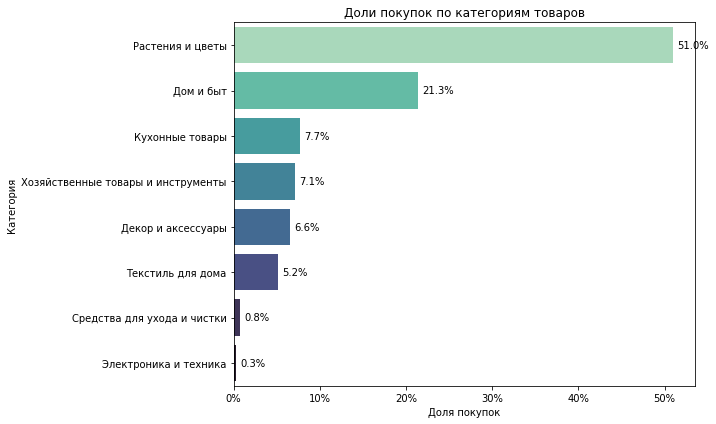

In [54]:
category_counts = data.groupby('category').size().sort_values(ascending=False)
display(category_counts)

# Считаем долю каждой категории:
category_share = category_counts / category_counts.sum()

colors = sns.color_palette("mako_r", len(category_share))

plt.figure(figsize=(10, 6))
sns.barplot(
    x=category_share.values,
    y=category_share.index,
    palette=colors
)

# Добавление подписей процентов на столбцах:
for i, (value, label) in enumerate(zip(category_share.values, category_share.index)):
    plt.text(value + 0.005, i, f"{value:.1%}", va='center')
    
plt.xlabel('Доля покупок')
plt.ylabel('Категория')
plt.title('Доли покупок по категориям товаров')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
# или plt.xlim(0, max(category_share.values) + 0.1)  
plt.tight_layout()
plt.show()

### 6. Изучим еще некоторые данные:

**1) Посмотрим на строку с максимальной суммой заказа:**

In [55]:
# Посмотрим на строку с максимальной суммой заказа:
max_price = data['price'].max() 

max_price_rows = data[data['price'] == max_price]

display(max_price_rows)

,date,customer_id,order_id,product,quantity,price,month,season,total_price,category
5992,2019-07-29 17:00:00,0d87f4ae-465a-4fac-81e6-5d629761783e,72139,сушилка уличная lеifhеiт 85210 linоmатiс v 400...,1,"14,917.00",7,лето,"14,917.00",Дом и быт


In [56]:
#Посмотрим название товара полностью:

if 5992 in data.index:
    full_product_value = data.at[5992, 'product']
    print(full_product_value)
else:
    print("Строка с индексом 5992 не найдена.")

сушилка уличная lеifhеiт 85210 linоmатiс v 400 40 м 175х237х237 см зеленая


**Посмотрим, есть ли еще дорогие сушилки в этой категории товаров:**

In [57]:
all_dryers = data[
    (data['category'] == 'Дом и быт') & (data['product'].str.contains('сушилка', case=False))
].sort_values(by='price', ascending=False)

display(all_dryers)

,date,customer_id,order_id,product,quantity,price,month,season,total_price,category
5992,2019-07-29 17:00:00,0d87f4ae-465a-4fac-81e6-5d629761783e,72139,сушилка уличная lеifhеiт 85210 linоmатiс v 400...,1,"14,917.00",7,лето,"14,917.00",Дом и быт
5087,2019-06-11 10:00:00,85716494-dd51-4d1d-ab28-8c74b87f14dc,71674,сушилка для белья lеifhеiт реgаsus 200 dеluхе ...,1,"7,004.00",6,лето,"7,004.00",Дом и быт
2068,2019-02-28 13:00:00,c971fb21-d54c-4134-938f-16b62ee86d3b,70507,сушилка mеliсоni sтеndу juniоr,1,"5,594.00",2,зима,"5,594.00",Дом и быт
2404,2019-03-19 21:00:00,493d53bf-ff1f-4487-a6e7-b1bedddb73fd,70799,сушилка mеliсоni sтеndу juniоr,1,"5,594.00",3,весна,"5,594.00",Дом и быт
7422,2020-01-23 13:00:00,b7dffbd3-810c-4125-889a-454ee093eb73,104525,сушилка mеliсоni sтеndу juniоr,1,"5,594.00",1,зима,"5,594.00",Дом и быт
...,...,...,...,...,...,...,...,...,...,...
5996,2019-07-30 04:00:00,44931b1a-3587-4d7a-b680-6b25092fcdb6,72142,сушилка для белья настенная zаlgеr рrimа 510-7...,1,150.00,7,лето,150.00,Дом и быт
6322,2019-09-13 11:00:00,32bf8289-10cf-44e2-b1ce-caa196bd0ef0,72617,сушилка для белья настенная zаlgеr рrimа 510-7...,1,150.00,9,осень,150.00,Дом и быт
108,2018-10-05 12:00:00,b463177a-cc14-44f6-a225-0e03170f5d41,68536,"сушилка для белья на батарею, сб5-45, ника",1,134.00,10,осень,134.00,Дом и быт
1526,2019-01-16 15:00:00,fb2f95f0-1f30-4e6a-a75c-92d1e2d341e3,69850,"сушилка для белья на батарею, сб5-45, ника",1,134.00,1,зима,134.00,Дом и быт


*Похоже, что товар "Сушилка уличная Leifheit 85210 LINOMATIC V 400" не выброс, а вполне себе реальный товар с максимальной стоимостью из всех представленных в датасете товаров.*

**2) Узнаем рассматриваемый период для анализа:**

In [58]:
min_date = data['date'].min()
max_date = data['date'].max()

print(f"Рассматриваемый период совершения заказов: с {min_date.date()} по {max_date.date()}")

Рассматриваемый период совершения заказов: с 2018-10-01 по 2020-01-31


In [59]:
from dateutil.relativedelta import relativedelta

diff = relativedelta(max_date, min_date)
years = diff.years
months = diff.months

print(f"Продолжительность периода: {years} лет и {months} мес.")

Продолжительность периода: 1 лет и 3 мес.


*Рассматриваемый период совершения заказов1 октября 2018 года по 31 января 2020 года (данные за 1 год и 3 месяца).*

Переставим порядок столбцов в датасете:

In [60]:
new_order = [
    'date', 'month', 'customer_id', 'order_id', 
    'product', 'category', 'quantity', 'price', 
    'total_price', 'season'
]

data = data[new_order]
display(data.head())

,date,month,customer_id,order_id,product,category,quantity,price,total_price,season
0,2018-10-01,10,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"комнатное растение в горшке алое вера, d12, h30",Растения и цветы,1,142.00,142.00,осень
1,2018-10-01,10,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"комнатное растение в горшке кофе арабика, d12,...",Растения и цветы,1,194.00,194.00,осень
2,2018-10-01,10,ee47d746-6d2f-4d3c-9622-c31412542920,68477,радермахера d-12 см h-20 см,Растения и цветы,1,112.00,112.00,осень
3,2018-10-01,10,ee47d746-6d2f-4d3c-9622-c31412542920,68477,хризолидокарпус лутесценс d-9 см,Растения и цветы,1,179.00,179.00,осень
4,2018-10-01,10,ee47d746-6d2f-4d3c-9622-c31412542920,68477,циперус зумула d-12 см h-25 см,Растения и цветы,1,112.00,112.00,осень


<div style="border:solid  green 6px; padding: 30px">
    
<b> ВЫВОД:</b>
    
В результате предобработки данных, мы:

- преобразовали тип данных столбца data;
    
- привели столбец product к нижнему регистру;
- выявили не явные дубликаты в датасете и удалили некоторые из них, в результате чего из первоначальных 7474 строк датасета у нас стало 5525 строк;
    
- были добавлены новые столбцы: month, total_price и season;
    
- также была проведена категоризация товаров из столбца product и создан новый столбец category;
    
- определен товар с максимальной суммой заказа по датасету (по столбцу price): товар сушилка уличная lеifhеiт 85210 linоmатiс v 400 40 м 175х237х237 см зеленая на сумму 14,917.00 руб. Вполне себе реальный товар по реальной стоимости;
    
- определили рассматриваемый период в данных: анализ будем проводить по данным пользователей, сделавших заказы с 1 октября 2018 года по 31 января 2020 года (данные за 1 год и 3 месяца).


## Шаг 3. Исследовательский анализ данных (EDA)

### 1. Общая статистика:

#### Общее количество покупателей, заказов и товаров:

In [61]:
num_customers = data['customer_id'].nunique()
num_orders = data['order_id'].nunique()
num_products = data['product'].nunique()

print(f"Уникальных покупателей: {num_customers} (чел.)")
print(f"Уникальных заказов: {num_orders} (чел.)")
print(f"Уникальных товаров: {num_products} (чел.)")

Уникальных покупателей: 2413 (чел.)
Уникальных заказов: 3475 (чел.)
Уникальных товаров: 2332 (чел.)


#### 1. Распределение значений в столбцах quantity, price и total_price:

**Изучим выбросы по столбцам с количественными данными и аномальные значения:**

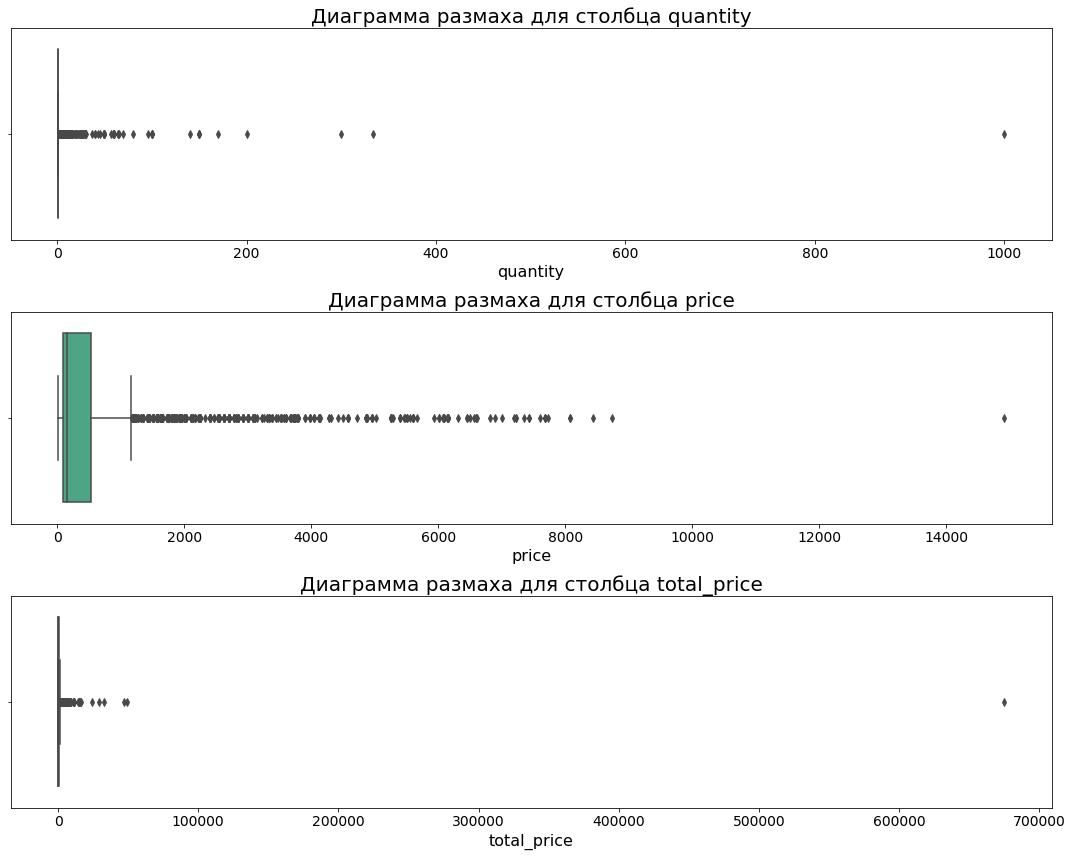

In [62]:
# Выбор только числовых столбцов:

exclude_cols = ['order_id', 'month']
numeric_cols = [col for col in data.select_dtypes(include='number').columns if col not in exclude_cols]
#numeric_cols = data.select_dtypes(include='number').columns

# Построение boxplot'ов:
plt.figure(figsize=(15, len(numeric_cols) * 4))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=data[col], color='#3EB489')
    plt.title(f'Диаграмма размаха для столбца {col}', fontsize=20)
    plt.xlabel(col, fontsize=16)
    plt.ylabel('', fontsize=16)
    plt.tick_params(axis='x', labelsize=14)
    plt.tight_layout()

Выбросов слишком много. Изучим их детальнее.

**Проанализируем выбросы столбца QUANTITY:**

In [63]:
unique_quantity = data['quantity'].unique()
sorted_unique_quantity = sorted(unique_quantity)  # сортируем уникальные значения
print(sorted_unique_quantity)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 20, 22, 23, 24, 25, 26, 27, 29, 30, 31, 37, 40, 43, 45, 50, 57, 59, 60, 64, 65, 70, 80, 96, 100, 140, 150, 170, 200, 300, 334, 1000]


In [64]:
print(data['quantity'].value_counts())

print("***" * 15)

print(data['quantity'].nunique())

1       4417
2        507
3        137
4        101
10        69
5         67
6         41
15        22
7         20
20        16
25        16
30        15
12        13
8         13
50         8
9          7
13         5
11         5
100        4
16         4
24         3
150        3
27         2
64         2
60         2
40         2
14         2
31         1
334        1
23         1
170        1
70         1
43         1
45         1
26         1
22         1
18         1
65         1
57         1
37         1
29         1
17         1
1000       1
300        1
200        1
140        1
96         1
80         1
59         1
Name: quantity, dtype: int64
*********************************************
49


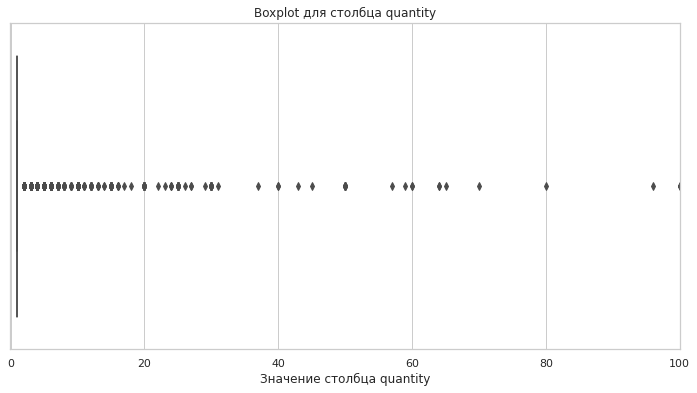

In [65]:
sns.set(style="whitegrid")

# Создание ящика с усами:
plt.figure(figsize=(12, 6))
sns.boxplot(x=data['quantity'])
plt.title('Boxplot для столбца quantity')
plt.xlabel('Значение столбца quantity')

plt.xlim(-0.1, 100)

plt.show()

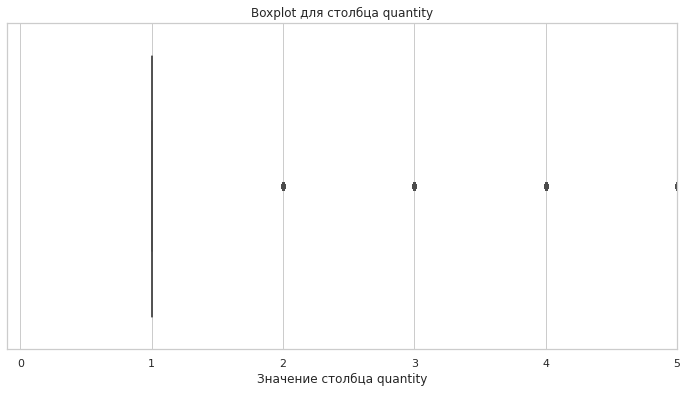

In [66]:
# Уменьшим масштаб:

plt.figure(figsize=(12, 6))
sns.boxplot(x=data['quantity'])
plt.title('Boxplot для столбца quantity')
plt.xlabel('Значение столбца quantity')

plt.xlim(-0.1, 5)

plt.show()

In [67]:
data['quantity'].describe()

count   5,525.00
mean        2.58
std        16.50
min         1.00
25%         1.00
50%         1.00
75%         1.00
max     1,000.00
Name: quantity, dtype: float64

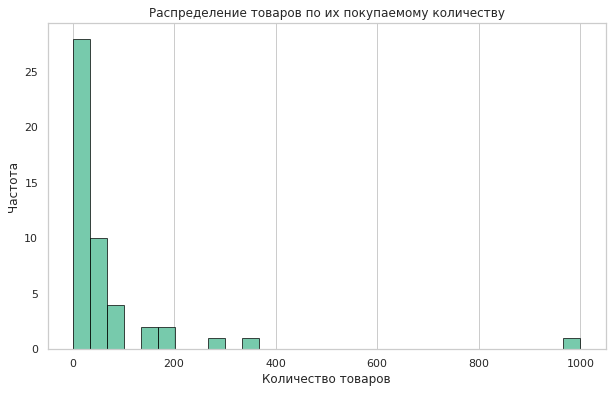

In [68]:
plt.figure(figsize=(10, 6))
plt.hist(unique_quantity, bins=30, color='#3EB489', edgecolor='black', alpha=0.7) 
plt.title('Распределение товаров по их покупаемому количеству')
plt.xlabel('Количество товаров')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.75)
plt.show()

*Распределение максимально не нормально.*

Данные ассимитричные, правостороннее распределение (длинный 'хвост' вправо).


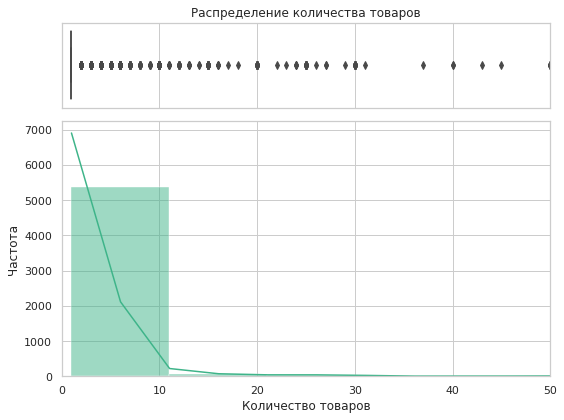

In [69]:
# Построим два параллельных графика:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(8, 6), sharex=True, gridspec_kw={'height_ratios': [1, 3]})

# Строим boxplot:
sns.boxplot(x=data['quantity'], color='#3EB489', ax=ax1)
ax1.set_title('Распределение количества товаров')
ax1.set(ylabel='')  # Убираем подпись по y оси
ax1.set_xlabel('')  # Убираем дублирующий label

# Построим гистограмму:
sns.histplot(x=data['quantity'], color='#3EB489', ax=ax2, kde=True, bins=100)  # kde=True добавит кривую плотности
ax2.set_xlabel('Количество товаров')
ax2.set_ylabel('Частота')
ax2.set_xlim(0, 50)  # Устанавливаем пределы по оси X

plt.tight_layout()  # Убираем лишние отступы
plt.show()  # Отображаем графики



# Для определения корректного количества корзин bins, используем правило Стерджесса:
# n = len(data)  # Общее количество наблюдений
# Определяем количество bins по правилу Стерджесса
# bins = int(1 + 3.322 * np.log(n))

<div style="border:solid green 2px; padding: 30px">
    
<b> ИТОГО:</b>
    
По данным столбца quantity можно сказать, что:
    
- Минимальное количество товара в заказе: 1
    
- Максимальное количество: 1000
    
- Медиана: 1
    
- по графику распределения видно, что все значения больше 1 являются аномальными. Распределение максимально не нормально. Данные ассимитричные, правостороннее распределение (длинный 'хвост' вправо).

**Рассмотрим построчно, что это за заказы такие аномальные:**

1) Если воспользоваться таким правилом выявления аномалий в данных/ выбросов, как выявление аномалий через определение межквартильного размаха, тогда поиск аномальных данных будет выглядеть так:

In [70]:
# Вычисляем Q1 (25-й процентиль) и Q3 (75-й процентиль)
Q1 = data['quantity'].quantile(0.25)
Q3 = data['quantity'].quantile(0.75)
IQR = Q3 - Q1

# Определяем границы для выбросов
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Фильтруем аномалии
anomalies_quantity = data[(data['quantity'] < lower_bound) | (data['quantity'] > upper_bound)]

# Выводим аномалии:
display(Markdown('<span style="color: green;"><strong>Аномальные покупки по количеству товаров:</strong></span>'))
sorted_anomalies_quantity = anomalies_quantity.sort_values(
    by='quantity', ascending=False
)
display(sorted_anomalies_quantity.head(30))
print('***' * 15)

print(len(sorted_anomalies_quantity))

<span style="color: green;"><strong>Аномальные покупки по количеству товаров:</strong></span>

,date,month,customer_id,order_id,product,category,quantity,price,total_price,season
5456,2019-06-18 15:00:00,6,312e9a3e-5fca-43ff-a6a1-892d2b2d5ba6,71743,"вантуз с деревянной ручкой d14 см красный, bur...",Хозяйственные товары и инструменты,1000,675.00,"675,000.00",лето
5071,2019-06-11 07:00:00,6,146cd9bf-a95c-4afb-915b-5f6684b17444,71668,вешалки мягкие для деликатных вещей 3 шт шоколад,Дом и быт,334,148.00,"49,432.00",лето
3961,2019-05-20 21:00:00,5,5d189e88-d4d6-4eac-ab43-fa65a3c4d106,71478,муляж яблоко 9 см красное,Декор и аксессуары,300,51.00,"15,300.00",весна
1158,2018-12-10 14:00:00,12,a984c5b7-ff7e-4647-b84e-ef0b85a2762d,69289,"ручка-скоба рс-100 белая *трибатрон*, 1108035",Декор и аксессуары,200,29.00,"5,800.00",зима
568,2018-11-01 08:00:00,11,aa42dc38-780f-4b50-9a65-83b6fa64e766,68815,муляж яблоко 9 см красное,Декор и аксессуары,170,51.00,"8,670.00",осень
2431,2019-03-23 10:00:00,3,685d3d84-aebb-485b-8e59-344b3df8b3d3,70841,плечики пластмассовые размер 52 - 54 тула 1205158,Дом и быт,150,20.00,"3,000.00",весна
212,2018-10-11 14:00:00,10,cd09ea73-d9ce-48c3-b4c5-018113735e80,68611,пружина дверная 240 мм оцинкованная (д-19 мм) ...,Хозяйственные товары и инструменты,150,38.00,"5,700.00",осень
211,2018-10-11 14:00:00,10,cd09ea73-d9ce-48c3-b4c5-018113735e80,68611,"крепеж для пружины дверной, 1107055",Хозяйственные товары и инструменты,150,19.00,"2,850.00",осень
586,2018-11-02 11:00:00,11,0c5aaa88-e346-4f87-8f7a-ad8cbc04e965,68831,муляж яблоко 9 см красное,Декор и аксессуары,140,59.00,"8,260.00",осень
1555,2019-01-21 09:00:00,1,8eabcaca-e8c8-4eee-9079-4ff5f612273a,69893,щетка для мытья посуды колибри м5202 большая,Кухонные товары,100,34.00,"3,400.00",зима


*********************************************
1108


*Получается, что 1108 заказов по количеству товара в заказе попадают в зону "выбросов".*


2) Но мы все же посмотрим логически на данные с аномальным количеством товара, может, это вовсе и не выбросы:

In [71]:
filtered_data_by_big_quantity = data[data['quantity'].isin([1000, 334, 300, 200, 70, 80, 96, 100, 140, 150, 170,])]

# Сортируем по столбцу quantity по убыванию
sorted_filtered_data_by_big_quantity = filtered_data_by_big_quantity.sort_values(
    by='quantity', ascending=False
)

display(sorted_filtered_data_by_big_quantity)

,date,month,customer_id,order_id,product,category,quantity,price,total_price,season
5456,2019-06-18 15:00:00,6,312e9a3e-5fca-43ff-a6a1-892d2b2d5ba6,71743,"вантуз с деревянной ручкой d14 см красный, bur...",Хозяйственные товары и инструменты,1000,675.00,"675,000.00",лето
5071,2019-06-11 07:00:00,6,146cd9bf-a95c-4afb-915b-5f6684b17444,71668,вешалки мягкие для деликатных вещей 3 шт шоколад,Дом и быт,334,148.00,"49,432.00",лето
3961,2019-05-20 21:00:00,5,5d189e88-d4d6-4eac-ab43-fa65a3c4d106,71478,муляж яблоко 9 см красное,Декор и аксессуары,300,51.00,"15,300.00",весна
1158,2018-12-10 14:00:00,12,a984c5b7-ff7e-4647-b84e-ef0b85a2762d,69289,"ручка-скоба рс-100 белая *трибатрон*, 1108035",Декор и аксессуары,200,29.00,"5,800.00",зима
568,2018-11-01 08:00:00,11,aa42dc38-780f-4b50-9a65-83b6fa64e766,68815,муляж яблоко 9 см красное,Декор и аксессуары,170,51.00,"8,670.00",осень
211,2018-10-11 14:00:00,10,cd09ea73-d9ce-48c3-b4c5-018113735e80,68611,"крепеж для пружины дверной, 1107055",Хозяйственные товары и инструменты,150,19.00,"2,850.00",осень
212,2018-10-11 14:00:00,10,cd09ea73-d9ce-48c3-b4c5-018113735e80,68611,пружина дверная 240 мм оцинкованная (д-19 мм) ...,Хозяйственные товары и инструменты,150,38.00,"5,700.00",осень
2431,2019-03-23 10:00:00,3,685d3d84-aebb-485b-8e59-344b3df8b3d3,70841,плечики пластмассовые размер 52 - 54 тула 1205158,Дом и быт,150,20.00,"3,000.00",весна
586,2018-11-02 11:00:00,11,0c5aaa88-e346-4f87-8f7a-ad8cbc04e965,68831,муляж яблоко 9 см красное,Декор и аксессуары,140,59.00,"8,260.00",осень
1103,2018-12-04 17:00:00,12,7d255526-fcc2-4f79-b28a-217d7d2373a8,69206,"щетка для посуды *оля*, мультипласт 1807010",Кухонные товары,100,26.00,"2,600.00",зима


Мы видим, что:

- 1000 штук вантузов на сумму 675.000 (руб) - это скорее всего ошибка в данных. Такой заказ выглядит слишком  большим для обычной покупки. Даже если такой заказ и правда был, то лучше его удалить, чтобы не искажал аналитику в дальнейшем.

- 334 штук вешалок - также очень большое количество для обычного домашнего использования. Пожалуй, удалим этот заказ. 

- 300 штук муляжей яблок - тоже возможно, что это ошибка, но скорее всего уже просто крупный заказ для какой-то компании или магазина. Однако сумма заказа общего очень высокая, поэтому все же удалим этот заказ.

- Большое количество таких товаров, как дверные пружины, ручек-скоб, плечиков пластмассовых, шпингалетов — это может быть оптовая покупка или ошибка в данных. 

**Оставим эти заказы в количестве от 200 шт.**

3) Рассмотрим подробнее заказы, количество товаров в quantity меньше 250, но количество заказов данного уникального товара (название товара в столбце product) было больше 2:

In [72]:
product_counts = data.groupby('product').size().reset_index(name='order_count')

# Фильтруем продукты, у которых количество заказов больше 2:
filtered_products = product_counts[product_counts['order_count'] > 2]['product']

# Теперь фильтруем основной DataFrame по условиям:
result_1 = data[(data['quantity'] < 250) & (data['product'].isin(filtered_products))]

sorted_result_1 = result_1.sort_values(by='quantity', ascending=False)

display(sorted_result_1.head(15))

print('***' * 15)

print(len(sorted_result_1))

,date,month,customer_id,order_id,product,category,quantity,price,total_price,season
568,2018-11-01 08:00:00,11,aa42dc38-780f-4b50-9a65-83b6fa64e766,68815,муляж яблоко 9 см красное,Декор и аксессуары,170,51.00,"8,670.00",осень
586,2018-11-02 11:00:00,11,0c5aaa88-e346-4f87-8f7a-ad8cbc04e965,68831,муляж яблоко 9 см красное,Декор и аксессуары,140,59.00,"8,260.00",осень
160,2018-10-09 09:00:00,10,c971fb21-d54c-4134-938f-16b62ee86d3b,68580,"стяжка оконная с болтом ст-55 цинк, 1108354",Дом и быт,64,19.00,"1,216.00",осень
2969,2019-04-19 18:00:00,4,498f12a4-6a62-4725-8516-cf5dc9ab8a3a,71204,салфетка рrотес техтil роlуlinе 30х43 см амети...,Дом и быт,60,191.00,"11,460.00",весна
1299,2018-12-21 16:00:00,12,6987e6d6-a63a-4ce2-a2d0-f424092d235e,69504,тележка багажная dеlта тбр-22 синий грузоподъе...,Дом и быт,57,574.00,"32,718.00",зима
2049,2019-02-27 09:00:00,2,377c8a20-a3e0-4945-9fd8-a1f4ada5d8b0,70482,муляж банан желтый 21 см полиуретан,Декор и аксессуары,50,51.00,"2,550.00",зима
6678,2019-10-22 16:00:00,10,511115b7-e981-4069-9e0e-88a3551341a6,73063,муляж яблоко зеленый 9 см полиуретан,Декор и аксессуары,50,51.00,"2,550.00",осень
1897,2019-02-18 16:00:00,2,74b08ab4-16e9-4d83-9c31-acfc9d229bc5,70328,муляж лимон желтый 9 см полиуретан,Декор и аксессуары,50,51.00,"2,550.00",зима
2371,2019-03-18 10:00:00,3,21b4642e-9cdf-4738-a290-b42d3e748c0f,70776,гвоздика стандартная белая 60 см колумбия план...,Растения и цветы,43,29.00,"1,247.00",весна
1316,2018-12-23 11:00:00,12,24c0b355-53e3-428a-b299-e1627b1cdd5c,69524,муляж яблоко зеленый 9 см полиуретан,Декор и аксессуары,40,59.00,"2,360.00",зима


*********************************************
3278


Получается, муляж яблоко, стяжка оконная и другие товары, купленные больше двух раз , согласно данным датасета, разными пользователями Интернет-магазина, вполне себе кажутся реальными покупками, а не аномальными. 

*Соответственно, на данный момент пока считаем заказы в количестве (quantity) до 250  штук не аномальными. Остальные рассматриваем на удаление из датасета.*

4) Теперь посмотрим на те заказы (по убыванию количества товара в заказе выведем их) датасета, которые по своему уникальному значению quantity встречаются всего 1 раза:

In [73]:
quantity_counts = data['quantity'].value_counts()

# Фильтруем те значения, которые встречаются более 1 раза
frequent_quantities = quantity_counts[quantity_counts == 1].index

# Теперь фильтруем основной DataFrame по условиям
result_2 = data[data['quantity'].isin(frequent_quantities)]

# Сортируем результат по quantity в порядке убывания
sorted_result_2 = result_2.sort_values(by='quantity', ascending=False)


display(sorted_result_2)

print('***' * 15)

print(len(sorted_result_2))

,date,month,customer_id,order_id,product,category,quantity,price,total_price,season
5456,2019-06-18 15:00:00,6,312e9a3e-5fca-43ff-a6a1-892d2b2d5ba6,71743,"вантуз с деревянной ручкой d14 см красный, bur...",Хозяйственные товары и инструменты,1000,675.00,"675,000.00",лето
5071,2019-06-11 07:00:00,6,146cd9bf-a95c-4afb-915b-5f6684b17444,71668,вешалки мягкие для деликатных вещей 3 шт шоколад,Дом и быт,334,148.00,"49,432.00",лето
3961,2019-05-20 21:00:00,5,5d189e88-d4d6-4eac-ab43-fa65a3c4d106,71478,муляж яблоко 9 см красное,Декор и аксессуары,300,51.00,"15,300.00",весна
1158,2018-12-10 14:00:00,12,a984c5b7-ff7e-4647-b84e-ef0b85a2762d,69289,"ручка-скоба рс-100 белая *трибатрон*, 1108035",Декор и аксессуары,200,29.00,"5,800.00",зима
568,2018-11-01 08:00:00,11,aa42dc38-780f-4b50-9a65-83b6fa64e766,68815,муляж яблоко 9 см красное,Декор и аксессуары,170,51.00,"8,670.00",осень
586,2018-11-02 11:00:00,11,0c5aaa88-e346-4f87-8f7a-ad8cbc04e965,68831,муляж яблоко 9 см красное,Декор и аксессуары,140,59.00,"8,260.00",осень
13,2018-10-01 15:00:00,10,0948b0c2-990b-4a11-b835-69ac4714b21d,68486,крючок одежный 2-х рожковый серый металлик с п...,Дом и быт,96,38.00,"3,648.00",осень
6367,2019-09-19 16:00:00,9,de95510f-3558-4c42-97dc-98cc4215c278,72698,универсальный нож wеbbеr из нержавеющей стали ...,Кухонные товары,80,45.00,"3,600.00",осень
4082,2019-05-28 13:00:00,5,f9d19e1d-9414-485b-9d8d-02bc196a88e8,71539,насадка на валик вмм-200/60 белый искусственны...,Декор и аксессуары,70,22.00,"1,540.00",весна
6567,2019-10-10 14:00:00,10,bd5328dc-1e15-4757-9fe2-f56e4f8eaa7c,72920,искусственный цветок подснежник садовый пласти...,Декор и аксессуары,65,32.00,"2,080.00",осень


*********************************************
22


*Товары, купленные в количестве больше 250 штук, кажутся аномальными.*

5) Рассмотрим заказы, количество товаров в quantity больше 250, но количество заказов данного уникального товара (название товара в столбце product) было равно 1:

In [74]:
product_counts = data.groupby('product').size().reset_index(name='order_count')

filtered_products_3 = product_counts[product_counts['order_count'] ==1 ]['product']

# Теперь фильтруем основной DataFrame по условиям:
result_3 = data[(data['quantity'] > 100) & (data['product'].isin(filtered_products_3))]

sorted_result_3 = result_3.sort_values(by='quantity', ascending=False)

display(sorted_result_3.head(15))

print('***' * 15)

print(len(sorted_result_3))

,date,month,customer_id,order_id,product,category,quantity,price,total_price,season
5456,2019-06-18 15:00:00,6,312e9a3e-5fca-43ff-a6a1-892d2b2d5ba6,71743,"вантуз с деревянной ручкой d14 см красный, bur...",Хозяйственные товары и инструменты,1000,675.00,"675,000.00",лето
212,2018-10-11 14:00:00,10,cd09ea73-d9ce-48c3-b4c5-018113735e80,68611,пружина дверная 240 мм оцинкованная (д-19 мм) ...,Хозяйственные товары и инструменты,150,38.00,"5,700.00",осень


*********************************************
2


Посмотрим на долю "аномальных" данных в датасете, которые больше 95-го процентиля:

In [75]:
q95 = data['quantity'].quantile(0.95)
above_95 = data[data['quantity'] > q95]

# Посчитаем долю (количество выше 95-го процентиля / общее количество)
share_above_95 = len(above_95) / len(data)

percentage_above_95 = share_above_95 * 100
print(f"Доля значений выше 95-го процентиля: {percentage_above_95:.2f}%")

Доля значений выше 95-го процентиля: 4.62%


Удалим строки, количество товаров в заказе которых больше 230 штук:

In [76]:
data = data[data['quantity'] <= 230]
print(len(data))

5522


In [77]:
anomalies_q = data[data['quantity'].isin([1000, 334, 300, 250])]
display(anomalies_q)

,date,month,customer_id,order_id,product,category,quantity,price,total_price,season


Нет больше таких значений.

Проверим:

In [78]:
unique_quantity = data['quantity'].unique()

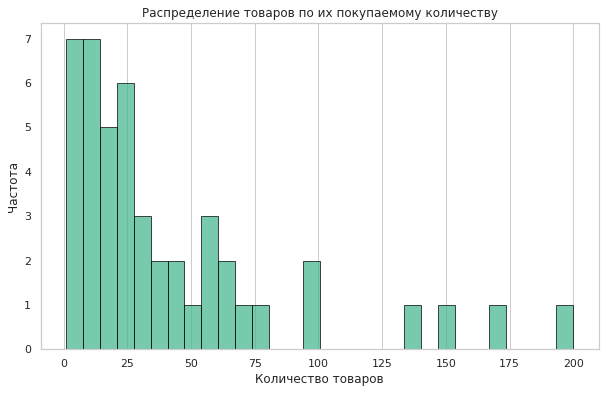

In [79]:
plt.figure(figsize=(10, 6))
plt.hist(unique_quantity, bins=30, color='#3EB489', edgecolor='black', alpha=0.7) 
plt.title('Распределение товаров по их покупаемому количеству')
plt.xlabel('Количество товаров')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.75)
plt.show()

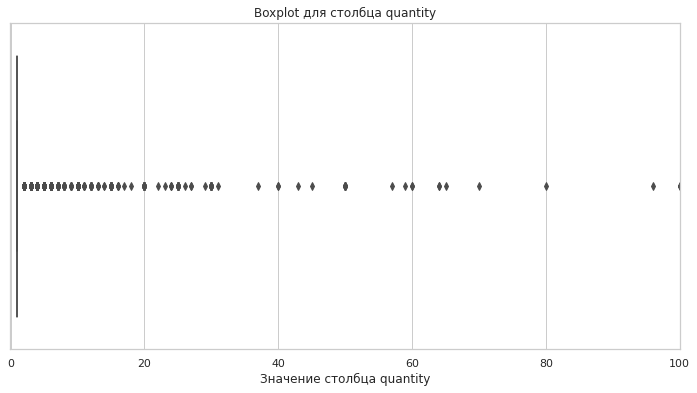

In [80]:
# Посмотрим на ящике с усами:
plt.figure(figsize=(12, 6))
sns.boxplot(x=data['quantity'])
plt.title('Boxplot для столбца quantity')
plt.xlabel('Значение столбца quantity')

plt.xlim(-0.1, 100)

plt.show()

In [81]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5522 entries, 0 to 7473
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         5522 non-null   datetime64[ns]
 1   month        5522 non-null   int64         
 2   customer_id  5522 non-null   object        
 3   order_id     5522 non-null   int64         
 4   product      5522 non-null   object        
 5   category     5522 non-null   object        
 6   quantity     5522 non-null   int64         
 7   price        5522 non-null   float64       
 8   total_price  5522 non-null   float64       
 9   season       5522 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(4)
memory usage: 474.5+ KB


<div style="border:solid green 2px; padding: 30px">
    
<b> ИТОГО:</b>
    
Мы посчитали аномальными покупки, сделанные в количестве больше 230 штук и удалили их из датасета.
    
Теперь в датасете 5522 строк.

**Проанализируем выбросы столбца TOTAL_PRICE:**

In [82]:
data['total_price'].describe()

count    5,522.00
mean       695.81
std      1,510.16
min          9.00
25%        120.00
50%        190.50
75%        727.00
max     47,385.00
Name: total_price, dtype: float64

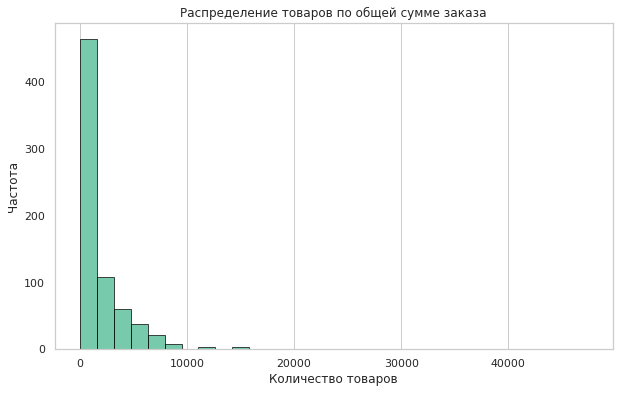

In [83]:
unique_total_price = data['total_price'].unique()

plt.figure(figsize=(10, 6))
plt.hist(unique_total_price, bins=30, color='#3EB489', edgecolor='black', alpha=0.7) 
plt.title('Распределение товаров по общей сумме заказа')
plt.xlabel('Количество товаров')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.75)
plt.show()

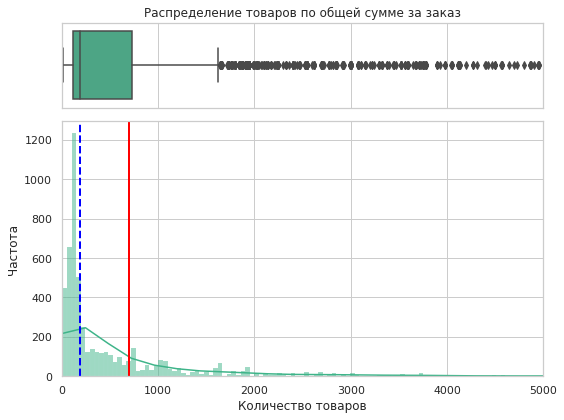

In [84]:
# Построим два параллельных графика:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(8, 6), sharex=True, gridspec_kw={'height_ratios': [1, 3]})

# Строим boxplot:
sns.boxplot(x=data['total_price'], color='#3EB489', ax=ax1)
ax1.set_title('Распределение товаров по общей сумме за заказ')
ax1.set(ylabel='') 
ax1.set_xlabel('')  

# Построим гистограмму:
sns.histplot(x=data['total_price'], color='#3EB489', ax=ax2, kde=True, bins=1000)  # kde=True добавит кривую плотности
ax2.set_xlabel('Количество товаров')
ax2.set_ylabel('Частота')
ax2.set_xlim(0, 5000) 

# Добавляем линию медианы:
plt.axvline(data['total_price'].median(), color='blue', linestyle='--', linewidth=2, label=f'Медиана: {data["quantity"].median():.0f}')
# Добавляем линию среднего:
plt.axvline(data['total_price'].mean(), color='red', linestyle='-', linewidth=2, label=f'Среднее: {data["quantity"].mean():.0f}')

plt.tight_layout()  
plt.show()  

По графикам видно, что от примерно 1600 руб. начинаются аномальные значения в общей стоимости заказов.

Боксплот показывает, что медиана смещена влево - это означат, что график у нас смещен вправо - распределение ассиметричное, не нормальное.

In [85]:
Q1_price = data['total_price'].quantile(0.25)
Q3_price = data['total_price'].quantile(0.75)
IQR_price = Q3_price - Q1_price

lower_bound_price = Q1_price - 1.5 * IQR_price
upper_bound_price = Q3_price + 1.5 * IQR_price

anomalies_price = data[(data['total_price'] < lower_bound_price) | (data['total_price'] > upper_bound_price)]


# Выводим аномалии:
display(Markdown('<span style="color: green;"><strong>Аномальные покупки по сумме:</strong></span>'))
sorted_anomalies_price = anomalies_price.sort_values(
    by='total_price', ascending=False
)
display(sorted_anomalies_price.head(30))
print('***' * 15)

print(len(sorted_anomalies_price))

<span style="color: green;"><strong>Аномальные покупки по сумме:</strong></span>

,date,month,customer_id,order_id,product,category,quantity,price,total_price,season
1518,2019-01-15 13:00:00,1,58a4c3cc-504f-43ea-a74a-bae19e665552,69830,простынь вафельная 200х180 см wеllnеss rw180-0...,Текстиль для дома,27,"1,755.00","47,385.00",зима
1299,2018-12-21 16:00:00,12,6987e6d6-a63a-4ce2-a2d0-f424092d235e,69504,тележка багажная dеlта тбр-22 синий грузоподъе...,Дом и быт,57,574.00,"32,718.00",зима
1023,2018-11-29 17:00:00,11,8fba3604-ef57-4b9f-b2fe-3402fa8825c8,69156,набор ножей аттribuте сhеf 5 предметов аkf522,Кухонные товары,64,457.00,"29,248.00",осень
661,2018-11-06 12:00:00,11,1b2764ad-9151-4051-a46a-9b01b62e6335,68878,"урна уличная ""гео"", hоbbуkа/хоббика, 59*37,5см...",Дом и быт,5,"4,874.00","24,370.00",осень
1675,2019-02-04 06:00:00,2,909564b8-3a5c-4d3e-8310-5ba1c837bbd7,70080,мусорный контейнер hаilо bigbin swing 45 0845-...,Кухонные товары,3,"5,512.00","16,536.00",зима
2971,2019-04-19 19:00:00,4,498f12a4-6a62-4725-8516-cf5dc9ab8a3a,71206,одеяло wеllnеss т142 белое темостеганое 140х20...,Дом и быт,10,"1,568.00","15,680.00",весна
7190,2019-12-31 10:00:00,12,f279d50f-a508-40b4-bde5-5cb4a1be3ad0,107812,сумка-тележка хозяйственная rоlsеr imх006 bаss...,Дом и быт,2,"7,679.00","15,358.00",зима
5992,2019-07-29 17:00:00,7,0d87f4ae-465a-4fac-81e6-5d629761783e,72139,сушилка уличная lеifhеiт 85210 linоmатiс v 400...,Дом и быт,1,"14,917.00","14,917.00",лето
2970,2019-04-19 18:00:00,4,498f12a4-6a62-4725-8516-cf5dc9ab8a3a,71205,наматрацник nатurеs бархатный бамбук бб-н-1-2 ...,Текстиль для дома,12,"1,183.00","14,196.00",весна
2969,2019-04-19 18:00:00,4,498f12a4-6a62-4725-8516-cf5dc9ab8a3a,71204,салфетка рrотес техтil роlуlinе 30х43 см амети...,Дом и быт,60,191.00,"11,460.00",весна


*********************************************
633


*Получается, что 633 заказ по общей сумме одного заказа попадает в список аномальных покупок.*

In [86]:
unique_total_price = data['total_price'].unique()
sorted_unique_total_price = sorted(unique_total_price) 
#print(sorted_unique_total_price)

In [87]:
pd.set_option('display.max_rows', None)
print(data['total_price'].value_counts())

print("***" * 15)

print(data['total_price'].nunique())

120.00       212
135.00       192
188.00       174
150.00       170
38.00        167
90.00        138
149.00       113
134.00       101
112.00       100
74.00         77
82.00         75
1,087.00      69
59.00         62
128.00        61
1,649.00      61
76.00         60
89.00         56
142.00        55
22.00         55
1,049.00      49
164.00        49
187.00        48
224.00        47
974.00        41
749.00        41
449.00        39
210.00        39
374.00        39
97.00         38
1,574.00      37
734.00        37
119.00        37
44.00         36
194.00        36
195.00        35
60.00         35
899.00        34
599.00        33
157.00        33
127.00        33
524.00        30
239.00        29
1,949.00      29
104.00        27
169.00        27
300.00        26
116.00        26
299.00        25
52.00         25
487.00        25
240.00        24
674.00        23
1,874.00      23
637.00        22
30.00         22
105.00        22
1,124.00      22
1,199.00      22
412.00        

In [88]:
# Сортировка value_counts() по убыванию самого значения (не частоты):

value_counts_sorted_by_index = data['total_price'].value_counts().sort_index(ascending=False)
print(value_counts_sorted_by_index)

47,385.00      1
32,718.00      1
29,248.00      1
24,370.00      1
16,536.00      1
15,680.00      1
15,358.00      1
14,917.00      1
14,196.00      1
11,460.00      1
11,400.00      1
11,250.00      1
11,000.00      1
9,010.00       1
8,832.00       1
8,810.00       1
8,737.00       1
8,670.00       1
8,437.00       1
8,260.00       1
8,077.00       2
7,870.00       1
7,724.00       1
7,722.00       1
7,679.00       2
7,597.00       1
7,496.00       1
7,480.00       1
7,474.00       1
7,424.00       2
7,349.00       1
7,229.00       2
7,199.00       1
7,004.00       1
6,899.00       1
6,809.00       1
6,658.00       1
6,614.00       1
6,600.00       2
6,558.00       1
6,494.00       1
6,449.00       2
6,307.00       1
6,270.00       1
6,149.00       4
6,148.00       1
6,134.00       1
6,097.00       2
6,075.00       2
6,007.00       2
5,970.00       1
5,939.00       1
5,848.00       1
5,847.00       1
5,800.00       1
5,775.00       1
5,700.00       1
5,662.00       1
5,594.00      

Посмотрим все заказы, общая сумма заказа у которых больше 9000 руб:

In [89]:
filtered_price_9 = data[data['total_price'] >= 9000]

# Сортировка по убыванию total_price
filtered_sorted = filtered_price_9.sort_values('total_price', ascending=False)

# pd.set_option('display.max_rows', None) 
display(filtered_sorted)

print('***' * 15)
print(f"Количество строк: {len(filtered_sorted)}")

,date,month,customer_id,order_id,product,category,quantity,price,total_price,season
1518,2019-01-15 13:00:00,1,58a4c3cc-504f-43ea-a74a-bae19e665552,69830,простынь вафельная 200х180 см wеllnеss rw180-0...,Текстиль для дома,27,"1,755.00","47,385.00",зима
1299,2018-12-21 16:00:00,12,6987e6d6-a63a-4ce2-a2d0-f424092d235e,69504,тележка багажная dеlта тбр-22 синий грузоподъе...,Дом и быт,57,574.00,"32,718.00",зима
1023,2018-11-29 17:00:00,11,8fba3604-ef57-4b9f-b2fe-3402fa8825c8,69156,набор ножей аттribuте сhеf 5 предметов аkf522,Кухонные товары,64,457.00,"29,248.00",осень
661,2018-11-06 12:00:00,11,1b2764ad-9151-4051-a46a-9b01b62e6335,68878,"урна уличная ""гео"", hоbbуkа/хоббика, 59*37,5см...",Дом и быт,5,"4,874.00","24,370.00",осень
1675,2019-02-04 06:00:00,2,909564b8-3a5c-4d3e-8310-5ba1c837bbd7,70080,мусорный контейнер hаilо bigbin swing 45 0845-...,Кухонные товары,3,"5,512.00","16,536.00",зима
2971,2019-04-19 19:00:00,4,498f12a4-6a62-4725-8516-cf5dc9ab8a3a,71206,одеяло wеllnеss т142 белое темостеганое 140х20...,Дом и быт,10,"1,568.00","15,680.00",весна
7190,2019-12-31 10:00:00,12,f279d50f-a508-40b4-bde5-5cb4a1be3ad0,107812,сумка-тележка хозяйственная rоlsеr imх006 bаss...,Дом и быт,2,"7,679.00","15,358.00",зима
5992,2019-07-29 17:00:00,7,0d87f4ae-465a-4fac-81e6-5d629761783e,72139,сушилка уличная lеifhеiт 85210 linоmатiс v 400...,Дом и быт,1,"14,917.00","14,917.00",лето
2970,2019-04-19 18:00:00,4,498f12a4-6a62-4725-8516-cf5dc9ab8a3a,71205,наматрацник nатurеs бархатный бамбук бб-н-1-2 ...,Текстиль для дома,12,"1,183.00","14,196.00",весна
2969,2019-04-19 18:00:00,4,498f12a4-6a62-4725-8516-cf5dc9ab8a3a,71204,салфетка рrотес техтil роlуlinе 30х43 см амети...,Дом и быт,60,191.00,"11,460.00",весна


*********************************************
Количество строк: 14


Слишком много простыней покупает клиент, и дорого.

Посмотрим, сколько простыней вообще куплено:

In [90]:
result = data[data['product'].str.contains('простынь', na=False)]
display(result)

,date,month,customer_id,order_id,product,category,quantity,price,total_price,season
1469,2019-01-10 13:00:00,1,58a4c3cc-504f-43ea-a74a-bae19e665552,69766,простынь вафельная 200х180 см wеllnеss rw180-0...,Текстиль для дома,3,"1,949.00","5,847.00",зима
1518,2019-01-15 13:00:00,1,58a4c3cc-504f-43ea-a74a-bae19e665552,69830,простынь вафельная 200х180 см wеllnеss rw180-0...,Текстиль для дома,27,"1,755.00","47,385.00",зима


Один и тот же покупатель. Посмотрим, что еще он покупал:

In [91]:
result_customer = data[data['customer_id'] == '58a4c3cc-504f-43ea-a74a-bae19e665552']

display(result_customer)

,date,month,customer_id,order_id,product,category,quantity,price,total_price,season
1469,2019-01-10 13:00:00,1,58a4c3cc-504f-43ea-a74a-bae19e665552,69766,простынь вафельная 200х180 см wеllnеss rw180-0...,Текстиль для дома,3,"1,949.00","5,847.00",зима
1518,2019-01-15 13:00:00,1,58a4c3cc-504f-43ea-a74a-bae19e665552,69830,простынь вафельная 200х180 см wеllnеss rw180-0...,Текстиль для дома,27,"1,755.00","47,385.00",зима


Выглядит так, что это реальный покупатель с реальным запросом на большое количество простыней. 

Остальные дорогие заказы тоже пока не вызывают серьезных подозрений.

Посмотрим на данные в ходе исследовательского анализа далее. 

<div style="border:solid green 2px; padding: 30px">
    
<b> ИТОГО:</b>

"Выбросы" в данных столбца total_price кажутся вполне реальными случаями из жизни. Но у нас слишком длинный хвост состоит из данных, где самые дорогие покупки сделаны всего по одному разу, покупок в сумме больше 9 000 руб. всего 14 штук. 
    
Считаем необходимым удалить данные с покупками выше 20 000 руб из датасета в целях дальнейшего анализа без его искажения. 
    


#### 2. Распределение категорий товаров по стоимости:

Для начала удалим данные с покупками дороже 20000 руб.:

In [92]:
data = data[data['total_price'] <= 20000]
print(len(data))

5518


In [93]:
# Создаём функцию для группировки по диапазонам цен:
def categorize_by_price(price):
    if price < 2000:
        return 'до 2.000 руб.'
    elif 2000 <= price < 5000:
        return 'от 2.000 до 5.000 руб.'
    elif 5000 <= price < 10000:
        return 'от 5.000 до 10.000 руб.'
    else:
        return 'более 10.000 руб.'

# Применим функцию к столбцу total_price и создадим новый столбец 'price_group'
data['price_group'] = data['total_price'].apply(categorize_by_price)

In [94]:
# Группируем данные по price_group и category, считая количество записей в каждой группе:
category_distribution = data.groupby(['price_group', 'category']).size()
display(category_distribution)

price_group              category                          
более 10.000 руб.        Дом и быт                                5
                         Кухонные товары                          1
                         Растения и цветы                         1
                         Текстиль для дома                        1
                         Хозяйственные товары и инструменты       1
до 2.000 руб.            Декор и аксессуары                     350
                         Дом и быт                              886
                         Кухонные товары                        397
                         Растения и цветы                      2797
                         Средства для ухода и чистки             42
                         Текстиль для дома                      259
                         Хозяйственные товары и инструменты     336
                         Электроника и техника                   13
от 2.000 до 5.000 руб.   Декор и аксессуары             

In [95]:
# Группируем:
category_distribution = data.groupby(['price_group', 'category']).size().reset_index(name='count by category')

# -------------------------------------------------------------
styled_table = category_distribution.style.background_gradient(
    subset=['count by category'],  # какую колонку красить
    cmap='Greens'       # палитра от светло-зелёного к тёмно-зелёному
)
# -------------------------------------------------------------
display(styled_table)


,price_group,category,count by category
0,более 10.000 руб.,Дом и быт,5
1,более 10.000 руб.,Кухонные товары,1
2,более 10.000 руб.,Растения и цветы,1
3,более 10.000 руб.,Текстиль для дома,1
4,более 10.000 руб.,Хозяйственные товары и инструменты,1
5,до 2.000 руб.,Декор и аксессуары,350
6,до 2.000 руб.,Дом и быт,886
7,до 2.000 руб.,Кухонные товары,397
8,до 2.000 руб.,Растения и цветы,2797
9,до 2.000 руб.,Средства для ухода и чистки,42


In [96]:
# Добавляем новый столбец с суммой по каждой группе price_group
category_distribution['total_count_in_price_group'] = category_distribution.groupby('price_group')['count by category'].transform('sum')

display(category_distribution)

,price_group,category,count by category,total_count_in_price_group
0,более 10.000 руб.,Дом и быт,5,9
1,более 10.000 руб.,Кухонные товары,1,9
2,более 10.000 руб.,Растения и цветы,1,9
3,более 10.000 руб.,Текстиль для дома,1,9
4,более 10.000 руб.,Хозяйственные товары и инструменты,1,9
5,до 2.000 руб.,Декор и аксессуары,350,5080
6,до 2.000 руб.,Дом и быт,886,5080
7,до 2.000 руб.,Кухонные товары,397,5080
8,до 2.000 руб.,Растения и цветы,2797,5080
9,до 2.000 руб.,Средства для ухода и чистки,42,5080


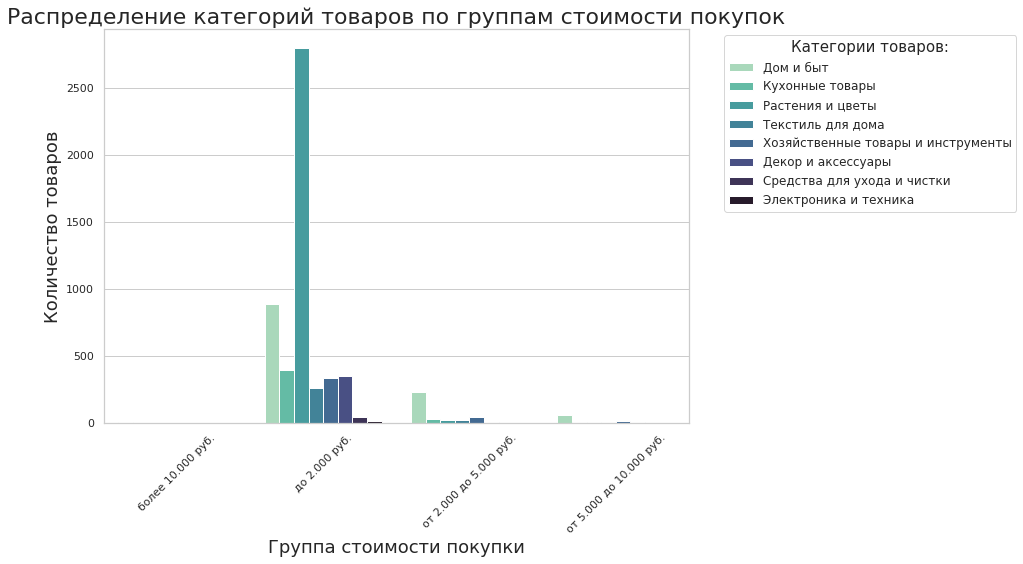

In [97]:
# Визуализируем:
# Определим количество уникальных категорий
num_categories = category_distribution['category'].nunique()

mako_palette = sns.color_palette("mako", n_colors=num_categories)[::-1] 

plt.figure(figsize=(14, 8))

sns.barplot(
    data=category_distribution,
    x='price_group',
    y='count by category',
    hue='category',
    palette=mako_palette
)

plt.title('Распределение категорий товаров по группам стоимости покупок', fontsize=22)
plt.xlabel('Группа стоимости покупки', fontsize=18)
plt.ylabel('Количество товаров', fontsize=18)
plt.xticks(rotation=45)
plt.legend(
    title='Категории товаров:', 
    bbox_to_anchor=(1.05, 1), 
    loc='upper left', 
    fontsize=12, 
    title_fontsize=15)

plt.tight_layout()
plt.show()

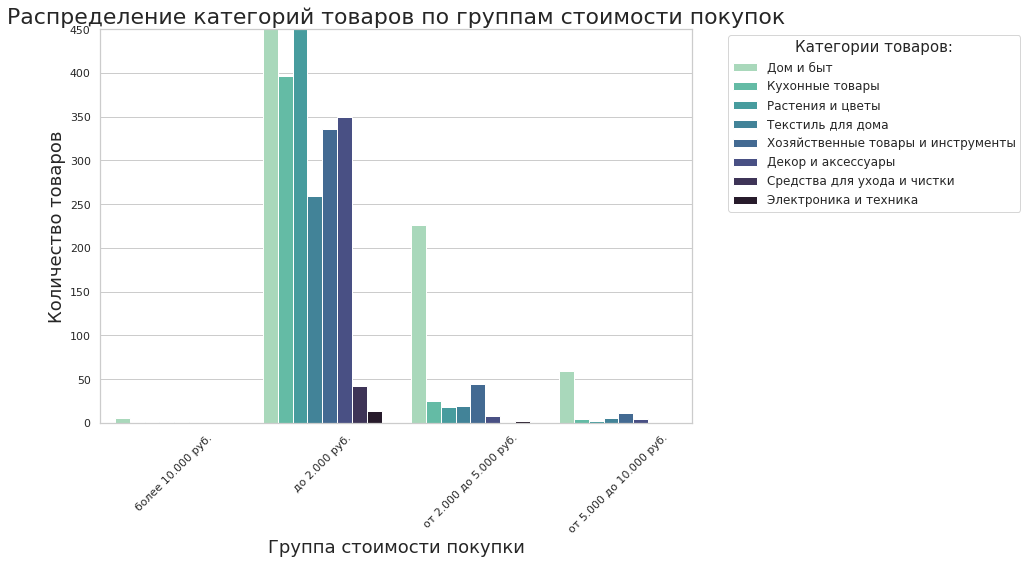

In [98]:
# Поменяем масштаб:
plt.figure(figsize=(14, 8))

sns.barplot(
    data=category_distribution,
    x='price_group',
    y='count by category',
    hue='category',
    palette=mako_palette
)

plt.title('Распределение категорий товаров по группам стоимости покупок', fontsize=22)
plt.xlabel('Группа стоимости покупки', fontsize=18)
plt.ylabel('Количество товаров', fontsize=18)
plt.xticks(rotation=45)

# Ограничиваем максимальное значение на оси Y
plt.ylim(0,450)

plt.legend(
    title='Категории товаров:', 
    bbox_to_anchor=(1.05, 1), 
    loc='upper left', 
    fontsize=12, 
    title_fontsize=15)

plt.tight_layout()
plt.show()

<div style="border:solid green 2px; padding: 30px">
    
<b> ИТОГО:</b>

Мы видим, что категория товаров "Растения и цветы" преобладают среди товаров группы до 2000 руб.
    
А вот товары категории "Дом и быт" лидируют в остальных группах товаров по стоимости. 
    
В основном товары, которые куплены больше , чем за 10000 руб. принадлежат категории "Дом и быт", и лишь несколько товаров принадлежат остальным категориям, кроме "декора", "элетроники и техники" и "средств для ухода и чистки" - среди этих категорий нет дорогих товаров. 

ВТОРОЙ СПОСОБ ВИЗУАЛИЗАЦИИ:

In [99]:
# Группируем данные по price_group и category
category_distribution_2 = data.groupby(['price_group', 'category']).size().unstack(fill_value=0)
display(category_distribution_2)

category,Декор и аксессуары,Дом и быт,Кухонные товары,Растения и цветы,Средства для ухода и чистки,Текстиль для дома,Хозяйственные товары и инструменты,Электроника и техника
price_group,,,,,,,,
более 10.000 руб.,0,5,1,1,0,1,1,0
до 2.000 руб.,350,886,397,2797,42,259,336,13
от 2.000 до 5.000 руб.,8,226,25,18,1,19,44,2
от 5.000 до 10.000 руб.,4,59,4,2,0,6,11,0


<Figure size 1008x576 with 0 Axes>

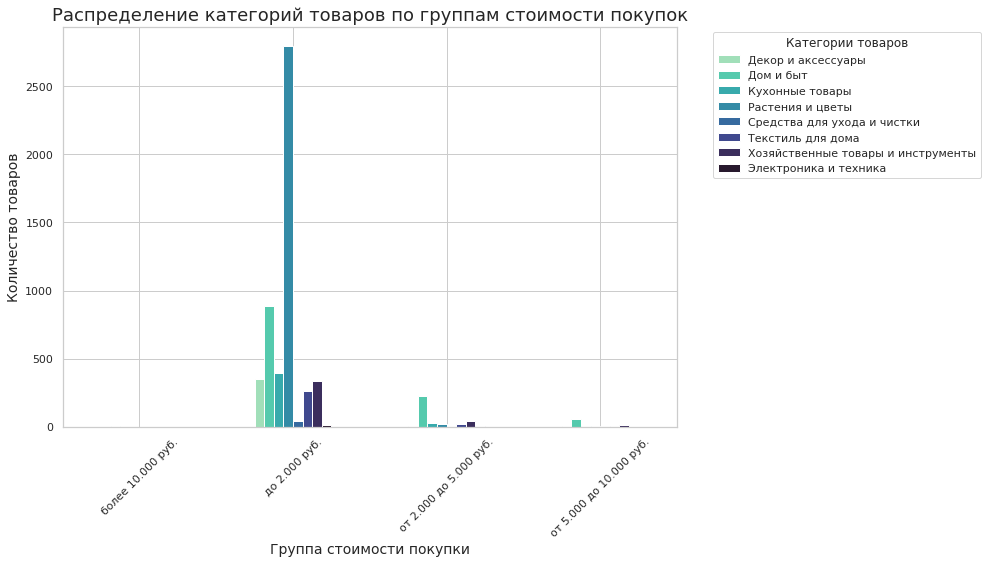

In [100]:
# Создаем палитру 'mako' из seaborn
mako_palette = sns.color_palette("mako", n_colors=category_distribution_2.shape[1])[::-1]

# Построение графика
plt.figure(figsize=(14, 8))

# Создаем столбчатую диаграмму с палитрой "mako"
category_distribution_2.plot(kind='bar', stacked=False, figsize=(14, 8), color=mako_palette)

# Настройка заголовка и меток
plt.title('Распределение категорий товаров по группам стоимости покупок', fontsize=18)
plt.xlabel('Группа стоимости покупки', fontsize=14)
plt.ylabel('Количество товаров', fontsize=14)
plt.xticks(rotation=45)  # Поворот меток на оси X
plt.legend(title='Категории товаров', bbox_to_anchor=(1.05, 1), loc='upper left')

# Настройка отображения графика
plt.tight_layout()
plt.show()

<Figure size 1008x576 with 0 Axes>

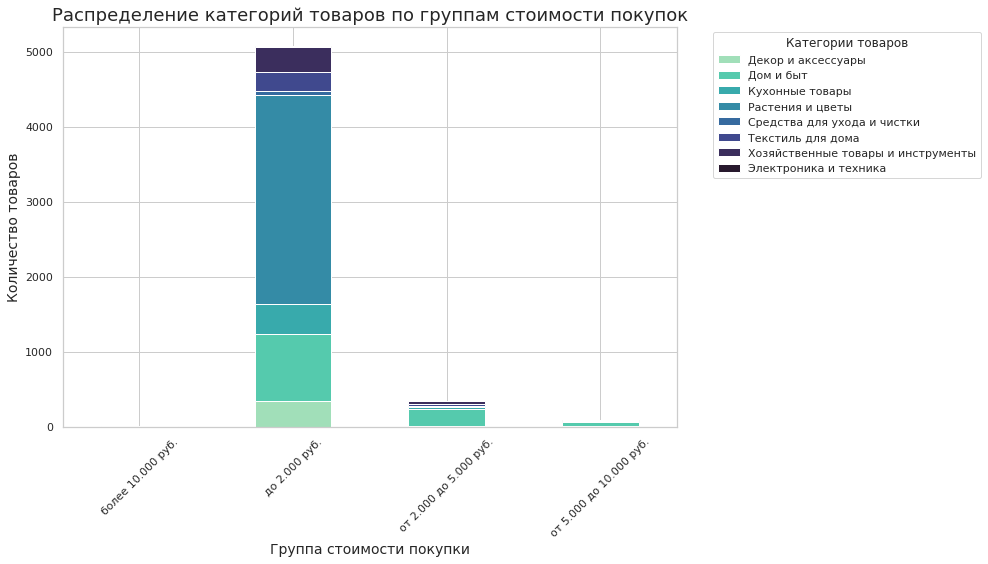

In [101]:
# Визуализируем:

mako_palette = sns.color_palette("mako", n_colors=category_distribution_2.shape[1])[::-1]


plt.figure(figsize=(14, 8))

category_distribution_2.plot(kind='bar', stacked=True, figsize=(14, 8), color=mako_palette)

plt.title('Распределение категорий товаров по группам стоимости покупок', fontsize=18)
plt.xlabel('Группа стоимости покупки', fontsize=14)
plt.ylabel('Количество товаров', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='Категории товаров', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### 2. Частота покупок:

#### 1. Частота заказов на одного клиента:

In [102]:
order_counts = data.groupby('customer_id')['order_id'].nunique()
order_counts_sorted = order_counts.sort_values(ascending=False)

In [103]:
display(order_counts_sorted)

customer_id
c971fb21-d54c-4134-938f-16b62ee86d3b    126
4d93d3f6-8b24-403b-a74b-f5173e40d7db     35
73d1cd35-5e5f-4629-8cf2-3fda829d4e58     17
b7b865ab-0735-407f-8d0c-31f74d2806cc      7
0184f535-b60a-4914-a982-231e3f615206      5
498f12a4-6a62-4725-8516-cf5dc9ab8a3a      4
bea7a833-2074-42db-bc49-4457abd3c930      4
e0535076-6270-4df2-8621-cb06264a94fa      4
d16fbc13-50a6-4dea-aafc-bc197aafc9e4      3
6a86cc77-ef15-496f-b5d3-89005597ee5d      3
e8204583-4d55-4724-ad3f-049c7db43bdd      3
eb6521ae-56e3-4a72-9ea2-e9c69701ff3f      3
639c4989-b0ab-412a-b7ec-be394cb2d372      3
552e17df-ba16-4e66-84fb-55a5557a6bea      3
a9089b7e-e6a5-48f9-9b76-48693b63a092      3
f163e581-59ba-4022-99db-e0973c7497c0      3
0adba506-249c-40b5-839d-a59d7a275cd7      3
62952c5b-e5ef-4009-a2f9-1ebff401c514      3
6b0c6cfb-7717-4c34-8535-bbc6e2b2c758      3
4856a2a7-b9d2-4243-b8d9-a96ec1425bbe      3
41117d9d-94f7-4145-a8c9-cb6675ce7674      3
7d0641a6-e043-487d-b356-38895fe7df84      3
7d64b4ea-d03f-4c3a-b

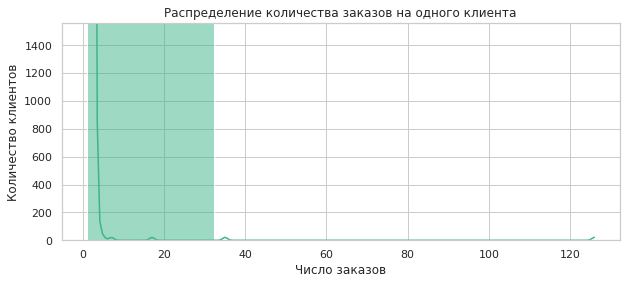

Среднее количество заказов на клиента: 1.44
Медианное количество заказов на клиента: 1.0
Максимальное количество заказов на клиента: 126


In [104]:
# Построим визуализацию:

plt.figure(figsize=(10, 4))
sns.histplot(order_counts, bins=4, kde=True, color='#3EB489')
plt.title('Распределение количества заказов на одного клиента')
plt.xlabel('Число заказов')
plt.ylabel('Количество клиентов')

# Устанавливаем ось Y так, чтобы минимальное значение было больше 0 (например, от 0 до 100)
plt.ylim(0, order_counts.value_counts().max() + 10)  # Увеличим верхний предел оси Y

plt.show()

print("Среднее количество заказов на клиента:", round(order_counts.mean(), 2))
print("Медианное количество заказов на клиента:", order_counts.median())
print("Максимальное количество заказов на клиента:", order_counts.max())

*Данные слишком скошены вправо. Есть клиенты со слишком большим количеством заказов и их мало.*

Мы видим по графику эти значения с 126, 35, 17, 7 заказами. 

Посмотрим на самых часто заказывающих клиентов:

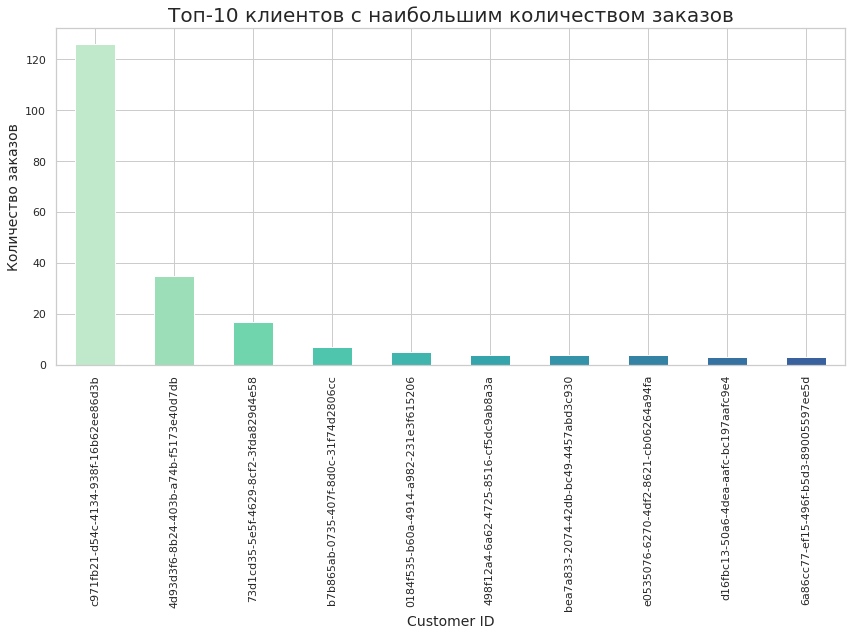

In [105]:
# Берем топ-10 клиентов с наибольшим количеством заказов
top_10_customers = order_counts_sorted.head(10)

# Получаем цвета из палитры
colors = sns.color_palette('mako', n_colors=16)[::-1]
#colors = sns.color_palette('PuBuGn_r', n_colors=16)
#colors = sns.color_palette("summer", len(top_10_customers))
# colors = sns.cubehelix_palette(start=2, rot=0, dark=0.3, light=0.8, n_colors=15)

# Строим столбчатую диаграмму с разными цветами для каждого столбца
plt.figure(figsize=(12, 9))
top_10_customers.plot(kind='bar', color=colors)

# Настроим заголовки и подписи осей
plt.title('Топ-10 клиентов с наибольшим количеством заказов', fontsize=20)
plt.xlabel('Customer ID', fontsize=14)
plt.ylabel('Количество заказов', fontsize=14)

# Поворот подписей по оси X для лучшей читаемости
plt.xticks()

# Покажем график
plt.tight_layout()
plt.show()

Теперь посмотрим, сколько человек сделало 1 заказ, а сколько человек сделало больше 5 или 30:

In [106]:
# Группируем по количеству заказов и считаем, сколько таких клиентов:
order_freq = order_counts.value_counts().sort_index()

# Переименуем Series для читаемости
order_freq.index.name = 'Число заказов' # подпись для левого столбца 
order_freq.name = 'Число клиентов' # имя самой Series, заголовок второго столбца  

# Посмотрим результат
display(order_freq.to_frame())

,Число клиентов
Число заказов,
1,1551
2,831
3,18
4,3
5,1
7,1
17,1
35,1
126,1


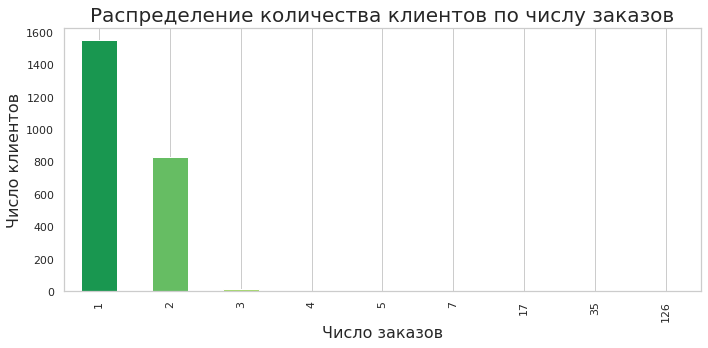

In [107]:
plt.figure(figsize=(10, 5))
order_freq.plot(kind='bar', color=sns.color_palette('RdYlGn', n_colors=9)[::-1])

plt.title('Распределение количества клиентов по числу заказов', fontsize=20)
plt.xlabel(order_freq.index.name, fontsize=16)
plt.ylabel(order_freq.name, fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Строим круговую диаграмму:

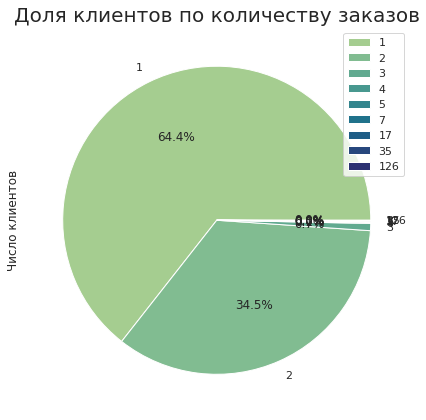

In [108]:
plt.figure(figsize=(6, 6))
order_freq.plot(
    kind='pie', 
    autopct='%1.1f%%', 
    legend=True,  # Добавление легенды
    cmap='crest')

plt.title('Доля клиентов по количеству заказов', fontsize=20)
plt.tight_layout()
plt.show()

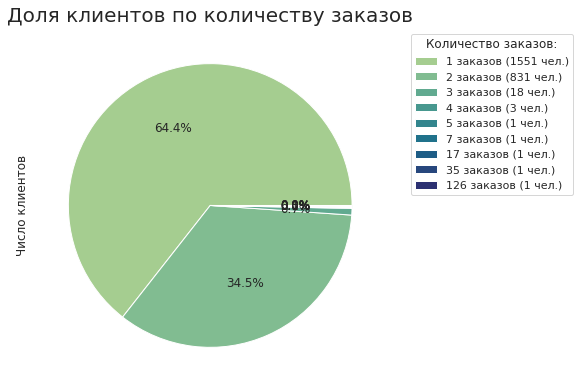

In [109]:
# Создаем метки для легенды, включая количество клиентов:
labels_legend = [f'{index} заказов ({value} чел.)' for index, value in order_freq.items()]

plt.figure(figsize=(8, 8))
order_freq.plot(
    kind='pie', 
    autopct='%1.1f%%',  # Показываем только проценты на графике
    legend=False,  # Отключаем стандартную легенду
    cmap='crest', 
    labels=[None] * len(order_freq)  # Убираем метки с самого графика
)

# Устанавливаем легенду с дополнительной информацией:
plt.legend(labels=labels_legend, title="Количество заказов:", bbox_to_anchor=(1.05, 1), loc='upper left')
# Вызов plt.legend() с параметрами bbox_to_anchor и loc позволяет разместить легенду за пределами графика
plt.title('Доля клиентов по количеству заказов', fontsize=20)
plt.tight_layout()
plt.show()

Посмотрим на этих клиентов у кого заказов больше или равно 5:

In [110]:
# Считаем количество заказов на каждого клиента
order_counts = data.groupby('customer_id')['order_id'].nunique()

# Фильтруем тех, у кого заказов 5 и больше
top_customers_5plus = order_counts[order_counts >= 5]
top_customers_5plus = top_customers_5plus.sort_values(ascending=False)

top_customers_5plus.index.name = 'customer_ids' # подпись для левого столбца 
top_customers_5plus.name = 'Общее количество заказов' # имя самой Series, заголовок второго столбца  
# Смотрим результат
display(top_customers_5plus.to_frame())

,Общее количество заказов
customer_ids,
c971fb21-d54c-4134-938f-16b62ee86d3b,126
4d93d3f6-8b24-403b-a74b-f5173e40d7db,35
73d1cd35-5e5f-4629-8cf2-3fda829d4e58,17
b7b865ab-0735-407f-8d0c-31f74d2806cc,7
0184f535-b60a-4914-a982-231e3f615206,5


In [111]:
# Фильтруем клиентов, у которых количество заказов >= 5:

customers_5plus = order_counts[order_counts >= 5].index # мне нужно использовать лишь индексы этих customer_id

# Получаем все строки из data для этих клиентов
filtered_data = data[data['customer_id'].isin(customers_5plus)]

# Сортируем по количеству заказов каждого клиента
filtered_data['order_count'] = filtered_data['customer_id'].map(order_counts)  # добавим столбец с количеством заказов

# Сортируем по числу заказов клиента (по убыванию), а затем по customer_id
sorted_filtered_data = filtered_data.sort_values(by=['order_count', 'customer_id'], ascending=[False, True])

# Смотрим результат
display(sorted_filtered_data.head(10))

,date,month,customer_id,order_id,product,category,quantity,price,total_price,season,price_group,order_count
9,2018-10-01 09:00:00,10,c971fb21-d54c-4134-938f-16b62ee86d3b,68480,чехол для гладильной доски соlоmbо реrsiа bеig...,Текстиль для дома,1,674.00,674.00,осень,до 2.000 руб.,126
20,2018-10-02 08:00:00,10,c971fb21-d54c-4134-938f-16b62ee86d3b,68490,чехол для гладильной доски fеsтivаl 137х60 см ...,Текстиль для дома,1,"1,162.00","1,162.00",осень,до 2.000 руб.,126
64,2018-10-03 08:00:00,10,c971fb21-d54c-4134-938f-16b62ee86d3b,68511,набор прищепок большие пластиковые rоzеnbаl пи...,Хозяйственные товары и инструменты,10,86.00,860.00,осень,до 2.000 руб.,126
65,2018-10-03 10:00:00,10,c971fb21-d54c-4134-938f-16b62ee86d3b,68514,сушилка для белья аттribuте прима 11 м синяя н...,Дом и быт,1,749.00,749.00,осень,до 2.000 руб.,126
130,2018-10-08 07:00:00,10,c971fb21-d54c-4134-938f-16b62ee86d3b,68561,тележка багажная dеlта тбр-20 коричневый с ора...,Дом и быт,1,742.00,742.00,осень,до 2.000 руб.,126
131,2018-10-08 08:00:00,10,c971fb21-d54c-4134-938f-16b62ee86d3b,68562,готовая скатерть ажурная diа rоsе круглая д.15...,Дом и быт,1,712.00,712.00,осень,до 2.000 руб.,126
132,2018-10-08 09:00:00,10,c971fb21-d54c-4134-938f-16b62ee86d3b,68563,сушилка для белья потолочная zаlgеr lifт bаsiс...,Дом и быт,1,614.00,614.00,осень,до 2.000 руб.,126
139,2018-10-08 13:00:00,10,c971fb21-d54c-4134-938f-16b62ee86d3b,68568,"таз пластмассовый 18,0 л квадратный (тп-18) ""п...",Хозяйственные товары и инструменты,1,254.00,254.00,осень,до 2.000 руб.,126
160,2018-10-09 09:00:00,10,c971fb21-d54c-4134-938f-16b62ee86d3b,68580,"стяжка оконная с болтом ст-55 цинк, 1108354",Дом и быт,64,19.00,"1,216.00",осень,до 2.000 руб.,126
171,2018-10-10 08:00:00,10,c971fb21-d54c-4134-938f-16b62ee86d3b,68596,сумка-тележка 3-х колесная gimi тris flоrаl синяя,Дом и быт,1,"2,699.00","2,699.00",осень,от 2.000 до 5.000 руб.,126


Посмотрим теперь по стоимости статистику на отдельный вид числа заказов:

In [112]:
# Суммируем покупки для каждого клиента
total_spent_per_customer = data.groupby('customer_id')['total_price'].sum()

# уже имеющаяся группировка:
# order_counts = data.groupby('customer_id')['order_id'].nunique()

# Группируем по количеству заказов и считаем, сколько таких клиентов
order_freq_for_price = order_counts.value_counts().sort_index()

# Переименуем Series для читаемости
order_freq_for_price.index.name = 'Число заказов'
order_freq_for_price.name = 'Число клиентов'

# Агрегируем сумму покупок для каждого числа заказов:
# Определим, сколько потратил каждый клиент в зависимости от числа его заказов
total_spent_by_order_count = total_spent_per_customer.groupby(order_counts).sum()

# Объединяем информацию о числе клиентов и общей сумме покупок
order_freq_df = order_freq_for_price.to_frame()
order_freq_df['Общая сумма покупок'] = total_spent_by_order_count

# Посмотрим результат
display(order_freq_df)

,Число клиентов,Общая сумма покупок
Число заказов,,
1,1551,"1,901,256.50"
2,831,"1,458,314.92"
3,18,"54,232.00"
4,3,"46,945.00"
5,1,"5,891.00"
7,1,"3,779.00"
17,1,"21,361.00"
35,1,"57,278.00"
126,1,"159,508.00"


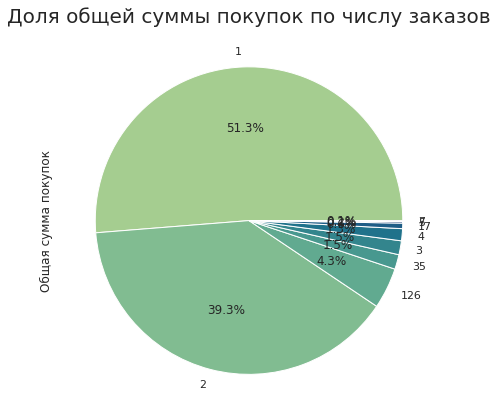

In [113]:
# Строим круговую диаграмму с долей из столбца "Общая сумма покупок":


# Сортируем данные по убыванию общей суммы покупок:
order_freq_df_sorted = order_freq_df.sort_values(by='Общая сумма покупок', ascending=False)


plt.figure(figsize=(6, 6))
order_freq_df_sorted['Общая сумма покупок'].plot(
    kind='pie', 
    autopct='%1.1f%%',  # Показываем процент
    labels=order_freq_df_sorted.index,  # Подписи из "Число заказов"
    legend=False,  # Отключаем стандартную легенду
    cmap='crest'
)

plt.title('Доля общей суммы покупок по числу заказов', fontsize=20)
plt.tight_layout()

plt.show()



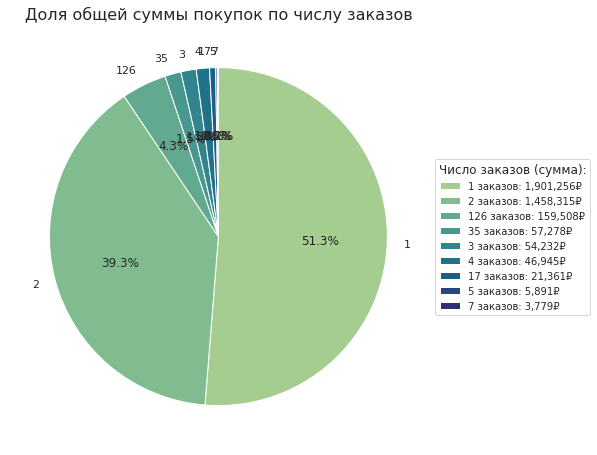

In [114]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Получаем значения и подписи
values = order_freq_df_sorted['Общая сумма покупок']
labels = order_freq_df_sorted.index.astype(str)

# Генерируем цвета из colormap 'crest'
cmap = cm.get_cmap('crest', len(values))
colors_total_price = [mcolors.to_hex(cmap(i)) for i in range(len(values))]

# Подписи для легенды
legend_labels = [
    f"{index} заказов: {value:,.0f}₽"
    for index, value in zip(labels, values)
]

# Строим круговую диаграмму
fig, ax = plt.subplots(figsize=(8, 7))
wedges, texts, autotexts = ax.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    colors=colors_total_price
)

# Добавляем легенду с цветами
ax.legend(
    wedges, legend_labels,
    title='Число заказов (сумма):',
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    fontsize=10
)

plt.title('Доля общей суммы покупок по числу заказов', fontsize=16)
plt.tight_layout()
plt.show()

<div style="border:solid green 2px; padding: 30px">
    
<b> ИТОГО:</b>
    
Анализируя количество покупок на одного клиента, мы обнаружили одного клиента, который сделал больше всех заказов (126 заказов), с большим отрывом по количеству заказов от остальных покупателей (на втором месте по числу заказов стоит клиент, сделавший 35 покупок). 
    
Стоит удалить из датасета клиента, который сделал 126 заказов с долей трат, которая является 3 по доле трат по общей сумме всех заказов в датасете за рассматриваемый в датасете период.

In [115]:
# Удалим пользователя, сделавшего 126 покупок:

customers_to_drop = order_counts[order_counts == 126].index
data = data[~data['customer_id'].isin(customers_to_drop)]

#### 2. Распределение заказов по месяцам и дням (поиск пиков):

Добавим ещё вспомогательные столбцы:

In [117]:
data['day_of_week'] = data['date'].dt.dayofweek  # 0 — понедельник, 6 — воскресенье
data.head()

,date,month,customer_id,order_id,product,category,quantity,price,total_price,season,price_group,day_of_week
0,2018-10-01,10,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"комнатное растение в горшке алое вера, d12, h30",Растения и цветы,1,142.00,142.00,осень,до 2.000 руб.,0
1,2018-10-01,10,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"комнатное растение в горшке кофе арабика, d12,...",Растения и цветы,1,194.00,194.00,осень,до 2.000 руб.,0
2,2018-10-01,10,ee47d746-6d2f-4d3c-9622-c31412542920,68477,радермахера d-12 см h-20 см,Растения и цветы,1,112.00,112.00,осень,до 2.000 руб.,0
3,2018-10-01,10,ee47d746-6d2f-4d3c-9622-c31412542920,68477,хризолидокарпус лутесценс d-9 см,Растения и цветы,1,179.00,179.00,осень,до 2.000 руб.,0
4,2018-10-01,10,ee47d746-6d2f-4d3c-9622-c31412542920,68477,циперус зумула d-12 см h-25 см,Растения и цветы,1,112.00,112.00,осень,до 2.000 руб.,0


In [118]:
# Создаем колонку "год-месяц", так как месяцы октябрь, ноябрь и декабрь повторяются дважды в данных за разные годы:
data['year_month'] = data['date'].dt.to_period('M')  # формат YYYY-MM
data.head(3)

,date,month,customer_id,order_id,product,category,quantity,price,total_price,season,price_group,day_of_week,year_month
0,2018-10-01,10,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"комнатное растение в горшке алое вера, d12, h30",Растения и цветы,1,142.00,142.00,осень,до 2.000 руб.,0,2018-10
1,2018-10-01,10,ee47d746-6d2f-4d3c-9622-c31412542920,68477,"комнатное растение в горшке кофе арабика, d12,...",Растения и цветы,1,194.00,194.00,осень,до 2.000 руб.,0,2018-10
2,2018-10-01,10,ee47d746-6d2f-4d3c-9622-c31412542920,68477,радермахера d-12 см h-20 см,Растения и цветы,1,112.00,112.00,осень,до 2.000 руб.,0,2018-10


**По месяцам:**

In [119]:
# Группируем по 'year_month' и считаем уникальных клиентов:
monthly_customers = data.groupby('year_month')['customer_id'].nunique()


# Группируем по количеству заказов и считаем, сколько таких клиентов
monthly_customers_index = monthly_customers.sort_index()

monthly_customers_index.index.name = 'Месяц-год'
monthly_customers_index.name = 'Число клиентов'

display(monthly_customers_index.to_frame())

,Число клиентов
Месяц-год,
2018-10,178
2018-11,176
2018-12,226
2019-01,148
2019-02,244
2019-03,227
2019-04,235
2019-05,164
2019-06,147


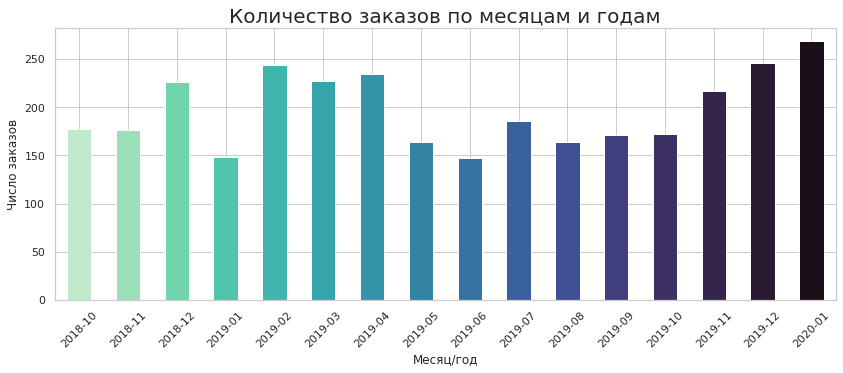

In [120]:
# Визуализируем:
plt.figure(figsize=(14, 5))
monthly_customers.plot(kind='bar', color=colors)
plt.title('Количество заказов по месяцам и годам', fontsize=20)
plt.xlabel('Месяц/год')
plt.ylabel('Число заказов')
plt.xticks(rotation=45)
plt.show()

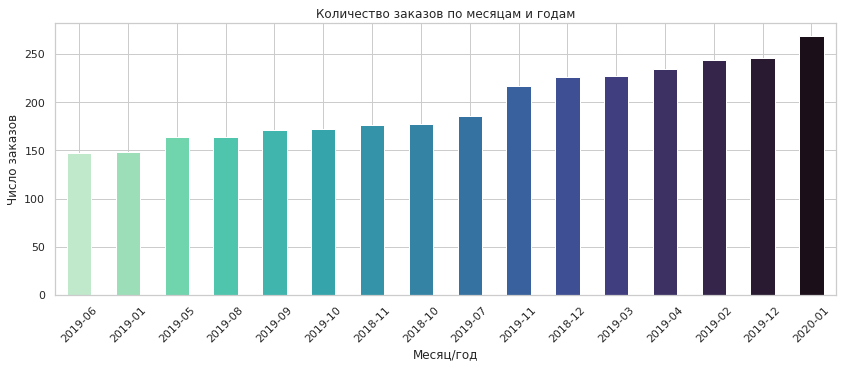

In [121]:
# Сортируем данные по возрастанию:
monthly_customers_sorted = monthly_customers.sort_values(ascending=True)


plt.figure(figsize=(14, 5))
monthly_customers_sorted.plot(kind='bar', color=colors)  # Каждый столбец будет своего цвета
plt.title('Количество заказов по месяцам и годам')
plt.xlabel('Месяц/год')
plt.ylabel('Число заказов')
plt.xticks(rotation=45)
plt.show()

*Отметим сезонность:*

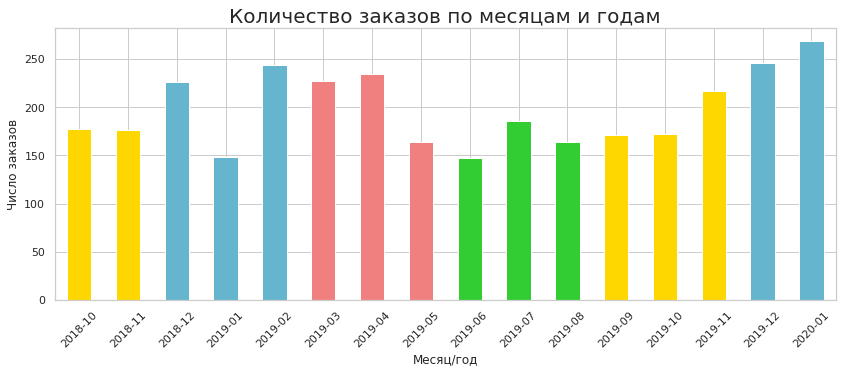

In [122]:
# Создаем список цветов для каждого сезона:

season_colors = {
    'зима': 'c',   # синий для зимы
    'весна': 'lightcoral',  #  розовый для весны
    'лето': 'limegreen',  # зеленыйдля лета
    'осень': 'gold'  #  желтый для осени
}

# Маппируем цвета на основе сезона для каждого месяца
season_colors = [season_colors[season] for season in data.groupby('year_month')['season'].first()]

# Построение графика
plt.figure(figsize=(14, 5))
monthly_customers.plot(kind='bar', color=season_colors)  # Столбцы будут окрашены в зависимости от сезона
plt.title('Количество заказов по месяцам и годам', fontsize=20)
plt.xlabel('Месяц/год')
plt.ylabel('Число заказов')
plt.xticks(rotation=45)
plt.show()

**По дням недели:**

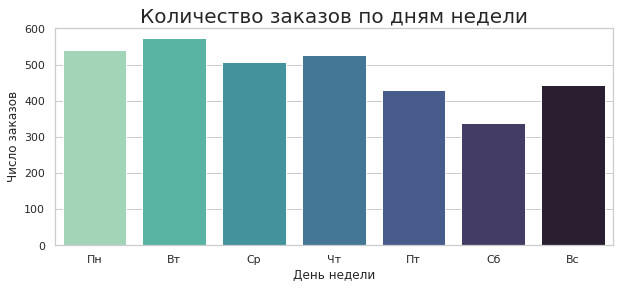

In [123]:
day_orders = data.groupby('day_of_week')['order_id'].nunique()

days = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
day_colors = sns.color_palette('mako', n_colors=7)[::-1]

plt.figure(figsize=(10, 4))
sns.barplot(x=days, y=day_orders.values, palette=day_colors)
plt.title('Количество заказов по дням недели', fontsize=20)
plt.xlabel('День недели')
plt.ylabel('Число заказов')
plt.show()

<div style="border:solid green 2px; padding: 30px">
    
<b> ИТОГО:</b>
    
Добавили ещё вспомогательные столбцы: day_of_week и year_month.
    
Построив графики распределения количества заказов по месяцам, сезонам и дням недели, мы заметили, что:
    
- больше всего заказов делаются зимой, потом весной, меньше всего летом.
    
- наибольшее число покупок было сделано в декабре 2018, феврале 2019, марте-апреле 2019 и декабре 2019 и январе 2020. Максимальное количество покупок сделано было в январе 2020. 
    
- Кастельно дней недели: наибольшее количество заказов приходится на вторник, затем понедельник. В целом , кажется, что в будние дни покупательская активность более сильная. Однако в выходные: в воскресенье люди чаще покупают, нежели чем в субботу.


### 3. Популярность товаров:

#### 1. Топ-15 товаров по количеству купленного товара:

In [124]:
top_15_products = data.groupby('product')['quantity'].sum().sort_values(ascending=False).head(15)
# display(top_20_products)

In [125]:
# Переименовываем индексы и столбцы для читаемости
top_15_products.index.name = 'Наименование товара'
top_15_products.name = 'Общее число товара'

# Показываем результат
display(top_15_products.to_frame())

,Общее число товара
Наименование товара,
муляж яблоко 9 см красное,318
"ручка-скоба рс-100 белая *трибатрон*, 1108035",201
"крепеж для пружины дверной, 1107055",170
плечики пластмассовые размер 52 - 54 тула 1205158,160
"пружина дверная 240 мм оцинкованная (д-19 мм) без крепления, 1107014",150
муляж яблоко зеленый 9 см полиуретан,148
муляж банан желтый 21 см полиуретан,109
"щетка-сметка 4-х рядная деревянная 300 мм (фигурная ручка) ворс 5,5 см 1801096",105
"щетка для посуды *оля*, мультипласт 1807010",101


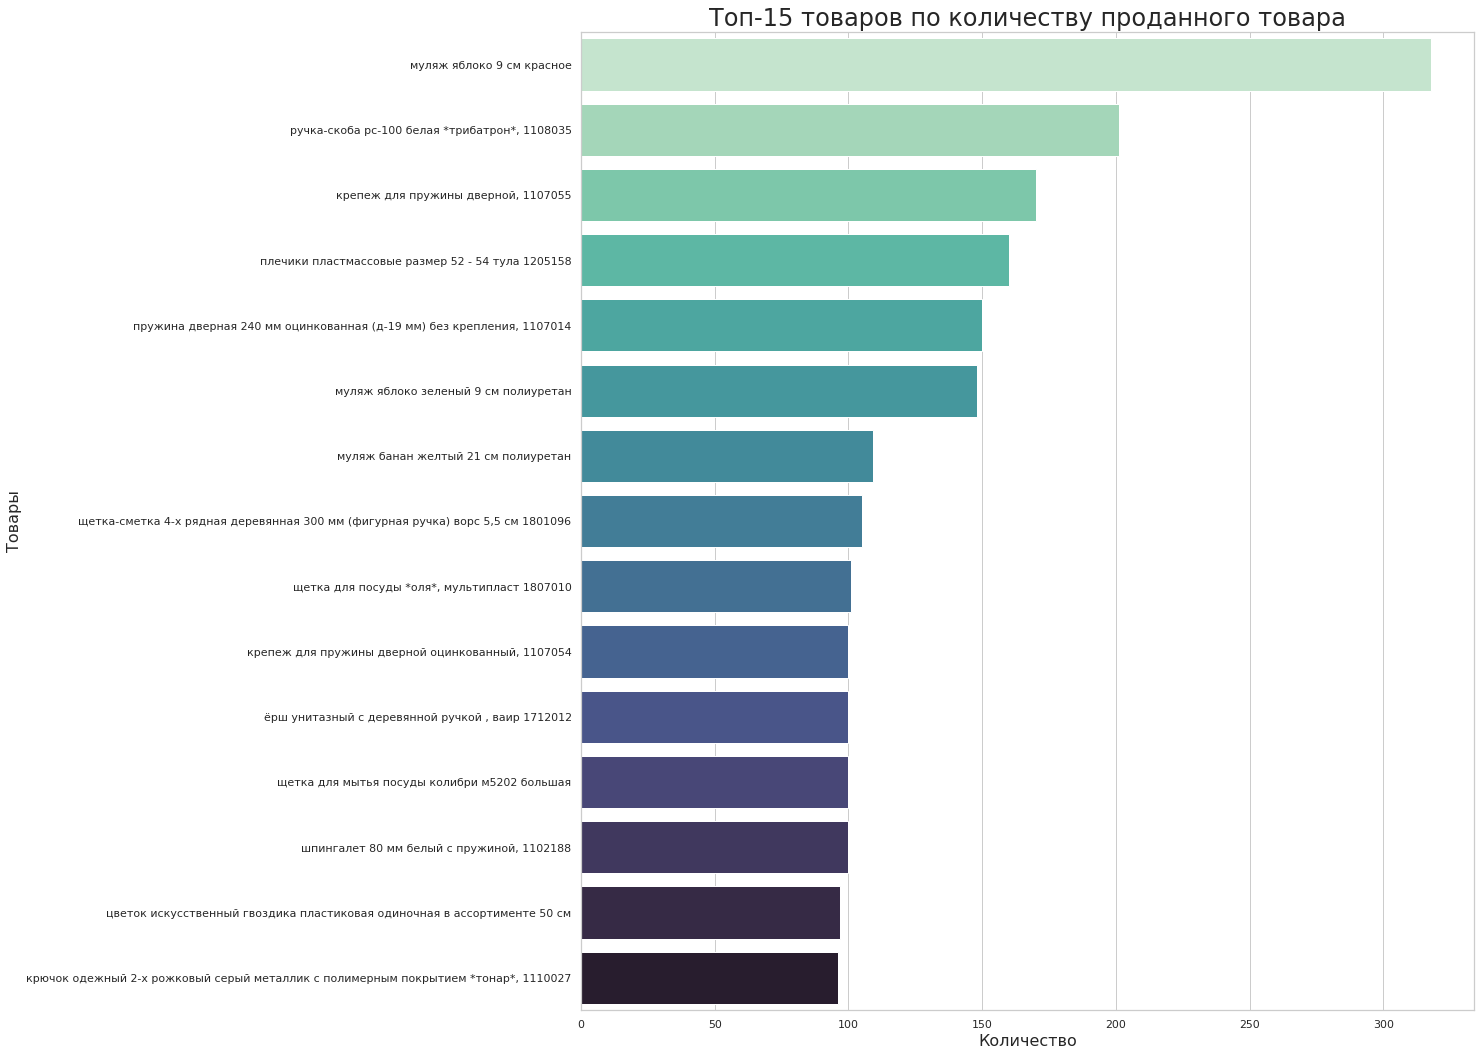

In [126]:
plt.figure(figsize=(16, 18))
sns.barplot(x=top_15_products.values, y=top_15_products.index, palette= colors)
plt.title('Топ-15 товаров по количеству проданного товара', fontsize=24)
plt.xlabel('Количество', fontsize=16)
plt.ylabel('Товары', fontsize=16)
plt.show()

#### 2. Топ-15 товаров по количеству заказов:

In [127]:
top_15_products_by_order = data.groupby('product')['order_id'].count().sort_values(ascending=False).head(15)

top_15_products_by_order.index.name = 'Наименование товара'
top_15_products_by_order.name = 'Общее количество заказов данного товара'

# Показываем результат
display(top_15_products_by_order.to_frame())

,Общее количество заказов данного товара
Наименование товара,
пеларгония розебудная rеd раndоrа укорененный черенок,63
пеларгония розебудная рrins nikоlаi укорененный черенок,54
пеларгония зональная диам. 12 см сиреневый полумахровый,53
сумка-тележка 2-х колесная gimi аrgо синяя,43
пеларгония розебудная mаrу укорененный черенок,40
пеларгония розебудная mаrgаrетhа укорененный черенок,31
пеларгония розебудная quееn ingrid укорененный черенок,31
пеларгония зональная махровая лососевая,25
пеларгония зональная ринго вайт d-7 см h-10 см укорененный черенок,25


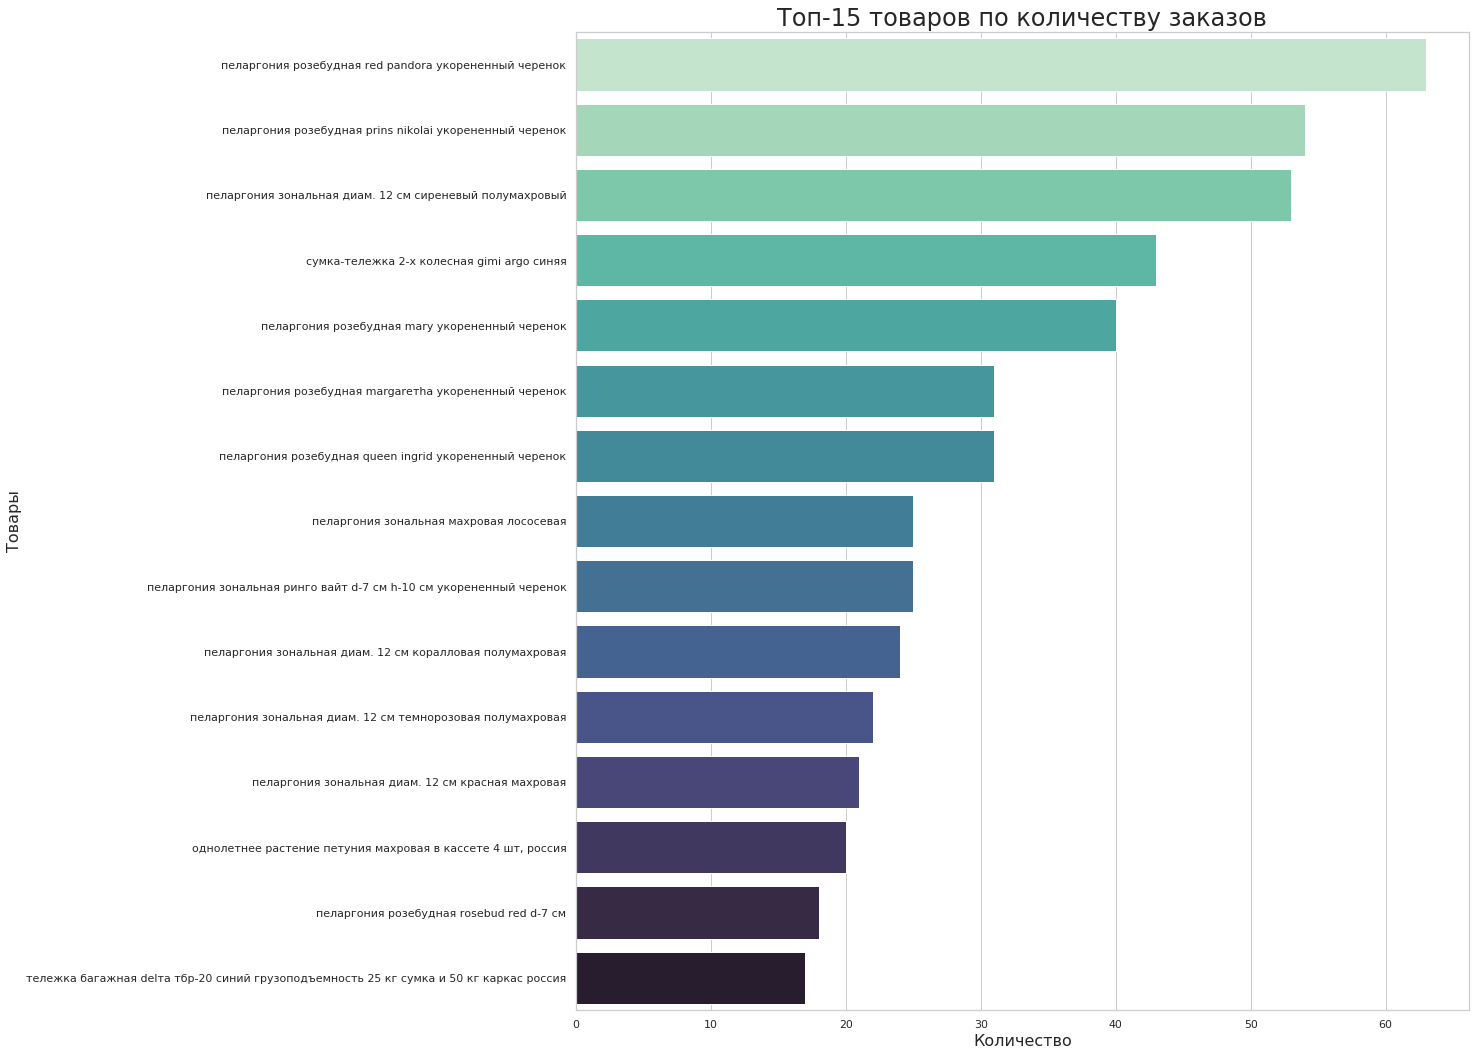

In [128]:
plt.figure(figsize=(16, 18))
sns.barplot(x=top_15_products_by_order.values, y=top_15_products_by_order.index, palette = colors)
plt.title('Топ-15 товаров по количеству заказов', fontsize=24)
plt.xlabel('Количество', fontsize=16)
plt.ylabel('Товары', fontsize=16)
plt.show()

#### 3. Наиболее популярные категории товаров:

In [129]:
popular_categories = data.groupby('category')['category'].count().sort_values(ascending=False)

popular_categories.index.name = 'Категория товаров'
popular_categories.name = 'Количество трансзакций товаров данной категории'

display(popular_categories.to_frame())

,Количество трансзакций товаров данной категории
Категория товаров,
Растения и цветы,2787
Дом и быт,1109
Кухонные товары,418
Хозяйственные товары и инструменты,378
Декор и аксессуары,356
Текстиль для дома,271
Средства для ухода и чистки,42
Электроника и техника,14


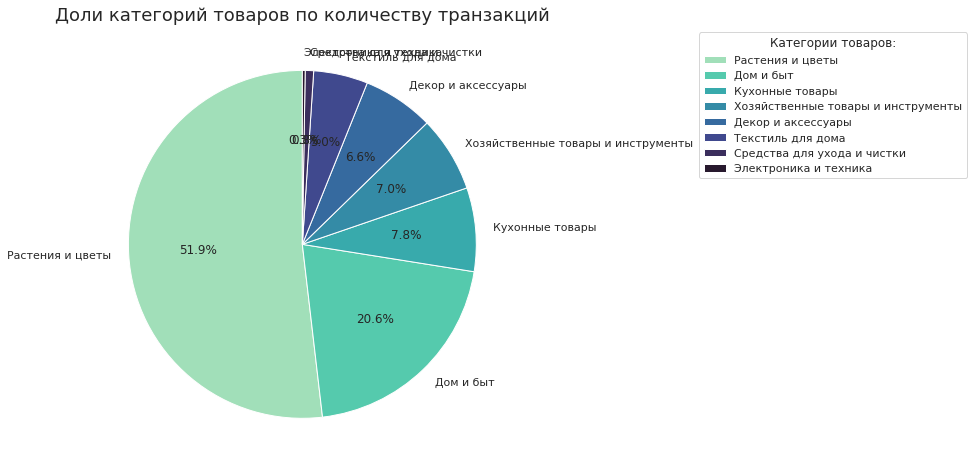

In [130]:
# Создаем круговую диаграмму для популярности категорий:

category_colors = sns.color_palette('mako', n_colors=8)[::-1]

# Сортируем данные по убыванию:
popular_categories_sorted = popular_categories.sort_values(ascending=False)


plt.figure(figsize=(8, 8))
plt.pie(popular_categories_sorted.values, 
        labels=popular_categories_sorted.index, 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=category_colors)

plt.legend(
    popular_categories_sorted.index, 
    title='Категории товаров:', 
    loc='upper left', 
    bbox_to_anchor=(1.4, 1)
)

plt.title('Доли категорий товаров по количеству транзакций', fontsize=18)

plt.show()

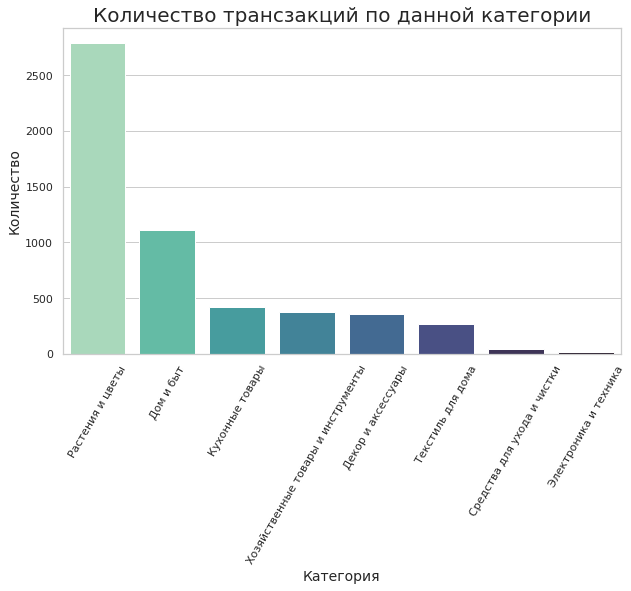

In [131]:
plt.figure(figsize=(10, 6))
sns.barplot(x=popular_categories.index , y=popular_categories.values, palette= category_colors)
plt.title('Количество трансзакций по данной категории', fontsize=20)
plt.xlabel('Категория', fontsize=14)
plt.ylabel('Количество', fontsize=14)
plt.xticks(rotation=60)
plt.show()

#### 4. Наиболее прибыльные категории товаров:

In [132]:
profitable_categories = data.groupby('category')['total_price'].sum().sort_values(ascending=False)

profitable_categories.index.name = 'Категория товаров'
profitable_categories.name = 'Общая выручка по категории'

display(profitable_categories.to_frame())

,Общая выручка по категории
Категория товаров,
Дом и быт,"1,822,958.58"
Растения и цветы,"587,835.33"
Хозяйственные товары и инструменты,"412,141.00"
Кухонные товары,"298,722.00"
Текстиль для дома,"261,087.17"
Декор и аксессуары,"137,748.33"
Средства для ухода и чистки,"16,217.00"
Электроника и техника,"12,348.00"


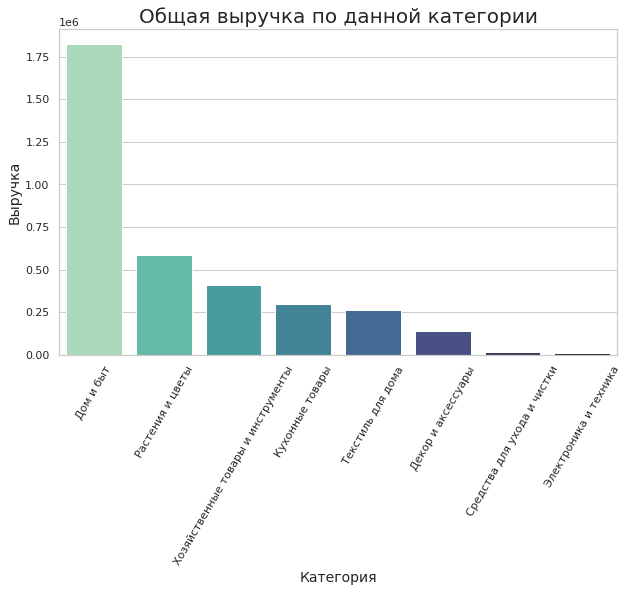

In [133]:
plt.figure(figsize=(10, 6))
sns.barplot(x=profitable_categories.index , y=profitable_categories.values, palette= category_colors)
plt.title('Общая выручка по данной категории', fontsize=20)
plt.xlabel('Категория', fontsize=14)
plt.ylabel('Выручка', fontsize=14)
plt.xticks(rotation=60)
plt.show()

#### 5. Покупатели с самыми дорогими покупками по сезонам:

In [134]:
seasonal_top_customers = (
    data.groupby(['season', 'customer_id'])['total_price']
    .sum()
    .reset_index()
    .sort_values(['season', 'total_price'], ascending=[True, False])
)
display(seasonal_top_customers)

In [135]:
# Получим топ-5 покупателей по каждому сезону:
top_5_by_season = (
    seasonal_top_customers.groupby('season')
    .head(5)
)
display(top_5_by_season)

,season,customer_id,total_price
186,весна,498f12a4-6a62-4725-8516-cf5dc9ab8a3a,"41,900.00"
397,весна,a9089b7e-e6a5-48f9-9b76-48693b63a092,"11,495.00"
4,весна,02adb72a-3067-45e9-a3b5-f93d79d7496a,"10,723.00"
507,весна,d35ce92b-08ec-46a5-87c5-2ef42c65ed3e,"10,656.00"
463,весна,c0c60544-3a99-49d0-8a8e-cf7f293c22cb,"8,737.00"
1178,зима,909564b8-3a5c-4d3e-8310-5ba1c837bbd7,"16,536.00"
1581,зима,f279d50f-a508-40b4-bde5-5cb4a1be3ad0,"15,358.00"
1135,зима,86c97bf1-c834-423e-9e38-8acda68f97e8,"11,548.00"
1024,зима,6be74251-7159-4cc0-99fb-d034a17c61b0,"11,250.00"
1285,зима,af4d270b-c7ae-4af5-9582-4e61ff08eff0,"11,000.00"


In [136]:
top_5_by_season_sorted = top_5_by_season.sort_values(['season', 'total_price'], ascending=[True, False])
display(top_5_by_season_sorted)

,season,customer_id,total_price
186,весна,498f12a4-6a62-4725-8516-cf5dc9ab8a3a,"41,900.00"
397,весна,a9089b7e-e6a5-48f9-9b76-48693b63a092,"11,495.00"
4,весна,02adb72a-3067-45e9-a3b5-f93d79d7496a,"10,723.00"
507,весна,d35ce92b-08ec-46a5-87c5-2ef42c65ed3e,"10,656.00"
463,весна,c0c60544-3a99-49d0-8a8e-cf7f293c22cb,"8,737.00"
1178,зима,909564b8-3a5c-4d3e-8310-5ba1c837bbd7,"16,536.00"
1581,зима,f279d50f-a508-40b4-bde5-5cb4a1be3ad0,"15,358.00"
1135,зима,86c97bf1-c834-423e-9e38-8acda68f97e8,"11,548.00"
1024,зима,6be74251-7159-4cc0-99fb-d034a17c61b0,"11,250.00"
1285,зима,af4d270b-c7ae-4af5-9582-4e61ff08eff0,"11,000.00"


In [137]:
# К каждому уникальному покупателю свой цвет на графике присвоим:
    
unique_customers = top_5_by_season['customer_id'].unique()

# Создадим палитру с нужным числом цветов:
palette = sns.color_palette('plasma', len(unique_customers))[::-1]

# Сопоставим каждому покупателю свой цвет:
customer_color_map = dict(zip(unique_customers, palette))

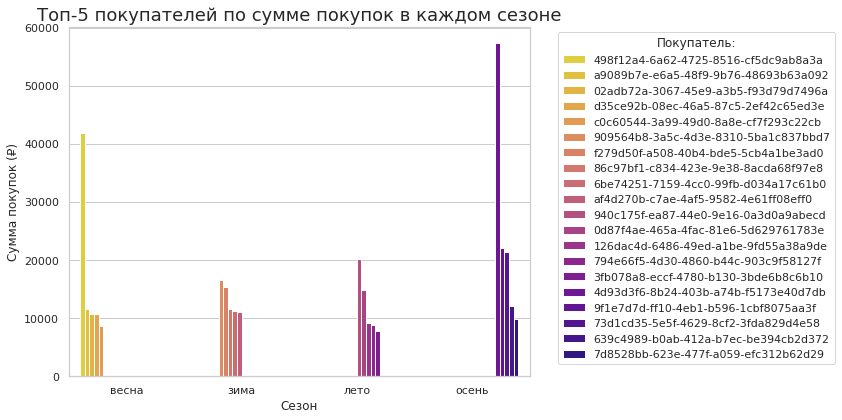

In [138]:
# Визуализируем:

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_5_by_season,
    x='season',
    y='total_price',
    hue='customer_id',
    palette=customer_color_map
    #palette='Paired'palette = sns.color_palette('hsv', len(unique_customers))
)
plt.title('Топ-5 покупателей по сумме покупок в каждом сезоне', fontsize=18)
plt.ylabel('Сумма покупок (₽)')
plt.xlabel('Сезон')
plt.legend(title='Покупатель:', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### 6. Топ-покупатели по каждому сезону по среднему чеку за заказ:

In [139]:
seasonal_avg_check = (
    data.groupby(['season', 'customer_id']).agg({
        'total_price': 'sum',
        'order_id': 'nunique'
    }).reset_index()
)

In [140]:
# Добавляем средний чек:
seasonal_avg_check['avg_check'] = seasonal_avg_check['total_price'] / seasonal_avg_check['order_id']

# Топ-5 покупателей по среднему чеку на заказ в каждом сезоне:
top_avg_check_by_season = (
    seasonal_avg_check.sort_values(['season', 'avg_check'], ascending=[True, False])
    .groupby('season')
    .head(5)
)

display(top_avg_check_by_season)

,season,customer_id,total_price,order_id,avg_check
507,весна,d35ce92b-08ec-46a5-87c5-2ef42c65ed3e,"10,656.00",1,"10,656.00"
186,весна,498f12a4-6a62-4725-8516-cf5dc9ab8a3a,"41,900.00",4,"10,475.00"
463,весна,c0c60544-3a99-49d0-8a8e-cf7f293c22cb,"8,737.00",1,"8,737.00"
61,весна,19d904d8-8d16-476d-8f66-b2a3b7a23660,"8,077.00",1,"8,077.00"
100,весна,27d4ce42-352b-4756-bf5b-8724e05d5131,"7,679.00",1,"7,679.00"
1178,зима,909564b8-3a5c-4d3e-8310-5ba1c837bbd7,"16,536.00",1,"16,536.00"
1581,зима,f279d50f-a508-40b4-bde5-5cb4a1be3ad0,"15,358.00",1,"15,358.00"
1024,зима,6be74251-7159-4cc0-99fb-d034a17c61b0,"11,250.00",1,"11,250.00"
1285,зима,af4d270b-c7ae-4af5-9582-4e61ff08eff0,"11,000.00",1,"11,000.00"
633,зима,04416514-5346-4f90-93e3-fb7365e2ee8c,"8,077.00",1,"8,077.00"


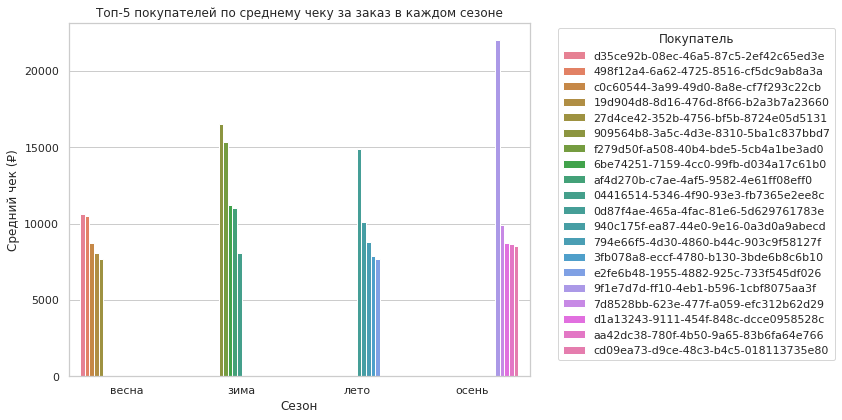

In [141]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_avg_check_by_season,
    x='season',
    y='avg_check',
    hue='customer_id',
    palette='husl'
)
plt.title('Топ-5 покупателей по среднему чеку за заказ в каждом сезоне')
plt.ylabel('Средний чек (₽)')
plt.xlabel('Сезон')
plt.legend(title='Покупатель', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<div style="border:solid green 2px; padding: 30px">
    
<b> ИТОГО:</b>

Анализируя популярность товаров, мы выявили:
    
1. Топ-15 товаров по количеству купленного товара:
    
Наиболее покупаемыми товарами оказались муляжи яблок(318 шт.), фурнитура для дверей, щетки и ерши, а также одежные крючки и плечики. Это в основном дешевые, массовые товары для дома и быта.

2. Топ-15 товаров по количеству заказов:
    
Лидируют растение пеларгония (разные сорта) (по примерно 60 заказов всего каждого сорта), а также тележки и багажные сумки. Эти товары встречаются реже, но с высокой частотой заказов по конкретным позициям.

3. Наиболее популярные категории товаров:

- Растения и цветы (51.6%) - категория-лидер по количеству покупок ;
    
- Дом и быт (20.7%)
    
- Остальные категории - значительно ниже (от 7.8% и ниже).

Покупатели активно интересуются зелеными товарами.

4. Наиболее прибыльные категории товаров:

- Дом и быт — (1.84 млн.) - лидер по выручке;
    
- Растения и цветы (590 тыс.)

- Хозяйственные товары и кухонные принадлежности тоже дают значительную выручку (412 тыс.).

Хотя растения лидируют по количеству продаж, наибольшую выручку приносят товары для дома — возможно, за счет более высокой цены или объема покупки.

5. Покупатели с самыми дорогими покупками по сезонам:    

- Самая дорогая покупка весной: 41.900 р.
    
- Самая дорогая покупка зимой : 16.536 р.
    
- Самая дорогая покупка летом : 20.232 р.
    
- Самая дорогая покупка осенью : 57.278 р.
    

6. Топ-покупатели по каждому сезону по среднему чеку:

- Самые высокие средние чеки наблюдаются зимой и летом :  до 16.536 р. за заказ.

- Весной и осенью также есть дорогие средние чеки, но менее выражено.

Зимние и летние заказы часто связаны с крупными приобретениями — например, подарками, отпускными покупками или закупкой впрок.

### 4. Анализ сезонности (цикличности):

*Посмотрим, как меняется поведение покупателей в зависимости от времени года.*

In [142]:
# Каждому уникальному времени года присвоим свой цвет из палитры mako:

unique_seasons = data['season'].unique()

palette_colors = sns.color_palette('mako_r', n_colors=len(unique_seasons))
season_color_map = dict(zip(unique_seasons, palette_colors))

#### 1. Продажи по сезонам:

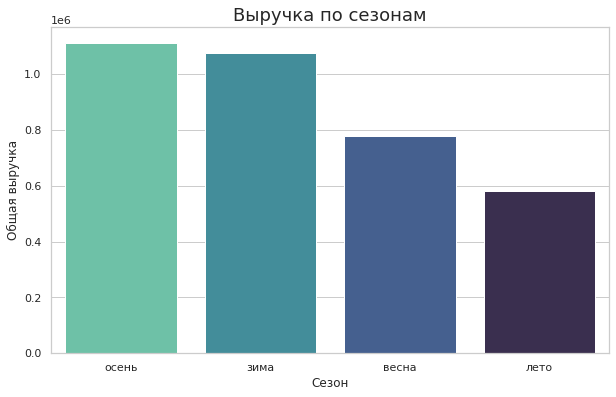

In [143]:
seasonal_sales = data.groupby('season')['total_price'].sum().sort_values(ascending=False)


# Преобразуем цвета в соответствии с отсортированным порядком сезонов:
sorted_colors = [season_color_map[season] for season in seasonal_sales.index]

# Визуализируем:
plt.figure(figsize=(10, 6))
sns.barplot(x=seasonal_sales.index, y=seasonal_sales.values, palette=sorted_colors)
plt.title('Выручка по сезонам', fontsize=18)
plt.xlabel('Сезон')
plt.ylabel('Общая выручка')
plt.show()

#### 2. Количество заказов по сезонам:

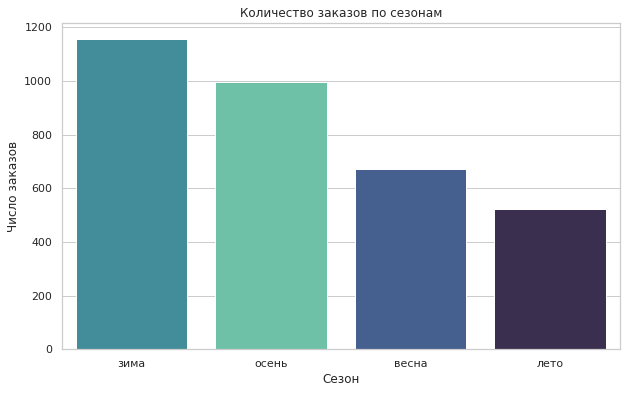

In [144]:
orders_per_season = data.groupby('season')['order_id'].nunique().sort_values(ascending=False)

sorted_colors_2 = [season_color_map[season] for season in orders_per_season.index]

plt.figure(figsize=(10, 6))
sns.barplot(x=orders_per_season.index, y=orders_per_season.values, palette=sorted_colors_2)
plt.title('Количество заказов по сезонам')
plt.xlabel('Сезон')
plt.ylabel('Число заказов')
plt.show()

#### 3. В какие сезоны какие категории товаров покупают чаще всего:

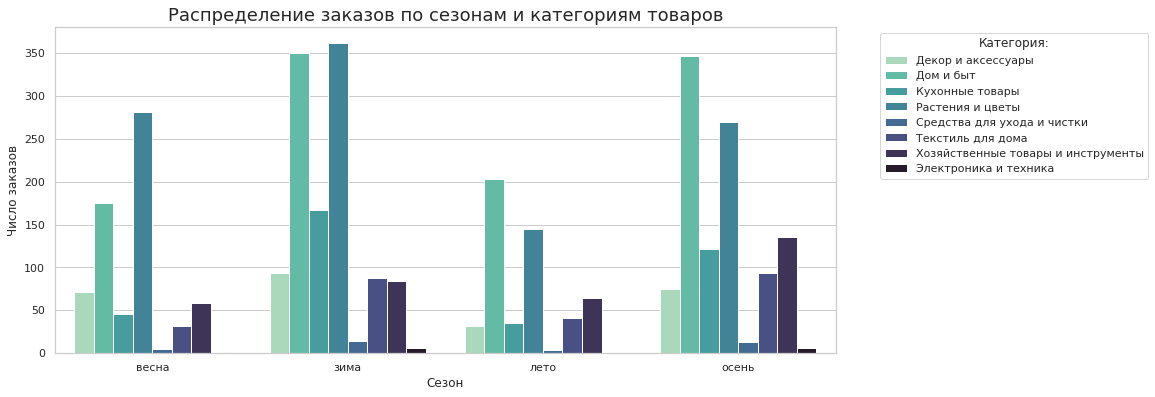

In [145]:
season_category_orders = data.groupby(['season', 'category'])['order_id'].nunique().reset_index()

plt.figure(figsize=(14, 6))
sns.barplot(data=season_category_orders, x='season', y='order_id', hue='category',palette=mako_palette)
plt.title('Распределение заказов по сезонам и категориям товаров', fontsize=18)
plt.xlabel('Сезон')
plt.ylabel('Число заказов')
plt.legend(title='Категория:', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

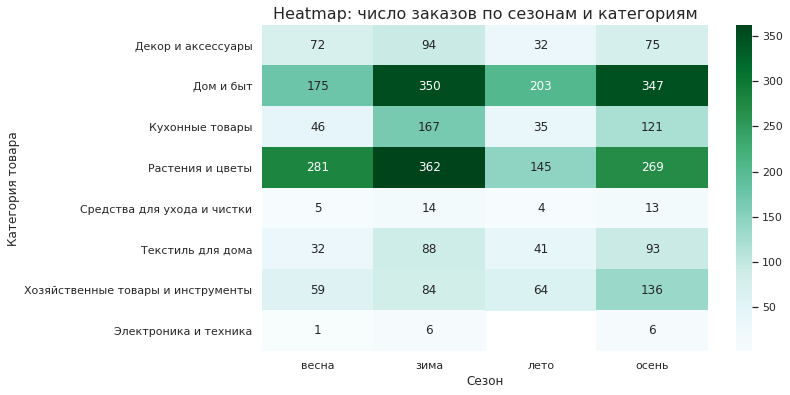

In [146]:
# Визуализируем через тепловую карту:

pivot_table = season_category_orders.pivot(index='category', columns='season', values='order_id')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cmap='BuGn', fmt='g')
plt.title('Heatmap: число заказов по сезонам и категориям', fontsize=16)
plt.xlabel('Сезон')
plt.ylabel('Категория товара')
plt.show()

<div style="border:solid green 2px; padding: 30px">
    
<b> ИТОГО:</b>

Проанализировав сезонность продаж, мы выявили, что:
    
- Выручка выше осенью, затем зимой, а вот летом продажи ниже всех.

- Зимой покупатели делают заказов больше, чем осенью. Однако летом по-прежнему меньше всего заказов делается.

- Касательно распределения заказов по сезонам и категориям товаров: весной и зимой лидируют покупки категории товаров “Растения и цветы”, а вот летом и осенью категорией товаров-лидером является “Дом и быт”. Весной и летом меньше всего покупалось товаров категории «Текстиль для дома». Пик покупок товаров категории «Электроника и техника» пришелся на лето и весну. Больше всего товаров категории “Дом и быт” покупалось зимой и осенью.

### 5. Анализ частоты покупок (Frequency):

#### 1. Распределение количества заказов на клиента:

In [147]:
order_counts = data.groupby('customer_id')['order_id'].nunique()
order_counts_sorted = order_counts.sort_values(ascending=False)

display(order_counts_sorted)

customer_id
4d93d3f6-8b24-403b-a74b-f5173e40d7db    35
73d1cd35-5e5f-4629-8cf2-3fda829d4e58    17
b7b865ab-0735-407f-8d0c-31f74d2806cc     7
0184f535-b60a-4914-a982-231e3f615206     5
bea7a833-2074-42db-bc49-4457abd3c930     4
498f12a4-6a62-4725-8516-cf5dc9ab8a3a     4
e0535076-6270-4df2-8621-cb06264a94fa     4
d16fbc13-50a6-4dea-aafc-bc197aafc9e4     3
dfbcfde5-21de-4504-aff4-453e617d81c1     3
f163e581-59ba-4022-99db-e0973c7497c0     3
7d0641a6-e043-487d-b356-38895fe7df84     3
0d1b15b6-9cf3-4642-8bc3-74c7dee7b40e     3
7d64b4ea-d03f-4c3a-b283-21b3d0d237f1     3
e8204583-4d55-4724-ad3f-049c7db43bdd     3
0adba506-249c-40b5-839d-a59d7a275cd7     3
639c4989-b0ab-412a-b7ec-be394cb2d372     3
41117d9d-94f7-4145-a8c9-cb6675ce7674     3
eb6521ae-56e3-4a72-9ea2-e9c69701ff3f     3
62952c5b-e5ef-4009-a2f9-1ebff401c514     3
ff422162-fc4a-4b65-a0e2-17f5095ea2c6     3
6b0c6cfb-7717-4c34-8535-bbc6e2b2c758     3
6a86cc77-ef15-496f-b5d3-89005597ee5d     3
552e17df-ba16-4e66-84fb-55a5557a6bea     3

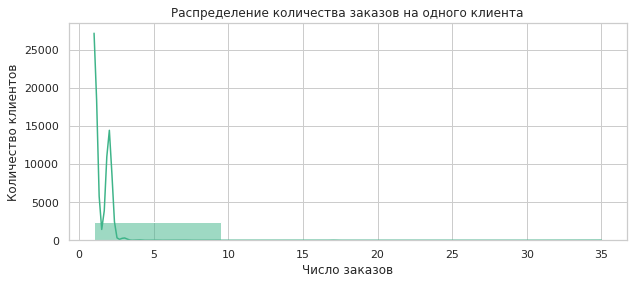

Среднее количество заказов на клиента: 1.39
Медианное количество заказов на клиента: 1.0
Максимальное количество заказов на клиента: 35


In [148]:
# Построим визуализацию:

plt.figure(figsize=(10, 4))
sns.histplot(order_counts, bins=4, kde=True, color='#3EB489')
plt.title('Распределение количества заказов на одного клиента')
plt.xlabel('Число заказов')
plt.ylabel('Количество клиентов')
plt.show()

print("Среднее количество заказов на клиента:", round(order_counts.mean(), 2))
print("Медианное количество заказов на клиента:", order_counts.median())
print("Максимальное количество заказов на клиента:", order_counts.max())

In [149]:
# Группируем по количеству заказов и считаем, сколько таких клиентов:
order_freq = order_counts.value_counts().sort_index()

# Переименуем Series для читаемости
order_freq.index.name = 'Число заказов' # подпись для левого столбца 
order_freq.name = 'Число клиентов' # имя самой Series, заголовок второго столбца  

# Посмотрим результат
display(order_freq.to_frame())

,Число клиентов
Число заказов,
1,1551
2,831
3,18
4,3
5,1
7,1
17,1
35,1


In [150]:
# Посчитаем доли:

total_customers = len(order_counts)

order_freq = order_freq.to_frame(name='Число клиентов')
order_freq['% клиентов'] = (order_freq['Число клиентов'] / total_customers * 100).round(2)

display(order_freq)

,Число клиентов,% клиентов
Число заказов,,
1,1551,64.44
2,831,34.52
3,18,0.75
4,3,0.12
5,1,0.04
7,1,0.04
17,1,0.04
35,1,0.04


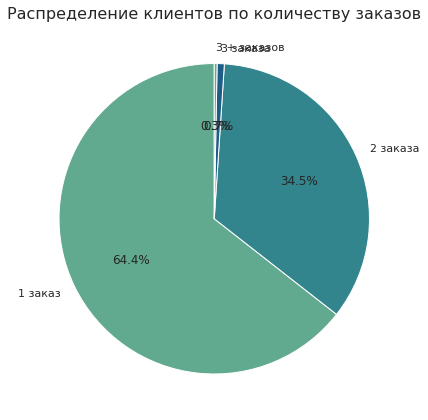

In [151]:
# Считаем количество заказов на клиента
orders_per_customer = data.groupby('customer_id')['order_id'].nunique().reset_index()
orders_per_customer.columns = ['customer_id', 'order_count']

# Сегментируем клиентов по числу заказов:
customer_segments = pd.cut(
    orders_per_customer['order_count'], 
    bins=[0, 1, 2, 3, float('inf')], 
    labels=['1 заказ', '2 заказа','3 заказа', '3 + заказов']
)

# Считаем долю клиентов в каждом сегменте:
segment_counts = customer_segments.value_counts().sort_index()

# Построим круговую диаграмму:
plt.figure(figsize=(8, 6))
segment_counts.plot(
    kind='pie', 
    autopct='%1.1f%%', 
    startangle=90,
    colors=sns.color_palette('crest', n_colors=3)
)

plt.title('Распределение клиентов по количеству заказов', fontsize=16)
plt.ylabel('')  
plt.tight_layout()
plt.show()

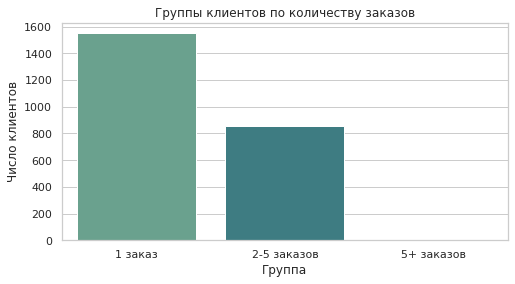

In [152]:
def order_group(x):
    if x == 1:
        return '1 заказ'
    elif x <= 5:
        return '2-5 заказов'
    else:
        return '5+ заказов'

order_counts_grouped = order_counts.apply(order_group).value_counts()

plt.figure(figsize=(8, 4))
sns.barplot(x=order_counts_grouped.index, y=order_counts_grouped.values, palette='crest')
plt.title('Группы клиентов по количеству заказов')
plt.ylabel('Число клиентов')
plt.xlabel('Группа')
plt.show()

*Получается, что:*

- 64% клиентов не возвращаются за покупками в интернет-магазин - они сделали всего 1 заказ за 1 год и 3 месяца. 

- только 35% клиентов делают повторный еще один заказ

- а меньше 1% (всего 18 клиентов) - сделали 3 заказа

- меньше 1% в сумме сделали по 4 и более заказов



#### 2. Посчитаем retention rate (доля клиентов с повторными покупками):**

In [153]:
total_customers = order_counts.count()
repeat_customers = order_counts[order_counts > 1].count()
retention_rate = round(repeat_customers / total_customers * 100, 2)

display(Markdown(f"<span style='color: green;'><strong>Retention rate (повторные покупки): </strong></span> <span><strong> {retention_rate}%</strong></span>"))

<span style='color: green;'><strong>Retention rate (повторные покупки): </strong></span> <span><strong> 35.56%</strong></span>

<div style="border:solid green 2px; padding: 30px">
    
<b> ИТОГО:</b>

касательно распределения количества заказов на клиента:

Есть клиенты, которые делали по 35, 17 заказов. Остальные покупатели делали меньше заказов.

Среднее количество заказов на клиента: 1.39

Медианное количество заказов на клиента: 1.0

35 заказов – делал один покупатель.

17, 7, 5 заказов – тоже делали всего по одному покупателю.

3 заказа сделали всего 18 человек, 2 заказа сделали 855 человек со всего датасета, а один заказ сделали 1565 человек – это 64% от всех покупателей магазина. 
Только 35% клиентов делают повторный еще один заказ, а меньше 1% (всего 18 клиентов) - сделали 3 заказа, меньше 1% в сумме сделали по 4 и более заказов. 
    
Самые крупные покупки сделали клиенты магазина, которые совершали 2 и более покупок в магазине. Хотя есть некоторые исключения: есть пара клиентов, которые сделали крупные дорогие покупки за 1 раз посещения интернет-магазина.

Retention rate (повторные покупки): 35.56%

Если доля клиентов с повторными заказами равна 35%, то может быть вполне полезно провести RFM-анализ.

Посмотрим на клиентов, сделавших **2 заказа** и отсортируем их по убыванию общей стоимости заказов:

In [154]:
customers_with_2_orders = order_counts[order_counts == 2].index

data_2_orders = data[data['customer_id'].isin(customers_with_2_orders)]

# Группируем по клиенту и считаем среднюю стоимость заказа:
order_value = data_2_orders.groupby('customer_id')['total_price'].sum()

order_value_sorted = order_value.sort_values(ascending=False)

display(order_value_sorted)

customer_id
940c175f-ea87-44e0-9e16-0a3d0a9abecd   20,232.00
f279d50f-a508-40b4-bde5-5cb4a1be3ad0   16,557.00
ad66d870-22f5-43bc-958f-73420822586b   13,731.00
86c97bf1-c834-423e-9e38-8acda68f97e8   11,548.00
02adb72a-3067-45e9-a3b5-f93d79d7496a   10,723.00
b7dffbd3-810c-4125-889a-454ee093eb73   10,168.00
88b127c0-5753-4e21-b9eb-fb2b1537827a    9,482.00
126dac4d-6486-49ed-a1be-9fd55a38a9de    9,148.00
ac250053-a236-467a-97d2-ddbb9bf4a1ba    8,684.00
b16a52b7-499b-4be8-9220-19076ed22bc9    8,307.00
9704352f-7f7f-4fa7-aa1c-64296156a722    8,249.00
db6caedb-e231-4adc-bcd0-e45b8992f3da    8,203.00
19d904d8-8d16-476d-8f66-b2a3b7a23660    8,167.00
04416514-5346-4f90-93e3-fb7365e2ee8c    8,107.00
1f502315-d58f-401c-8ba2-88b16e53d0b3    7,993.00
85716494-dd51-4d1d-ab28-8c74b87f14dc    7,902.00
005ba170-45e8-42de-93f7-192481ae2659    7,857.00
5853eef2-4e02-4597-a69c-b4e274dce7ae    7,798.00
27d4ce42-352b-4756-bf5b-8724e05d5131    7,739.00
16838b36-762a-474d-bda4-bad95f8d7813    7,649.00
8a96eab5

Сортируем клентов по общей стоимости заказов:

In [155]:
# Группируем по клиенту, считаем сумму заказов и количество заказов
customer_stats = data.groupby('customer_id').agg(
    total_spent=('total_price', 'sum'),
    orders_count=('order_id', 'nunique') # или count()
)

display(customer_stats.sort_values(by='total_spent', ascending=False))

In [156]:
# Фильтруем отсюда клиентов с числом заказов > 2:
main_customers = customer_stats[customer_stats['orders_count'] >= 2]

display(main_customers.sort_values(by='orders_count', ascending=False))

Мы видим, что самые крупные покупки сделали клиенты магазина, которые совершали 2 и более покупок в магазине. 

Хотя есть некоторые исключения: есть пара клиентов, которые сделали крупные дорогие покупки за 1 раз посещения интернет-магазина.

**Выведем только тех клиентов магазина, которые совершили 1 заказ, но больше 12000 руб.:**

In [157]:
order_counts = data.groupby('customer_id')['order_id'].nunique()

# Фильтруем клиентов с ровно одним заказом:
one_order_customers = order_counts[order_counts == 1].index

# Отбираем только строки этих клиентов:
one_order_data = data[data['customer_id'].isin(one_order_customers)]

# Оставляем только тех, у кого сумма заказа > 12000:
filtered_data = one_order_data[one_order_data['total_price'] > 12000]

display(filtered_data.sort_values(by='total_price', ascending=False))

,date,month,customer_id,order_id,product,category,quantity,price,total_price,season,price_group,day_of_week,year_month
1675,2019-02-04 06:00:00,2,909564b8-3a5c-4d3e-8310-5ba1c837bbd7,70080,мусорный контейнер hаilо bigbin swing 45 0845-...,Кухонные товары,3,"5,512.00","16,536.00",зима,более 10.000 руб.,0,2019-02
5992,2019-07-29 17:00:00,7,0d87f4ae-465a-4fac-81e6-5d629761783e,72139,сушилка уличная lеifhеiт 85210 linоmатiс v 400...,Дом и быт,1,"14,917.00","14,917.00",лето,более 10.000 руб.,0,2019-07


#### 2. Рассчитаем разницу между заказами каждого клиента:

In [158]:
order_counts = data.groupby('customer_id')['order_id'].nunique()

repeat_buyers = order_counts[order_counts > 1].index

# Фильтруем данные только тех клиентов, которые совершили 2 и более покупок:
repeat_data = data[data['customer_id'].isin(repeat_buyers)]

repeat_data_sorted = repeat_data.sort_values(['customer_id', 'date'])

Для каждого клиента создаём колонку prev_date, которая содержит дату предыдущего заказа.
shift(1) сдвигает даты на одну строку вниз.
В результате:первый заказ клиента будет иметь NaT (нет предыдущего), второй и далее — получат дату предыдущего заказа.

In [159]:
repeat_data_sorted['prev_date'] = repeat_data_sorted.groupby('customer_id')['date'].shift(1)
display(repeat_data_sorted.head())

,date,month,customer_id,order_id,product,category,quantity,price,total_price,season,price_group,day_of_week,year_month,prev_date
537,2018-10-30 20:00:00,10,005ba170-45e8-42de-93f7-192481ae2659,68803,штора для ванной комнаты quаdrетто 240х200 см ...,Дом и быт,1,"1,199.00","1,199.00",осень,до 2.000 руб.,1,2018-10,NaT
6781,2019-11-05 21:00:00,11,005ba170-45e8-42de-93f7-192481ae2659,105120,сумка-тележка хозяйственная rоlsеrjет с. сарri...,Дом и быт,2,"3,329.00","6,658.00",осень,от 5.000 до 10.000 руб.,1,2019-11,2018-10-30 20:00:00
1968,2019-02-23 16:00:00,2,00c0f92a-121a-4883-a78d-2c7b5fe187de,70418,пеларгония розебудная mаrу укорененный черенок,Растения и цветы,1,134.00,134.00,зима,до 2.000 руб.,5,2019-02,NaT
7037,2019-12-12 12:00:00,12,00c0f92a-121a-4883-a78d-2c7b5fe187de,110734,роза садовая чайногибридная в горшке императрица,Растения и цветы,1,187.00,187.00,зима,до 2.000 руб.,3,2019-12,2019-02-23 16:00:00
1930,2019-02-21 08:00:00,2,00cd704a-a65c-4865-b39a-779f1b4f1d1a,70379,пеларгония тоsсаnа аngеlеуеs biсоlоr укорененн...,Растения и цветы,1,112.00,112.00,зима,до 2.000 руб.,3,2019-02,NaT


In [160]:
# Считаем разницу в днях между заказами:
repeat_data_sorted['days_between_orders'] = (repeat_data_sorted['date'] - repeat_data_sorted['prev_date']).dt.days
display(repeat_data_sorted.head())

,date,month,customer_id,order_id,product,category,quantity,price,total_price,season,price_group,day_of_week,year_month,prev_date,days_between_orders
537,2018-10-30 20:00:00,10,005ba170-45e8-42de-93f7-192481ae2659,68803,штора для ванной комнаты quаdrетто 240х200 см ...,Дом и быт,1,"1,199.00","1,199.00",осень,до 2.000 руб.,1,2018-10,NaT,NaN
6781,2019-11-05 21:00:00,11,005ba170-45e8-42de-93f7-192481ae2659,105120,сумка-тележка хозяйственная rоlsеrjет с. сарri...,Дом и быт,2,"3,329.00","6,658.00",осень,от 5.000 до 10.000 руб.,1,2019-11,2018-10-30 20:00:00,371.00
1968,2019-02-23 16:00:00,2,00c0f92a-121a-4883-a78d-2c7b5fe187de,70418,пеларгония розебудная mаrу укорененный черенок,Растения и цветы,1,134.00,134.00,зима,до 2.000 руб.,5,2019-02,NaT,NaN
7037,2019-12-12 12:00:00,12,00c0f92a-121a-4883-a78d-2c7b5fe187de,110734,роза садовая чайногибридная в горшке императрица,Растения и цветы,1,187.00,187.00,зима,до 2.000 руб.,3,2019-12,2019-02-23 16:00:00,291.00
1930,2019-02-21 08:00:00,2,00cd704a-a65c-4865-b39a-779f1b4f1d1a,70379,пеларгония тоsсаnа аngеlеуеs biсоlоr укорененн...,Растения и цветы,1,112.00,112.00,зима,до 2.000 руб.,3,2019-02,NaT,NaN


Визуализируем распределение интервалов между покупками клиентов:

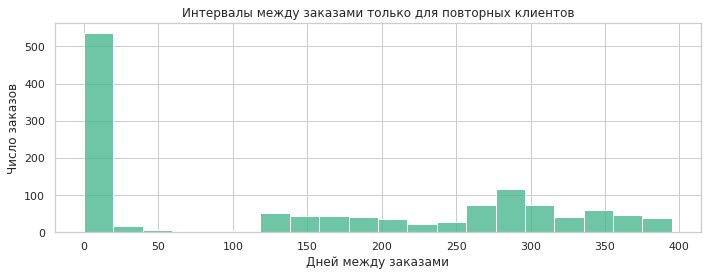

In [161]:
plt.figure(figsize=(10, 4))
sns.histplot(repeat_data_sorted['days_between_orders'].dropna(), bins=20, color='#3EB489')
plt.title('Интервалы между заказами только для повторных клиентов')
plt.xlabel('Дней между заказами')
plt.ylabel('Число заказов')
plt.tight_layout()
plt.show()

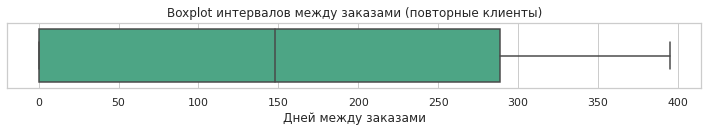

In [162]:
plt.figure(figsize=(10, 2))
sns.boxplot(x=repeat_data_sorted['days_between_orders'].dropna(), color='#3EB489')
plt.title('Boxplot интервалов между заказами (повторные клиенты)')
plt.xlabel('Дней между заказами')
plt.tight_layout()
plt.show()

In [163]:
intervals_by_customer = (
    repeat_data_sorted
    .dropna(subset=['days_between_orders'])  # удалим первую покупку каждого клиента
    .groupby('customer_id')['days_between_orders']
    .mean()
    .reset_index()
    .rename(columns={'days_between_orders': 'avg_days_between_orders'})
)

display(intervals_by_customer.sort_values(by='avg_days_between_orders', ascending=False))

In [164]:
# Удалим пустые значения (NaN)
repeat_data_sorted_no_nan = repeat_data_sorted['days_between_orders'].dropna()

In [165]:
interval_counts = repeat_data_sorted_no_nan.value_counts().sort_index(ascending=False)

display(interval_counts)

395.00      3
394.00      1
393.00      2
392.00      1
391.00      1
390.00      5
389.00      1
388.00      1
387.00      1
386.00      4
385.00      1
384.00      2
383.00      1
381.00      1
379.00      2
378.00      2
377.00      5
376.00      4
375.00      2
373.00      2
372.00      1
371.00      2
370.00      3
369.00      1
367.00      4
366.00      2
365.00      8
364.00      1
363.00      3
361.00      6
360.00      5
359.00      2
358.00      2
357.00      2
356.00      1
354.00      2
353.00      1
352.00      1
351.00      1
349.00      1
348.00      1
347.00      1
344.00      1
343.00      4
342.00     10
341.00      6
340.00      5
339.00      9
338.00      1
337.00     10
336.00      5
335.00      1
334.00      2
333.00     10
332.00      2
331.00      9
330.00      4
326.00      1
325.00      1
322.00      2
321.00      1
319.00      3
318.00      2
317.00      2
316.00      1
314.00      4
313.00      2
311.00      1
310.00      5
309.00      3
308.00      2
305.00

Сгруппируем интервалы по диапазонам и посчитаем, сколько их в каждой группе:

In [166]:
# Создаем группы по диапазонам:
bins = [0, 14, 30, 180, 365, float('inf')]
labels = ['0-14 дней', '15-30 дней', '31-180 дней', '181-365 дней', 'Более 365 дней']

# Применяем группировку:
interval_groups = pd.cut(repeat_data_sorted_no_nan, bins=bins, labels=labels, right=True, include_lowest=True)

# Считаем количество интервалов в каждой группе
group_counts = interval_groups.value_counts().sort_index()

# Выводим результат
display(group_counts)

0-14 дней         530
15-30 дней         19
31-180 дней       166
181-365 дней      517
Более 365 дней     55
Name: days_between_orders, dtype: int64

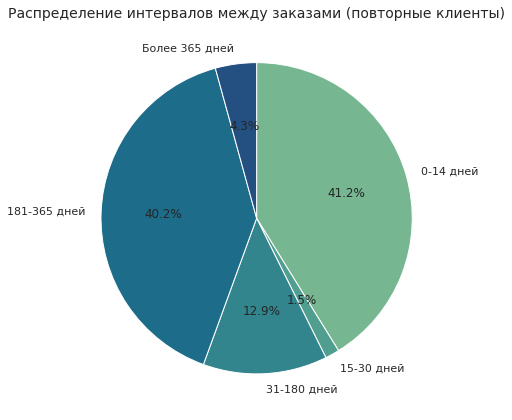

In [167]:
# Визуализируем:

plt.figure(figsize=(8, 6))
group_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'},
    colors=sns.color_palette('crest', n_colors=len(group_counts))
)

plt.title('Распределение интервалов между заказами (повторные клиенты)', fontsize=14)
plt.ylabel('')  # Убираем подпись оси Y
plt.tight_layout()
plt.show()

Отсортируем по убыванию долей и добавим легенду:

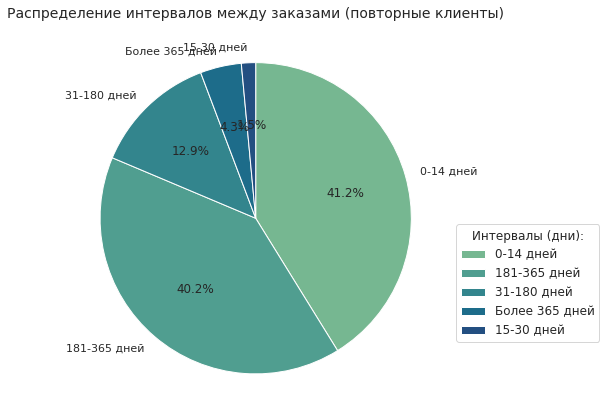

In [168]:
group_counts_sorted = group_counts.sort_values(ascending=False)


plt.figure(figsize=(8, 6))
group_counts_sorted.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,  # Начинаем сверху
    counterclock=False,  # Направление по часовой стрелке
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'},
    colors=sns.color_palette('crest', n_colors=len(group_counts_sorted))
)

plt.legend(
    group_counts_sorted.index,  # Подписи для легенды
    title='Интервалы (дни):', 
    loc='upper left',  # Размещение легенды
    bbox_to_anchor=(1, 0.5),  # справа от графика
    fontsize=12
)


plt.title('Распределение интервалов между заказами (повторные клиенты)', fontsize=14)
plt.ylabel('')  
plt.tight_layout()


plt.show()

<div style="border:solid green 2px; padding: 30px">
    
<b> ИТОГО:</b>

Рассмотрев интервалы между повторными покупками, мы заметили следующее:
    
- 55 человек делали повторную покупку спустя год;
    
- 517 человека делали повторную покупку полгода спустя;
    
- 166 человек делали повторный заказ в магазине спустя от 1 до 6 месяцев;
    
- 19 человек повторяли свой заказ спустя 2 недели-месяц;
    
- 530 человек повторяли покупки спустя день или неделю.

<div style="border:solid  green 6px; padding: 30px">
    
<b> ВЫВОД:</b>
    
Проведя исследовательский анализ, мы выявили следующее:
    

<b> 1. Частота покупок:</b>
    
1) Частота заказов на одного клиента:
    
Среднее количество заказов на клиента: 1.44
    
Медианное количество заказов на клиента: 1.0
Максимальное количество заказов на клиента: 126
    
Данные слишком скошены вправо. Есть клиенты со слишком большим количеством заказов и их мало.
    
Мы видим по графику эти значения с 126, 35, 17, 7 заказами.
    
Анализируя количество покупок на одного клиента, мы обнаружили одного клиента, который сделал больше всех заказов (126 заказов), с большим отрывом по количеству заказов от остальных покупателей (на втором месте по числу заказов стоит клиент, сделавший 35 покупок).
    
Стоит удалить из датасета клиента, который сделал 126 заказов с долей трат, которая является 3 по доле трат по общей сумме всех закаов в датасете за рассматриваемый в датасете период.

2) Распределение заказов по месяцам и дням (поиск пиков):
    
Добавили ещё вспомогательные столбцы: day_of_week и year_month.
    
Построив графики распределения количества заказов по месяцам, сезонам и дням недели, мы заметили, что:
    
- больше всего заказов делаются зимой, потом весной, меньше всего летом.
    
- наибольшее число покупок было сделано в декабре 2018, феврале 2019, марте-апреле 2019 и декабре 2019 и январе 2020. Максимальное количество покупок сделано было в январе 2020. 
    
- Кастельно дней недели: наибольшее количество заказов приходится на вторник, затем понедельник. В целом , кажется, что в будние дни покупательская активность более сильная. Однако в выходные: в воскресенье люди чаще покупают, нежели чем в субботу.


<b> 3. Популярность товаров:</b>

Анализируя популярность товаров, мы выявили:

Топ-15 товаров по количеству купленного товара:
    
Наиболее покупаемыми товарами оказались муляжи яблок(318 шт.), фурнитура для дверей, щетки и ерши, а также одежные крючки и плечики. Это в основном дешевые, массовые товары для дома и быта.

Топ-15 товаров по количеству заказов:
    
Лидируют растение пеларгония (разные сорта) (по примерно 60 заказов всего каждого сорта), а также тележки и багажные сумки. Эти товары встречаются реже, но с высокой частотой заказов по конкретным позициям.

Наиболее популярные категории товаров:
Растения и цветы (51.6%) - категория-лидер по количеству покупок ;

Дом и быт (20.7%)

Остальные категории - значительно ниже (от 7.8% и ниже).

Покупатели активно интересуются зелеными товарами.

Наиболее прибыльные категории товаров:
Дом и быт — (1.84 млн.) - лидер по выручке;

Растения и цветы (590 тыс.)

Хозяйственные товары и кухонные принадлежности тоже дают значительную выручку (412 тыс.).

Хотя растения лидируют по количеству продаж, наибольшую выручку приносят товары для дома — возможно, за счет более высокой цены или объема покупки.

Покупатели с самыми дорогими покупками по сезонам:
Самая дорогая покупка весной: 41.900 р.

Самая дорогая покупка зимой : 16.536 р.

Самая дорогая покупка летом : 20.232 р.

Самая дорогая покупка осенью : 57.278 р.

Топ-покупатели по каждому сезону по среднему чеку:
Самые высокие средние чеки наблюдаются зимой и летом : до 16.536 р. за заказ.

Весной и осенью также есть дорогие средние чеки, но менее выражено.

Зимние и летние заказы часто связаны с крупными приобретениями — например, подарками, отпускными покупками или закупкой впрок.



<b>4. Анализ сезонности (цикличности):</b>

Проанализировав сезонность продаж, мы выявили, что:
    
- Выручка выше осенью, затем зимой, а вот летом продажи ниже всех.

- Зимой покупатели делают заказов больше, чем осенью. Однако летом по-прежнему меньше всего заказов делается.

- Касательно распределения заказов по сезонам и категориям товаров: весной и зимой лидируют покупки категории товаров “Растения и цветы”, а вот летом и осенью категорией товаров-лидером является “Дом и быт”. Весной и летом меньше всего покупалось товаров категории «Текстиль для дома». Пик покупок товаров категории «Электроника и техника» пришелся на лето и весну. Больше всего товаров категории “Дом и быт” покупалось зимой и осенью.



<b>5. Анализ частоты покупок (Frequency):</b>

1) Распределение количества заказов на клиента:

касательно распределения количества заказов на клиента:

Есть клиенты, которые делали по 35, 17 заказов. Остальные покупатели делали меньше заказов.

Среднее количество заказов на клиента: 1.39

Медианное количество заказов на клиента: 1.0

35 заказов – делал один покупатель.

17, 7, 5 заказов – тоже делали всего по одному покупателю.

3 заказа сделали всего 18 человек, 2 заказа сделали 855 человек со всего датасета, а один заказ сделали 1565 человек – это 64% от всех покупателей магазина. 
Только 35% клиентов делают повторный еще один заказ, а меньше 1% (всего 18 клиентов) - сделали 3 заказа, меньше 1% в сумме сделали по 4 и более заказов. 
    
Самые крупные покупки сделали клиенты магазина, которые совершали 2 и более покупок в магазине. Хотя есть некоторые исключения: есть пара клиентов, которые сделали крупные дорогие покупки за 1 раз посещения интернет-магазина.

Retention rate (повторные покупки): 35.99%

Если доля клиентов с повторными заказами равна 35%, то может быть вполне полезно провести RFM-анализ

2)  Рассчитаем разницу между заказами каждого клиента:

Рассмотрев интервалы между повторными покупками, мы заметили следующее:
    
- 55 человек делали повторную покупку спустя год;
    
- 517 человека делали повторную покупку полгода спустя;
    
- 166 человек делали повторный заказ в магазине спустя от 1 до 6 месяцев;
    
- 19 человек повторяли свой заказ спустя 2 недели-месяц;
    
- 530 человек повторяли покупки спустя день или неделю.

## Шаг 4. (1) Сегментация покупателей

### 1. Проведем RFM-анализ:


#### 1. Подготовим признаки для сегментации пользователей:

Определим 3 метрики, необходимые для анализа:

- Recency (давность) - сколько дней прошло с последней покупки;

- Frequency (частота) - сколько заказов совершил клиент;

- Monetary (выручка) - сколько денег клиент потратил.

In [169]:
# data['customer_id'].nunique()

In [170]:
# Последняя дата в датасете:

last_date = data['date'].max()

In [171]:
# Группировка по клиенту:

rfm = data.groupby('customer_id').agg({
    'date': lambda x: (last_date - x.max()).days,  # Recency - как давно клиент ничего не покупал
    'order_id': 'nunique',                         # Frequency - сколько делал заказов всего
    'total_price': 'sum'                           # Monetary - сколько потратил всего за все покупки
}).reset_index()

rfm.columns = ['customer_id', 'recency', 'frequency', 'monetary']
display(rfm)

print('***' * 15)

print(len(rfm))

*********************************************
2407


#### 2. Присвоим RFM-оценки (1–5):

In [172]:
# Чем меньше recency — тем выше оценка:
rfm['r_score'] = pd.qcut(rfm['recency'], 5, labels=[5, 4, 3, 2, 1]).astype(int)

# Чем больше frequency и monetary — тем выше оценка:
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['m_score'] = pd.qcut(rfm['monetary'], 5, labels=[1, 2, 3, 4, 5]).astype(int)

# Сформируем RFM сегмент:
rfm['RFM_segment'] = rfm['r_score'].astype(str) + rfm['f_score'].astype(str) + rfm['m_score'].astype(str)

In [173]:
display(rfm)

In [174]:
def segment_rfm(row):
    r, f, m = row['r_score'], row['f_score'], row['m_score']
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Лучшие клиенты'
    elif r >= 4 and f >= 3 and m >= 3:
        return 'Лояльные клиенты'
    elif r >= 4 and f <= 2:
        return 'Новички'
    elif r == 3 and f >= 3 and m >= 3:
        return 'Потенциальные лояльные'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'Уходящие ценные'
    elif r <= 2 and f <= 2 and m >= 4:
        return 'Рисковые, но прибыльные'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Низкоценные'
    else:
        return 'Прочие'

rfm['segment'] = rfm.apply(segment_rfm, axis=1)

rfm.head()

,customer_id,recency,frequency,monetary,r_score,f_score,m_score,RFM_segment,segment
0,000d6849-084e-4d9f-ac03-37174eaf60c4,107,1,555.00,4,1,2,412,Новички
1,001cee7f-0b29-4716-b202-0042213ab038,349,1,442.00,2,1,2,212,Низкоценные
2,00299f34-5385-4d13-9aea-c80b81658e1b,108,1,914.00,4,1,3,413,Новички
3,002d4d3a-4a59-406b-86ec-c3314357e498,368,1,"1,649.00",2,1,4,214,"Рисковые, но прибыльные"
4,003bbd39-0000-41ff-b7f9-2ddaec152037,123,1,"2,324.00",4,1,5,415,Новички


In [175]:
rfm_segment_summary = (
    rfm
    .groupby('segment')[['recency', 'frequency', 'monetary']]
    .mean()
    .round(2)
    .sort_values('monetary', ascending=False)
)

display(rfm_segment_summary)

,recency,frequency,monetary
segment,,,
Уходящие ценные,371.05,2.45,"4,963.96"
Лучшие клиенты,46.40,2.04,"2,913.43"
"Рисковые, но прибыльные",383.03,1.00,"2,677.20"
Потенциальные лояльные,213.13,1.45,"2,271.97"
Новички,109.76,1.00,"1,090.01"
Лояльные клиенты,55.72,1.84,"1,064.79"
Прочие,244.74,1.24,881.74
Низкоценные,366.93,1.00,312.75


In [176]:
segment_counts = rfm['segment'].value_counts()
print(segment_counts)

Прочие                     1098
Лучшие клиенты              375
Низкоценные                 232
Рисковые, но прибыльные     193
Лояльные клиенты            186
Новички                     153
Потенциальные лояльные      115
Уходящие ценные              55
Name: segment, dtype: int64


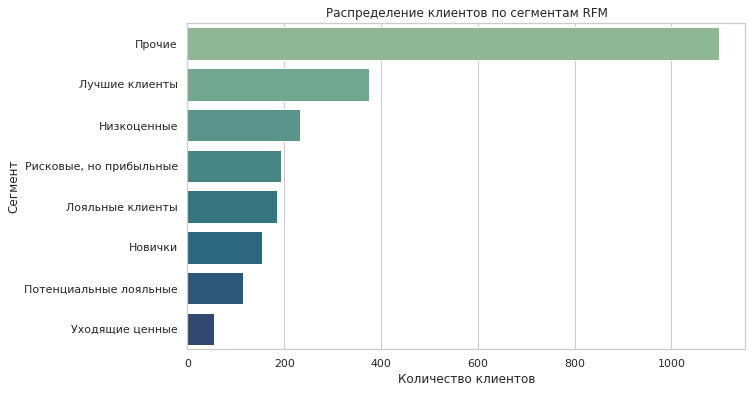

In [177]:
plt.figure(figsize=(10, 6))
sns.countplot(y='segment', data=rfm, order=segment_counts.index, palette='crest')
plt.title('Распределение клиентов по сегментам RFM')
plt.xlabel('Количество клиентов')
plt.ylabel('Сегмент')
plt.show()

<div style="border:solid green 2px; padding: 30px">
    
<b> ИТОГО:</b>

Проделав RFM-анализ, мы выявили основные категории клиентов:
    
1) Неопределённые клиенты ("Прочие"): 1098 человек.
    
Это самый многочисленный сегмент. Такие клиенты не проявляют ярко выраженного поведения.
    
Средняя общая выручка покупателей данного сегмента: 882 р.
    
2) "Лучшие клиенты": 375 чел. 
    
Это самые ценные покупатели: они покупают часто, тратят много и недавно были активны. Их важно удерживать. Например, предлагать им бонусы, VIP-обслуживание или даже персонализировать предложения.
    
Средняя общая выручка покупателей данного сегмента: 2.920 р.
    
3) "Низкоценные" клиенты: 232 чел. 
    
Эти клиенты мало тратят, редко покупают и давно не проявляли активности. Возможно, они случайные или разовые покупатели.
    
Средняя общая выручка покупателей данного сегмента: 312.75 р.

    
4) "Рисковые, но прибыльные": 193 чел. 
    
Это ранее ценные клиенты, но в последнее время они не очень активны. Можно попробовать вернуть их через эксклюзивные предложения или напоминания.
    
Средняя общая выручка покупателей данного сегмента: 2.700 р.
    
5) "Лояльные клиенты" : 186 чел.
    
Регулярно покупают и приносят доход. Это важная группа, её нужно удерживать, например, через программы лояльности.
    
Средняя общая выручка покупателей данного сегмента: 1060 р.
    
6) "Новички" : 153 чел. 
    
Недавно пришли. Их нужно стимулировать совершать повторные покупки.
    
Средняя общая выручка покупателей данного сегмента: 1.100 р.
    
7) "Потенциальные лояльные" : 115 чел. 
    
Эти клиенты близки к лояльным. Это хорошая целевая аудитория для продвижения.
    
Средняя общая выручка покупателей данного сегмента: 2.300 р.
    
8) "Уходящие ценные" : 55 чел. 
    
Клиенты, которые раньше были активны и прибыльны, но сейчас теряются.
    
Средняя общая выручка покупателей данного сегмента: почти 5000 р.


### 2. Связь сегментов с категориями и сезонностью:

**Связь с категориями:**

In [178]:
# Считаем количество покупок по категориям и клиентам:
rfm_category_counts = data.groupby(['customer_id', 'category']).size().reset_index(name='count')

# Добавляем информацию о сегменте клиента из RFM-таблицы:
rfm_category_counts['segment'] = rfm_category_counts['customer_id'].map(rfm.set_index('customer_id')['segment'])

# Группируем по сегменту и категории, считаем общее число покупок:
rfm_category_counts_by_segment = (
    rfm_category_counts
    .groupby(['segment', 'category'])['count']
    .sum()
    .reset_index()
    .sort_values(['segment', 'count'], ascending=[True, False])
)
rfm_category_counts_by_segment

,segment,category,count
3,Лояльные клиенты,Растения и цветы,116
1,Лояльные клиенты,Дом и быт,110
6,Лояльные клиенты,Хозяйственные товары и инструменты,36
2,Лояльные клиенты,Кухонные товары,35
5,Лояльные клиенты,Текстиль для дома,28
0,Лояльные клиенты,Декор и аксессуары,17
4,Лояльные клиенты,Средства для ухода и чистки,4
7,Лояльные клиенты,Электроника и техника,2
9,Лучшие клиенты,Дом и быт,364
11,Лучшие клиенты,Растения и цветы,167


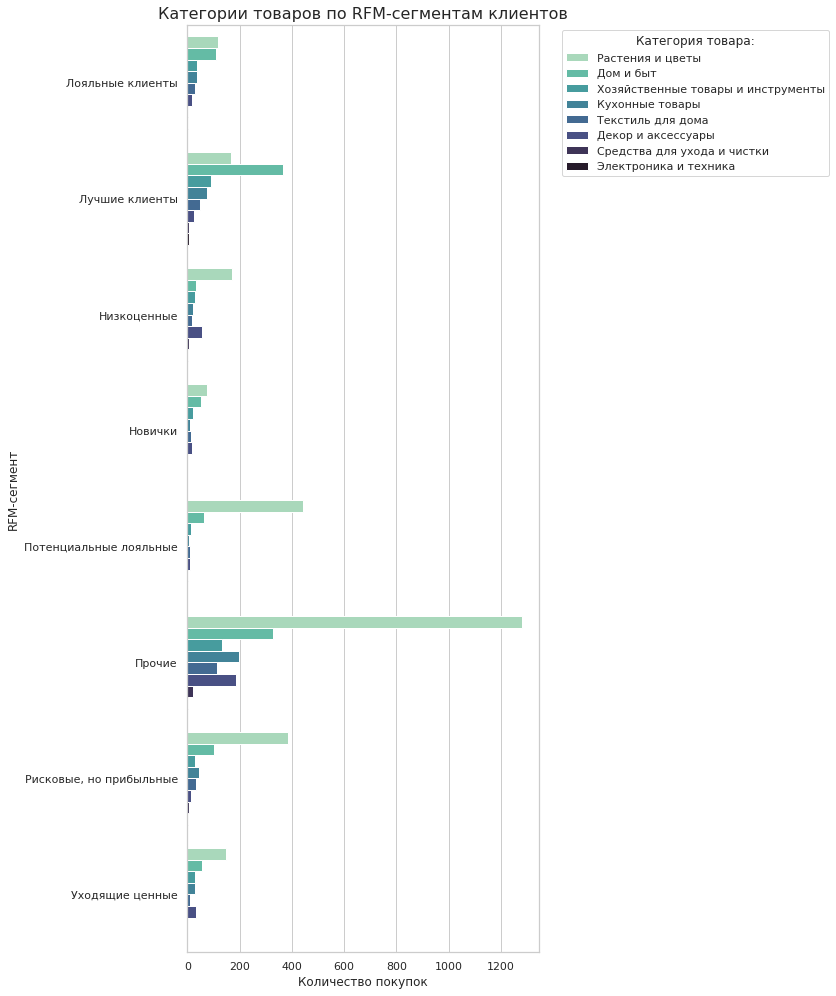

In [179]:
# Визуализируем:

plt.figure(figsize=(12, 14))
sns.barplot(
    data=rfm_category_counts_by_segment,
    y='segment',   
    x='count',     
    hue='category',
    palette='mako_r',
    orient='h'     # горизонтальная ориентация
)

plt.title('Категории товаров по RFM-сегментам клиентов', fontsize=16)
plt.xlabel('Количество покупок')
plt.ylabel('RFM-сегмент')
plt.legend(title='Категория товара:', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Связь с сезонами:**

In [180]:
rfm_season_counts = data.groupby(['customer_id', 'season']).size().reset_index(name='count')

rfm_season_counts['segment'] = rfm_season_counts['customer_id'].map(rfm.set_index('customer_id')['segment'])

# Группируем по сегменту и категории, считаем общее число покупок:
rfm_season_counts_by_segment = (
    rfm_season_counts
    .groupby(['segment', 'season'])['count']
    .sum()
    .reset_index()
    .sort_values(['segment', 'count'], ascending=[True, False])
)

rfm_season_counts_by_segment

,segment,season,count
1,Лояльные клиенты,зима,156
3,Лояльные клиенты,осень,124
0,Лояльные клиенты,весна,35
2,Лояльные клиенты,лето,33
5,Лучшие клиенты,зима,358
7,Лучшие клиенты,осень,239
4,Лучшие клиенты,весна,94
6,Лучшие клиенты,лето,88
8,Низкоценные,весна,139
9,Низкоценные,зима,104


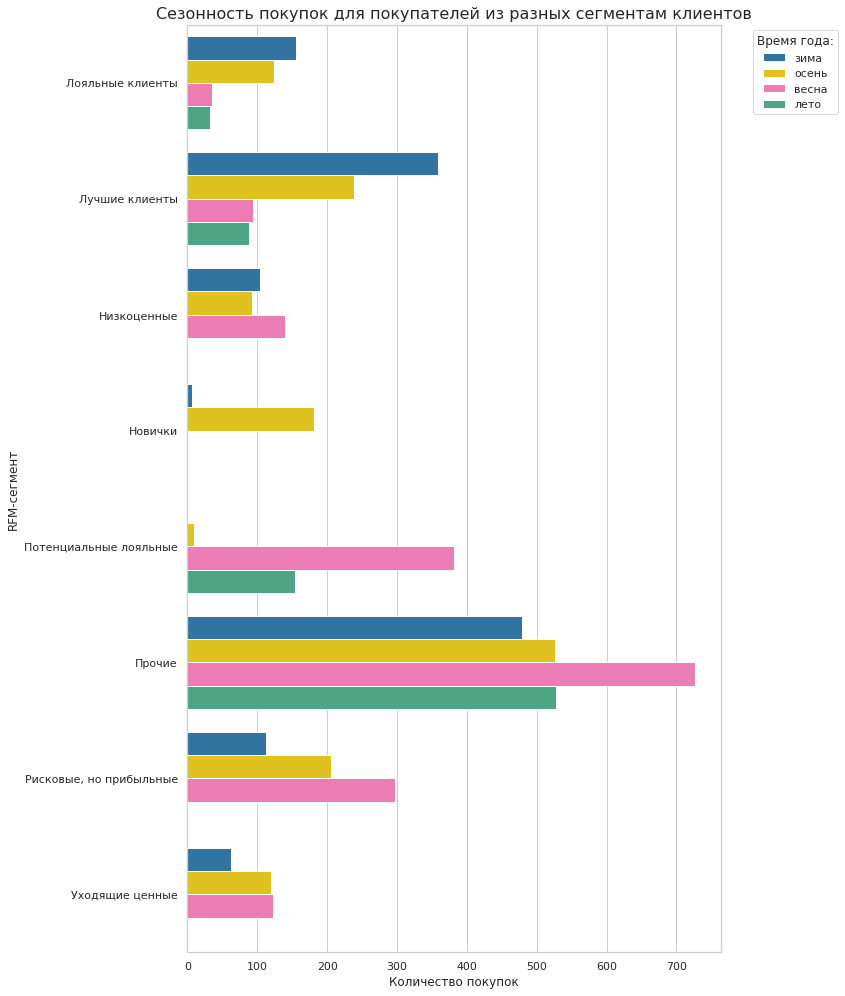

In [181]:
# Визуализируем:

season_palette = {
    'лето': '#3EB489',       
    'зима': '#1f77b4',       
    'весна': '#ff69b4',      
    'осень': '#FFD700'
}


plt.figure(figsize=(12, 14))
sns.barplot(
    data=rfm_season_counts_by_segment,
    y='segment',   
    x='count',     
    hue='season',
    palette=season_palette,
    orient='h'     # горизонтальная ориентация
)

plt.title('Сезонность покупок для покупателей из разных сегментам клиентов', fontsize=16)
plt.xlabel('Количество покупок')
plt.ylabel('RFM-сегмент')
plt.legend(title='Время года:', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Сезонность категорий товара по каждому из получившихся сегментов покупателей:**

Для этого стоит объединить основной датафрейм data с сегментами из rfm:

In [182]:
data_with_segments = data.merge(rfm[['customer_id', 'segment']], on='customer_id', how='left')

seasonal_category_counts_by_rfm_segments = (
    data_with_segments
    .groupby(['segment', 'season', 'category'])
    .size()
    .reset_index(name='count')
)
seasonal_category_counts_by_rfm_segments.head()

,segment,season,category,count
0,Лояльные клиенты,весна,Декор и аксессуары,1
1,Лояльные клиенты,весна,Дом и быт,15
2,Лояльные клиенты,весна,Кухонные товары,2
3,Лояльные клиенты,весна,Растения и цветы,9
4,Лояльные клиенты,весна,Текстиль для дома,4


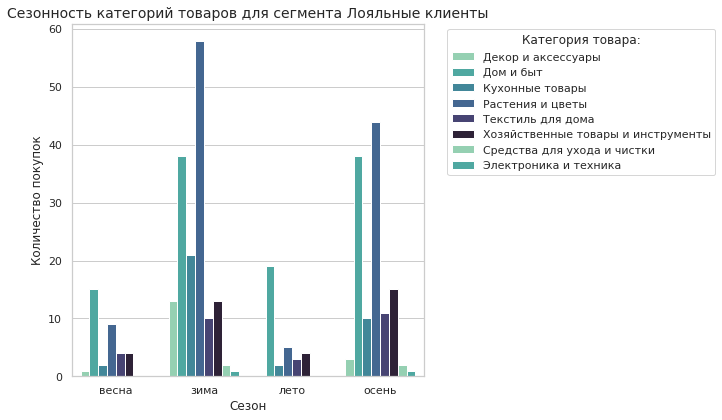

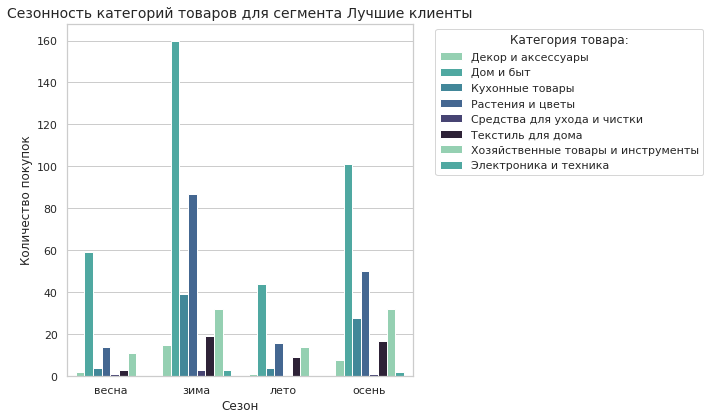

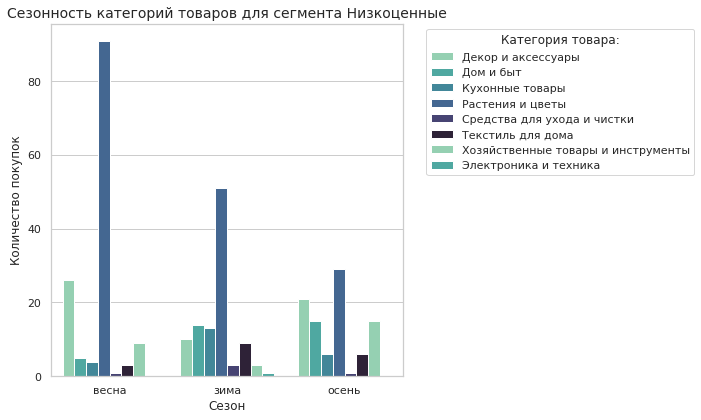

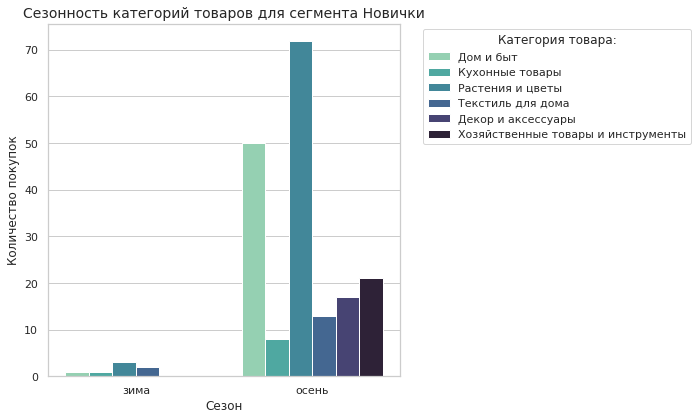

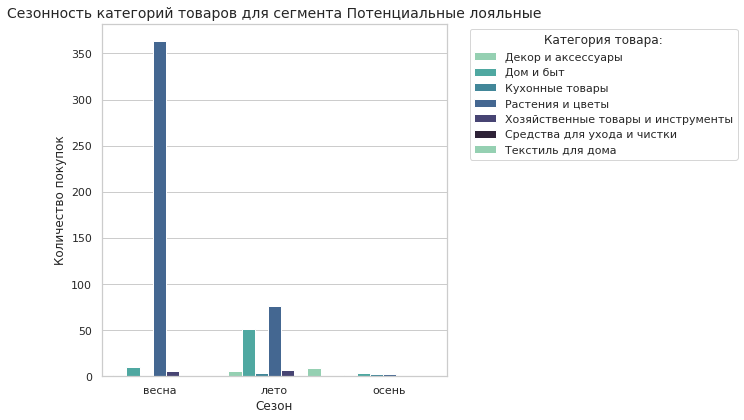

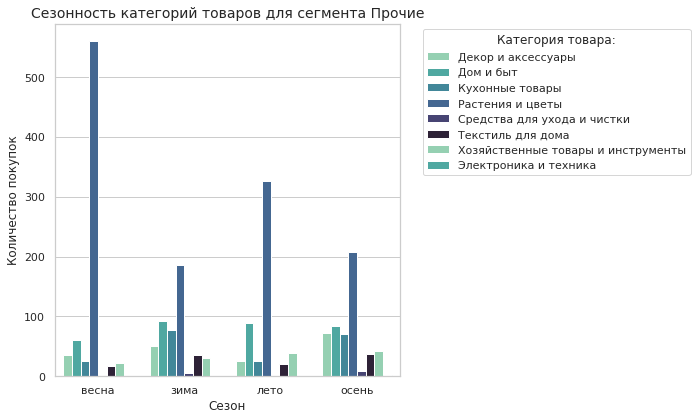

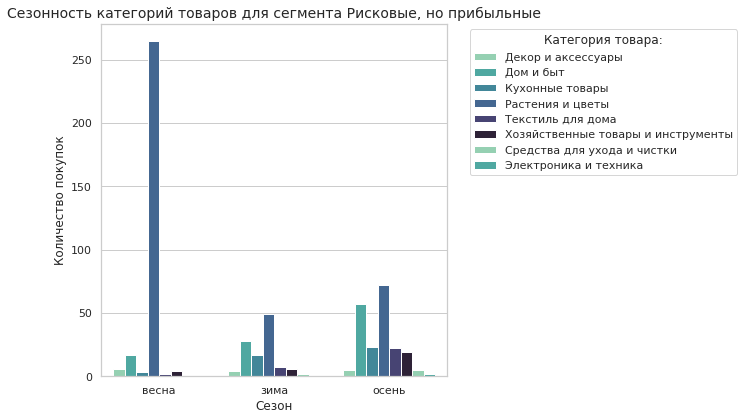

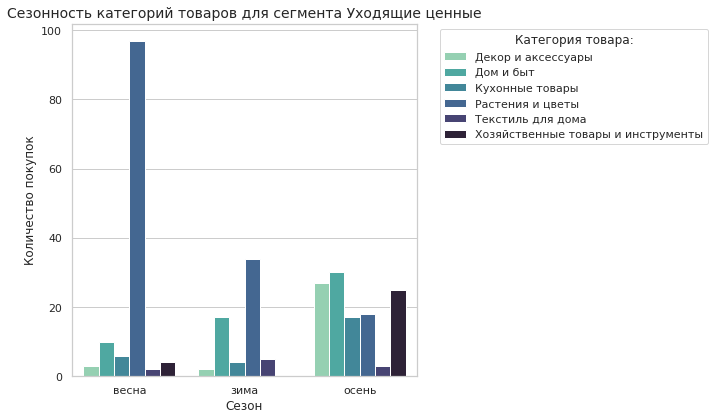

In [183]:
# Список уникальных сегментов:
segments = seasonal_category_counts_by_rfm_segments['segment'].unique()

palette_seas_cat = sns.color_palette("mako_r")

for segment in segments:
    plt.figure(figsize=(10, 6))
    data_segments = seasonal_category_counts_by_rfm_segments[seasonal_category_counts_by_rfm_segments['segment'] == segment]
    
    sns.barplot(
        data=data_segments,
        x='season',
        y='count',
        hue='category',
        palette=palette_seas_cat
    )
    
    plt.title(f'Сезонность категорий товаров для сегмента {segment}', fontsize=14)
    #plt.title(f'Сезонность категорий товаров для сегмента $\\bf{{{segment}}}$', fontsize=14)
    plt.xlabel('Сезон')
    plt.ylabel('Количество покупок')
    plt.legend(title='Категория товара:', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

<div style="border:solid green 2px; padding: 30px">
    
<b> ИТОГО:</b>
    
<b>Связь сегментов пользователей с категориями:</b>
    
1. Лучшие клиенты:
    
Предпочитают категории товаров Дом и быт (наибольшая доля: 364 покупки) , и чуть меньше Растения и цветы (167 покупок). Именно этот сегмент покупателей покупает больше всех товаров категрии Дом и быт. 
Это высокочастотные и платёжеспособные клиенты с широкой товарной корзиной.
    
Рекомендации: можно предлагать им персонализированные предложения и VIP-программы, комплексные скидки на крупные покупки. 

2. Лояльные клиенты:
    
Предпочитают наравне категории товаров Дом и быт и Растения и цветы (110 и 116 покупок соответственно).
Остальные категории товаров тоже покупают, но реже. 
Они делают стабильные заказы, но реже, чем «лучшие».
    
Рекомендации: стоит дклать им напоминания о товарах, которые они часто покупают. Также можно предлагать мягкие программы лояльности, предлагать комбинации товаров  «дом + сад».

3. Новички: 
    
Предпочитают почти в равной степени все категории товаров, хоть и покупки товаров категории Растения и цветы превалируют (75 покупок). Но в целом покупок не много у покупателей этой категории. Они совсем не купили товары категории Электроника и техника. 

Рекомендации: можно предложить им welcome-бонусы и скидки на 2-ю покупку, например. 

4. Потенциальные лояльные: 
    
Предпочитают явно и ярковыражено товары категории Растения и цветы (443 покупки - доминирующая категория). 
Остальные категории товаров покупают в разы меньше: Дом и быт – всего 65 покупок, остальные по 13, 9 и менее покупок. 
Это клиенты с хорошим потенциалом, но пока с узким интересом.

Рекомендации: можно предложить им кросс-селл в категориях Дом и быт и декор. 

5. Уходящие ценные: 
    
Предпочитают тоже Растения и цветы немного больше, но также покупают Дом и быт, Кухонные товары. 
Ранее активные клиенты, сейчас перестали покупать.

Рекомендации: можно предложить им персональные ретаргетинговые письма, скидки на любимые категории, а также сделать им рассылку по обратной связи  («Чего вам не хватило?»). 

6. Рисковые, но прибыльные: 

Предпочитают почти в 3 раза больше катгорию Растения и цветы, чем остальные категории (Дом и быт, Кухонные товары, текстиль). 
Высокая выручка при низкой частоте - это рисковый, но выгодный сегмент.

Рекомендации: нужно попробовать мотивировать их к повторным покупкам: бонусы за повтор, например. 

7. Низкоценные: 
    
Предпочитают тоже категорию Растения и цветы.
Низкий чек и частота. Часто покупают мелочи.
    
Рекомендации: можно предложить им пакеты по акции «купи 2 — заплати за 1»
Рекламные акции с низким порогом входа

8. Прочие:
    
Предпочитают широкий ассортимент, но особенно: растения (1280 заказов – что в 4 раза больше остальных категорий), дом и быт, кухонные товары, декор. 
Это смешанный сегмент.
    
Рекомендации: можно направить на них автоматические рекомендации товаров.
    
    
<b>Связь сегментов пользователей с сезонами:</b>

Общие зависимости и выводы:

- Весна -ключевой сезон для большинства сегментов ( Прочие, потенциальные лояльные, рисковые, но прибыльные, уходящие ценные, низкоценные);

- Зима - пик у самых ценных сегментов (лучшие, лояльные);

- Осень -привлекает новичков, а также рисковых и лучших клиентов;

- Лето - спад активности почти у всех (кроме потенциальных лояльных).

Рекомендации:

Весной можно активировать покупателей через скидки на сад/уход за домом, а также программы лояльности летом предложить: "купи летом — получи бонус осенью". 

    
<b>Сезонность категорий товаров по каждому из получившихся сегментов покупателей:</b>   
    
1) Для лояльных клиентов: активность зимой больше всех, где паиболее популярными товарами являются Растения (до 60 покупок), дом и быт. Осенью предпочтения по категориям товары похожие, но в целом покупок чуть меньше. 

2) Для лучших клиентов: активность больше зимой, и покупаются преимущественно товары категории Дом и быт (до 160 покупок). Во все времена года в целом лидируют покупкиэтой категории. 

3) Для  низкоценных клиентов: во все времена года , кроме лета, юольше всего покупают растения и цветы. 

4) Для новичков, потенциально лояльных, рискованных, но прибыльных: зимой покупок нет почти, а вот осенью покупок больше и преобладают покупки растений .

5) Для уходящих ценных: осенью лидирующей категорией стала Дом и быт, а также покупки хозяйственных товаров почти наравне приходятся с другими категориями. 



<div style="border:solid  green 6px; padding: 30px">
    
<b> ВЫВОД:</b>
    
Проделав RFM-анализ, мы выявили основные категории клиентов:
    
1) Неопределённые клиенты (прочие): 1098 человек.
    
Это самый многочисленный сегмент. Такие клиенты не проявляют ярко выраженного поведения.
    
Средняя общая выручка покупателей данного сегмента: 882 р.
    
2) "Лучшие клиенты": 375 чел. 
    
Это самые ценные покупатели: они покупают часто, тратят много и недавно были активны. Их важно удерживать. Например, предлагать им бонусы, VIP-обслуживание или даже персонализировать предложения.
    
Средняя общая выручка покупателей данного сегмента: 2.920 р.
    
3) "Низкоценные" клиенты: 232 чел. 
    
Эти клиенты мало тратят, редко покупают и давно не проявляли активности. Возможно, они случайные или разовые покупатели.
    
4) "Рисковые, но прибыльные": 193 чел. 
    
Это ранее ценные клиенты, но в последнее время они не очень активны. Можно попробовать вернуть их через эксклюзивные предложения или напоминания.
    
Средняя общая выручка покупателей данного сегмента: 2.700 р.
    
5) "Лояльные клиенты" : 186 чел.
    
Регулярно покупают и приносят доход. Это важная группа, её нужно удерживать, например, через программы лояльности.
    
Средняя общая выручка покупателей данного сегмента: 1060 р.
    
6) "Новички" : 153 чел. 
    
Недавно пришли. Их нужно стимулировать совершать повторные покупки.
    
Средняя общая выручка покупателей данного сегмента: 1.100 р.
    
7) "Потенциальные лояльные" : 115 чел. 
    
Эти клиенты близки к лояльным. Это хорошая целевая аудитория для продвижения.
    
Средняя общая выручка покупателей данного сегмента: 2.300 р.
    
8) "Уходящие ценные" : 55 чел. 
    
Клиенты, которые раньше были активны и прибыльны, но сейчас теряются.
    
Средняя общая выручка покупателей данного сегмента: почти 5000 р.
    

<b>Связь сегментов пользователей с категориями:</b>
    
1. Лучшие клиенты:
    
Предпочитают категории товаров Дом и быт (наибольшая доля: 364 покупки) , и чуть меньше Растения и цветы (167 покупок). Именно этот сегмент покупателей покупает больше всех товаров категрии Дом и быт. 
Это высокочастотные и платёжеспособные клиенты с широкой товарной корзиной.
    
Рекомендации: можно предлагать им персонализированные предложения и VIP-программы, комплексные скидки на крупные покупки. 

2. Лояльные клиенты:
    
Предпочитают наравне категории товаров Дом и быт и Растения и цветы (110 и 116 покупок соответственно).
Остальные категории товаров тоже покупают, но реже. 
Они делают стабильные заказы, но реже, чем «лучшие».
    
Рекомендации: стоит дклать им напоминания о товарах, которые они часто покупают. Также можно предлагать мягкие программы лояльности, предлагать комбинации товаров  «дом + сад».

3. Новички: 
    
Предпочитают почти в равной степени все категории товаров, хоть и покупки товаров категории Растения и цветы превалируют (75 покупок). Но в целом покупок не много у покупателей этой категории. Они совсем не купили товары категории Электроника и техника. 

Рекомендации: можно предложить им welcome-бонусы и скидки на 2-ю покупку, например. 

4. Потенциальные лояльные: 
    
Предпочитают явно и ярковыражено товары категории Растения и цветы (443 покупки - доминирующая категория). 
Остальные категории товаров покупают в разы меньше: Дом и быт – всего 65 покупок, остальные по 13, 9 и менее покупок. 
Это клиенты с хорошим потенциалом, но пока с узким интересом.

Рекомендации: можно предложить им кросс-селл в категориях Дом и быт и декор. 

5. Уходящие ценные: 
    
Предпочитают тоже Растения и цветы немного больше, но также покупают Дом и быт, Кухонные товары. 
Ранее активные клиенты, сейчас перестали покупать.

Рекомендации: можно предложить им персональные ретаргетинговые письма, скидки на любимые категории, а также сделать им рассылку по обратной связи  («Чего вам не хватило?»). 

6. Рисковые, но прибыльные: 

Предпочитают почти в 3 раза больше катгорию Растения и цветы, чем остальные категории (Дом и быт, Кухонные товары, текстиль). 
Высокая выручка при низкой частоте - это рисковый, но выгодный сегмент.

Рекомендации: нужно попробовать мотивировать их к повторным покупкам: бонусы за повтор, например. 

7. Низкоценные: 
    
Предпочитают тоже категорию Растения и цветы.
Низкий чек и частота. Часто покупают мелочи.
    
Рекомендации: можно предложить им пакеты по акции «купи 2 — заплати за 1»
Рекламные акции с низким порогом входа

8. Прочие:
    
Предпочитают широкий ассортимент, но особенно: растения (1280 заказов – что в 4 раза больше остальных категорий), дом и быт, кухонные товары, декор. 
Это смешанный сегмент.
    
Рекомендации: можно направить на них автоматические рекомендации товаров.
    
    
<b>Связь сегментов пользователей с сезонами:</b>

Общие зависимости и выводы:

- Весна -ключевой сезон для большинства сегментов ( Прочие, потенциальные лояльные, рисковые, но прибыльные, уходящие ценные, низкоценные);

- Зима - пик у самых ценных сегментов (лучшие, лояльные);

- Осень -привлекает новичков, а также рисковых и лучших клиентов;

- Лето - спад активности почти у всех (кроме потенциальных лояльных).

Рекомендации:

Весной можно активировать покупателей через скидки на сад/уход за домом, а также программы лояльности летом предложить: "купи летом — получи бонус осенью". 

    
<b>Сезонность категорий товаров по каждому из получившихся сегментов покупателей:</b>   
    
1) Для лояльных клиентов: активность зимой больше всех, где паиболее популярными товарами являются Растения (до 60 покупок), дом и быт. Осенью предпочтения по категориям товары похожие, но в целом покупок чуть меньше. 

2) Для лучших клиентов: активность больше зимой, и покупаются преимущественно товары категории Дом и быт (до 160 покупок). Во все времена года в целом лидируют покупкиэтой категории. 

3) Для  низкоценных клиентов: во все времена года , кроме лета, юольше всего покупают растения и цветы. 

4) Для новичков, потенциально лояльных, рискованных, но прибыльных: зимой покупок нет почти, а вот осенью покупок больше и преобладают покупки растений .

5) Для уходящих ценных: осенью лидирующей категорией стала Дом и быт, а также покупки хозяйственных товаров почти наравне приходятся с другими категориями. 
    

## Шаг 5. (1) Проверка гипотез

In [184]:
rfm.head()

,customer_id,recency,frequency,monetary,r_score,f_score,m_score,RFM_segment,segment
0,000d6849-084e-4d9f-ac03-37174eaf60c4,107,1,555.00,4,1,2,412,Новички
1,001cee7f-0b29-4716-b202-0042213ab038,349,1,442.00,2,1,2,212,Низкоценные
2,00299f34-5385-4d13-9aea-c80b81658e1b,108,1,914.00,4,1,3,413,Новички
3,002d4d3a-4a59-406b-86ec-c3314357e498,368,1,"1,649.00",2,1,4,214,"Рисковые, но прибыльные"
4,003bbd39-0000-41ff-b7f9-2ddaec152037,123,1,"2,324.00",4,1,5,415,Новички


### Первая гипотеза:

(Нужно использовать t-тест / Манн-Уитни для сравнения групп, а также проверить значимость различий между сегментами)

<div style="border:solid lightblue 1px; padding: 30px">

    
<b>Гипотеза: "Выручка по сегментам отличается":</b>

H0 (нулевая гипотеза): Нет статистически значимых различий в выручке между сегментами;

H1 (альтернативная гипотеза): Есть статистически значимые различия в выручке между сегментами.

Для начала проверим на предмет нормальности распределения выручки в каждом сегменте:


In [185]:
from scipy.stats import shapiro

for segment in sorted(rfm['segment'].unique()):
    data_segment = rfm[rfm['segment'] == segment]['monetary']
    
    stat, p_value = shapiro(data_segment)
    print(f'Сегмент {segment}: p-value = {round(p_value, 4)}')
    
    if p_value < 0.05:
        print('    *** Распределение НЕ нормально')
    else:
        print('    *** Распределение похоже на нормальное')

Сегмент Лояльные клиенты: p-value = 0.0
    *** Распределение НЕ нормально
Сегмент Лучшие клиенты: p-value = 0.0
    *** Распределение НЕ нормально
Сегмент Низкоценные: p-value = 0.0
    *** Распределение НЕ нормально
Сегмент Новички: p-value = 0.0
    *** Распределение НЕ нормально
Сегмент Потенциальные лояльные: p-value = 0.0
    *** Распределение НЕ нормально
Сегмент Прочие: p-value = 0.0
    *** Распределение НЕ нормально
Сегмент Рисковые, но прибыльные: p-value = 0.0
    *** Распределение НЕ нормально
Сегмент Уходящие ценные: p-value = 0.0
    *** Распределение НЕ нормально


Наши данные распределены НЕ нормально. В данных много выбросов.Значит, t-test мы провести не сможем. Нужно провести тест для независимых выборок (кластеров), не соответствующих нормальному распределению.

Тест Манна–Уитни (или U-тест) - это непараметрический тест, который не требует нормальности распределения данных. Он сравнивает медианы (или ранговое распределение значений) двух независимых выборок. Также данный тест используется для сравнения выборок разного размера, а также тест Манна–Уитни устойчив к выбросам.

**У нас дано:**

- Данные не распределены нормально;

- Сегменты не зависимы друг от друга;

- Размеры сегментов существенно различаются;

Получается, **тест Манна–Уитни** корректно выбрать для проверки гипотезы о различии выручки между сегментами.

In [186]:
from scipy.stats import mannwhitneyu
from itertools import combinations
from statsmodels.stats.multitest import multipletests

gr1 = rfm[rfm['segment'] == 'Лучшие клиенты']['monetary']
gr2 = rfm[rfm['segment'] == 'Низкоценные']['monetary']

alpha = 0.05

results = mannwhitneyu(gr1, gr2, alternative='two-sided')

p_value = round(results.pvalue, 4)
print('p-значение:', p_value)

print('---'*10)

if p_value < alpha:
    print('Отвергаем нулевую гипотезу: разница статистически значима')
else:
    print('Не получилось отвергнуть нулевую гипотезу, вывод о различии сделать нельзя')

p-значение: 0.0
------------------------------
Отвергаем нулевую гипотезу: разница статистически значима


**Проведем тест Манна-Уитни для каждой пары:**

In [187]:
# Получим все уникальные пары сегментов:
segment_pairs = list(combinations(sorted(rfm['segment'].unique()), 2))

results = []

for s1, s2 in segment_pairs:
    group_1 = rfm[rfm['segment'] == s1]['monetary']
    group_2 = rfm[rfm['segment'] == s2]['monetary']
    stat, p_value = mannwhitneyu(group_1, group_2, alternative='two-sided')
    
    results.append({'Sample 1': s1, 'Sample 2': s2, 'p-value': round(p_value, 4)})

pd.DataFrame(results) # Выводим результаты в виде таблицы

,Sample 1,Sample 2,p-value
0,Лояльные клиенты,Лучшие клиенты,0.00
1,Лояльные клиенты,Низкоценные,0.00
2,Лояльные клиенты,Новички,0.00
3,Лояльные клиенты,Потенциальные лояльные,0.00
4,Лояльные клиенты,Прочие,0.00
5,Лояльные клиенты,"Рисковые, но прибыльные",0.00
6,Лояльные клиенты,Уходящие ценные,0.00
7,Лучшие клиенты,Низкоценные,0.00
8,Лучшие клиенты,Новички,0.00
9,Лучшие клиенты,Потенциальные лояльные,0.00


Получается, у нас сложилась ситуация множественного тестирования: один кластер сравнивается с другими множество раз. А это значит, что возрастает вероятность сделать ошибку первого рода.

Чтобы снизить эту вероятность, нужно понизить уровень значимости α.

Для этого применим поправка Бонферрони:

In [188]:
segment_pairs = list(combinations(sorted(rfm['segment'].unique()), 2))
n_tests = len(segment_pairs)

results = []

for s1, s2 in segment_pairs:
    group_1 = rfm[rfm['segment'] == s1]['monetary']
    group_2 = rfm[rfm['segment'] == s2]['monetary']
    
    stat, p_value = mannwhitneyu(group_1, group_2, alternative='two-sided')
    
    # Применяем Bonferroni-коррекцию:
    corrected_p_value = min(p_value * n_tests, 1.0)
    
    results.append({
        'Sample 1': s1,
        'Sample 2': s2,
        'p-value': round(p_value, 4),
        'Bonferroni corrected p-value': round(corrected_p_value, 4)
    })

bonferroni_results = pd.DataFrame(results)
display(bonferroni_results)

,Sample 1,Sample 2,p-value,Bonferroni corrected p-value
0,Лояльные клиенты,Лучшие клиенты,0.00,0.00
1,Лояльные клиенты,Низкоценные,0.00,0.00
2,Лояльные клиенты,Новички,0.00,0.00
3,Лояльные клиенты,Потенциальные лояльные,0.00,0.00
4,Лояльные клиенты,Прочие,0.00,0.00
5,Лояльные клиенты,"Рисковые, но прибыльные",0.00,0.00
6,Лояльные клиенты,Уходящие ценные,0.00,0.00
7,Лучшие клиенты,Низкоценные,0.00,0.00
8,Лучшие клиенты,Новички,0.00,0.00
9,Лучшие клиенты,Потенциальные лояльные,0.00,0.00


Или лучше использовать поправку Холма, или метод Шидака:

In [189]:
from statsmodels.stats.multitest import multipletests

segment_pairs = list(combinations(sorted(rfm['segment'].unique()), 2))

raw_p_values = []
pair_labels = []

# Сохраняем p-value и пары
for s1, s2 in segment_pairs:
    group_1 = rfm[rfm['segment'] == s1]['monetary'].dropna()
    group_2 = rfm[rfm['segment'] == s2]['monetary'].dropna()
    
    if len(group_1) > 0 and len(group_2) > 0:
        stat, p_value = mannwhitneyu(group_1, group_2, alternative='two-sided')
        raw_p_values.append(p_value)
        pair_labels.append((s1, s2))

# Применяем коррекцию методом Holm ( можно и 'sidak' )
reject, corrected_pvals, _, _ = multipletests(raw_p_values, alpha=0.05, method='holm')


results = []
for (s1, s2), pval, corr_pval, rej in zip(pair_labels, raw_p_values, corrected_pvals, reject):
    results.append({
        'Сегмент 1': s1,
        'Сегмент 2': s2,
        'p-value': round(pval, 4),
        'Корректированный p-value': round(corr_pval, 4),
        'Различие значимо': 'Да' if rej else 'Нет'
    })

results_df = pd.DataFrame(results)
display(results_df)

,Сегмент 1,Сегмент 2,p-value,Корректированный p-value,Различие значимо
0,Лояльные клиенты,Лучшие клиенты,0.00,0.00,Да
1,Лояльные клиенты,Низкоценные,0.00,0.00,Да
2,Лояльные клиенты,Новички,0.00,0.00,Да
3,Лояльные клиенты,Потенциальные лояльные,0.00,0.00,Да
4,Лояльные клиенты,Прочие,0.00,0.00,Да
5,Лояльные клиенты,"Рисковые, но прибыльные",0.00,0.00,Да
6,Лояльные клиенты,Уходящие ценные,0.00,0.00,Да
7,Лучшие клиенты,Низкоценные,0.00,0.00,Да
8,Лучшие клиенты,Новички,0.00,0.00,Да
9,Лучшие клиенты,Потенциальные лояльные,0.00,0.00,Да


<div style="border:solid green 2px; padding: 30px">
    
<b> ИТОГО:</b>

Проверяя гипотезу о разнице выручки по сегментам, мы пользовались методом Манна–Уитни, в результате которого получились следующие выводы:
    
Разница между значениями в выручке между сегментами статистически значима во всех случаях, кроме сравнения сегментов:
    
- Лучшие клиенты VS Рисковые, но прибыльные;
    
- Лучшие клиенты VS Уходящие ценные;
    
- Новички VS Прочие.
    
У этих сегментов между собой нет статистически значимых различий в выручке.

### Вторая гипотеза:

<div style="border:solid lightblue 1px; padding: 30px">
    
<b>Гипотеза: "Количество покупок (frequency) отличается между сегментами":</b>

H0 (нулевая гипотеза): Нет статистически значимых различий в количестве покупок между сегментами;

H1 (альтернативная гипотеза): Есть статистически значимые различия в количестве покупок хотя бы между одной парой сегментов.

In [190]:
for segment in sorted(rfm['segment'].unique()):
    data_segment = rfm[rfm['segment'] == segment]['frequency']
    
    stat, p_value = shapiro(data_segment)
    print(f'Сегмент {segment}: p-value = {round(p_value, 4)}')
    
    if p_value < 0.05:
        print('    *** Распределение НЕ нормально')
    else:
        print('    *** Распределение похоже на нормальное')

Сегмент Лояльные клиенты: p-value = 0.0
    *** Распределение НЕ нормально
Сегмент Лучшие клиенты: p-value = 0.0
    *** Распределение НЕ нормально
Сегмент Низкоценные: p-value = 1.0
    *** Распределение похоже на нормальное
Сегмент Новички: p-value = 1.0
    *** Распределение похоже на нормальное
Сегмент Потенциальные лояльные: p-value = 0.0
    *** Распределение НЕ нормально
Сегмент Прочие: p-value = 0.0
    *** Распределение НЕ нормально
Сегмент Рисковые, но прибыльные: p-value = 1.0
    *** Распределение похоже на нормальное
Сегмент Уходящие ценные: p-value = 0.0
    *** Распределение НЕ нормально


Также будем использовать **тест Манна–Уитни** для проверки гипотезы о различии количества покупок (frequency) между сегментами, так как больше половины сегментов имеют данные, которые распределены не нормально.

In [191]:
segment_pairs = list(combinations(sorted(rfm['segment'].unique()), 2))

raw_p_values = []
pair_labels = []

for s1, s2 in segment_pairs:
    group_1 = rfm[rfm['segment'] == s1]['frequency'].dropna()
    group_2 = rfm[rfm['segment'] == s2]['frequency'].dropna()
    
    if len(group_1) > 0 and len(group_2) > 0:
        stat, p_value = mannwhitneyu(group_1, group_2, alternative='two-sided')
        raw_p_values.append(p_value)
        pair_labels.append((s1, s2))

reject, corrected_pvals, _, _ = multipletests(raw_p_values, alpha=0.05, method='holm')

results_f = []
for (s1, s2), pval, corr_pval, rej in zip(pair_labels, raw_p_values, corrected_pvals, reject):
    results_f.append({
        'Сегмент 1': s1,
        'Сегмент 2': s2,
        'p-value': round(pval, 4),
        'Корректированный p-value': round(corr_pval, 4),
        'Различие значимо': 'Да' if rej else 'Нет'
    })

results_data = pd.DataFrame(results_f)
display(results_data)

,Сегмент 1,Сегмент 2,p-value,Корректированный p-value,Различие значимо
0,Лояльные клиенты,Лучшие клиенты,0.00,0.00,Да
1,Лояльные клиенты,Низкоценные,0.00,0.00,Да
2,Лояльные клиенты,Новички,0.00,0.00,Да
3,Лояльные клиенты,Потенциальные лояльные,0.00,0.00,Да
4,Лояльные клиенты,Прочие,0.00,0.00,Да
5,Лояльные клиенты,"Рисковые, но прибыльные",0.00,0.00,Да
6,Лояльные клиенты,Уходящие ценные,0.21,0.85,Нет
7,Лучшие клиенты,Низкоценные,0.00,0.00,Да
8,Лучшие клиенты,Новички,0.00,0.00,Да
9,Лучшие клиенты,Потенциальные лояльные,0.00,0.00,Да


<div style="border:solid green 2px; padding: 30px">
    
<b> ИТОГО:</b>

Проверяя гипотезу о наличии статистически значимых различий в количестве покупок между сегментами, мы пользовались методом Манна–Уитни, в результате которого получились следующие выводы:
    
Разница между значениями в в количестве покупок между сегментами статистически значима во всех случаях, кроме таких сегментов, как:
    
- Лояльные клиенты VS Уходящие ценные;
    
- Низкоценные VS Новички;
    
- Низкоценные VS Рисковые, но прибыльные;
    
- Новички VS Рисковые, но прибыльные.
    
У этих сегментов между собой нет статистически значимых различий в количестве покупок.

<div style="border:solid  green 6px; padding: 30px">
    
<b> ВЫВОД:</b>
    
1. Проверяя гипотезу о разнице выручки по сегментам, мы пользовались методом Манна–Уитни, в результате которого получились следующие выводы:
    
Разница между значениями в выручке между сегментами статистически значима во всех случаях, кроме сравнения сегментов:
    
- Лучшие клиенты VS Рисковые, но прибыльные;
    
- Лучшие клиенты VS Уходящие ценные;
    
- Новички VS Прочие.
    
У этих сегментов между собой нет статистически значимых различий в выручке.
    
    
2. Проверяя гипотезу о наличии статистически значимых различий в количестве покупок между сегментами, мы пользовались методом Манна–Уитни, в результате которого получились следующие выводы:
    
Разница между значениями в в количестве покупок между сегментами статистически значима во всех случаях, кроме таких сегментов, как:
    
- Лояльные клиенты VS Уходящие ценные;
    
- Низкоценные VS Новички;
    
- Низкоценные VS Рисковые, но прибыльные;
    
- Новички VS Рисковые, но прибыльные.
    
У этих сегментов между собой нет статистически значимых различий в количестве покупок.

## Шаг 6. Выводы и рекомендации 

<div style="border:solid  green 6px; padding: 30px">
    
<b> ОБЩИЙ ВЫВОД:</b>
    
Таким образом, проведя исследовательский анализ данных покупателей интернет-магазина товаров для дома «Пока все ещё тут», мы провели полноценный анализ товарного ассортимента, распределив его на категории, а также выявили основные профили покупателей.
    
    
<b>В результате предобработки данных </b> , мы:

- преобразовали тип данных столбца data;

- привели столбец product к нижнему регистру;

- выявили не явные дубликаты в датасете и удалили некоторые из них, в результате чего из первоначальных 7474 строк датасета у нас стало 5525 строк;

- были добавлены новые столбцы: month, total_price и season;
    
- определено, что в датасете представлены 1331 уникальных товаров, продаваемых в интернет-магазине;

- также была проведена категоризация товаров из столбца product и создан новый столбец category.
    
Всего получилось 8 категорий товаров. Статистика по категориям товаров:
    
1) Растения и цветы: 2818 товаров (51%)
    
2) Дом и быт: 1179 товаров (21.3%)
    
3) Кухонные товары: 428 товаров (7.7%)
    
4) Хозяйственные товары и инструменты: 393 товаров (7.1%)
    
5) Декор и аксессуары: 363 товаров (6.6%)
    
6) Текстиль для дома: 286 товаров (5.2%)
    
7) Средства для ухода и чистки: 43 товаров (0.8%)
    
8) Электроника и техника: 15 товаров (0.3%);

- определен товар с максимальной суммой заказа по датасету (по столбцу price): товар сушилка уличная lеifhеiт 85210 linоmатiс v 400 40 м 175х237х237 см зеленая на сумму 14,917.00 руб.;

- определили рассматриваемый период в данных: анализ будем проводить по данным пользователей, сделавших заказы с 1 октября 2018 года по 31 января 2020 года (данные за 1 год и 3 месяца).
    
    
<b> 1.Общая статистика и исследовательский анализ</b>:    
  
- Уникальных покупателей: 2413 (чел.);
    
- Уникальных заказов: 3475 (чел.);
    
- Уникальных товаров: 2332 (чел.);
    
- Распределение категорий товаров по стоимости:
    
1) категория товаров "Растения и цветы" преобладают среди товаров группы до 2000 руб.
    
2) товары категории "Дом и быт" лидируют в остальных группах товаров по стоимости (более 10.000 р., от 2.000 до 5.000, и от 5.000 до 10.000 р.).
    
3) В основном товары, которые куплены больше , чем за 10.000 руб. принадлежат категории "Дом и быт", и лишь несколько дорогих товаров принадлежат остальным категориям товаров, кроме "декора", "элетроники и техники" и "средств для ухода и чистки" - среди этих категорий нет дорогих товаров.
    
<b> 2. Частота покупок:</b>
    
1) Частота заказов на одного клиента:
    
Среднее количество заказов на клиента: 1.44
    
Медианное количество заказов на клиента: 1.0
    
Максимальное количество заказов на клиента: 126
    
2) Распределение заказов по месяцам и дням (поиск пиков):
    
Построив графики распределения количества заказов по месяцам, сезонам и дням недели, мы заметили, что:
    
- больше всего заказов делаются зимой, потом весной, меньше всего летом.
    
- наибольшее число покупок было сделано в декабре 2018, феврале 2019, марте-апреле 2019 и декабре 2019 и январе 2020. Максимальное количество покупок сделано было в январе 2020. 
    
- Кастельно дней недели: наибольшее количество заказов приходится на вторник, затем понедельник. В целом , кажется, что в будние дни покупательская активность более сильная. Однако в выходные: в воскресенье люди чаще покупают, нежели чем в субботу.


<b> 3. Популярность товаров:</b>

Анализируя популярность товаров, мы выявили:

1) Топ-15 товаров по количеству купленного товара:
    
Наиболее покупаемыми товарами оказались муляжи яблок(318 шт.), фурнитура для дверей, щетки и ерши, а также одежные крючки и плечики. Это в основном дешевые, массовые товары для дома и быта.

2) Топ-15 товаров по количеству заказов:
    
Лидируют растение пеларгония (разные сорта) (по примерно 60 заказов всего каждого сорта), а также тележки и багажные сумки. Эти товары встречаются реже, но с высокой частотой заказов по конкретным позициям.

3) Наиболее популярные категории товаров:
    
Растения и цветы (51.6%) - категория-лидер по количеству покупок ;

Дом и быт (20.7%)

Остальные категории - значительно ниже (от 7.8% и ниже).

Покупатели активно интересуются зелеными товарами.

4) Наиболее прибыльные категории товаров:
    
Дом и быт — (1.84 млн.) - лидер по выручке;

Растения и цветы (590 тыс.)

Хозяйственные товары и кухонные принадлежности тоже дают значительную выручку (412 тыс.).

Хотя растения лидируют по количеству продаж, наибольшую выручку приносят товары для дома — возможно, за счет более высокой цены или объема покупки.

5) Покупатели с самыми дорогими покупками по сезонам:
    
Самая дорогая покупка весной: 41.900 р.

Самая дорогая покупка зимой : 16.536 р.

Самая дорогая покупка летом : 20.232 р.

Самая дорогая покупка осенью : 57.278 р.

6) Топ-покупатели по каждому сезону по среднему чеку:
Самые высокие средние чеки наблюдаются зимой и летом : до 16.536 р. за заказ.

Весной и осенью также есть дорогие средние чеки, но менее выражено.

Зимние и летние заказы часто связаны с крупными приобретениями — например, подарками, отпускными покупками или закупкой впрок.


<b>4. Анализ сезонности (цикличности):</b>

Проанализировав сезонность продаж, мы выявили, что:
    
- Выручка выше осенью, затем зимой, а вот летом продажи ниже всех.

- Зимой покупатели делают заказов больше, чем осенью. Однако летом по-прежнему меньше всего заказов делается.

- Касательно распределения заказов по сезонам и категориям товаров: весной и зимой лидируют покупки категории товаров “Растения и цветы”, а вот летом и осенью категорией товаров-лидером является “Дом и быт”. Весной и летом меньше всего покупалось товаров категории «Текстиль для дома». Пик покупок товаров категории «Электроника и техника» пришелся на лето и весну. Больше всего товаров категории “Дом и быт” покупалось зимой и осенью.



<b>5. Анализ частоты покупок (Frequency):</b>

1) Распределение количества заказов на клиента:

касательно распределения количества заказов на клиента:

Есть клиенты, которые делали по 35, 17 заказов. Остальные покупатели делали меньше заказов.

Среднее количество заказов на клиента: 1.39

Медианное количество заказов на клиента: 1.0

35 заказов – делал один покупатель.

17, 7, 5 заказов – тоже делали всего по одному покупателю.

3 заказа сделали всего 18 человек, 2 заказа сделали 855 человек со всего датасета, а один заказ сделали 1565 человек – это 64% от всех покупателей магазина. 
Только 35% клиентов делают повторный еще один заказ, а меньше 1% (всего 18 клиентов) - сделали 3 заказа, меньше 1% в сумме сделали по 4 и более заказов. 
    
Самые крупные покупки сделали клиенты магазина, которые совершали 2 и более покупок в магазине. Хотя есть некоторые исключения: есть пара клиентов, которые сделали крупные дорогие покупки за 1 раз посещения интернет-магазина.

Retention rate (повторные покупки): 35.99%. 
    
С возвращаемостью у нас все печально. Есть направление, на которое стоит обратить внимание заказчика и поработать над повышением метрики.

2)  Рассмотрев интервалы между повторными покупками, мы заметили следующее:
    
- 55 человек делали повторную покупку спустя год;
    
- 517 человека делали повторную покупку полгода спустя;
    
- 166 человек делали повторный заказ в магазине спустя от 1 до 6 месяцев;
    
- 19 человек повторяли свой заказ спустя 2 недели-месяц;
    
- 530 человек повторяли покупки спустя день или неделю.

<div style="border:solid  green 6px; padding: 30px">
    
Благодаря проведенному RFM-анализу, были выявлены следующие сегменты покупателей интернет-магазина: 
    
2407 покупателя были поделены на следующие кластеры покупателей:

- Лучшие клиенты (375 чел.)
    
- Низкоценные (232 чел.)
    
- Рисковые, но прибыльные (193 чел.)
    
- Лояльные клиенты (186 чел.)
    
- Новички (153 чел.)
    
- Потенциальные лояльные (115 чел.)
    
- Уходящие ценные (55 чел.)
    
- Прочие (1098 чел.)
    
<b>1. Лучшие клиенты:</b>
Совершают частые и дорогие покупки, делают это регулярно.
Сезонность: пик покупок - зимой и осенью.
Категории товаров: дом и быт, растения, кухонные товары.

Средняя общая выручка покупателей данного сегмента: 2.920 р.
    
Рекомендации: персональные предложения и эксклюзивные акции, программы лояльности.Сегмент стоит удерживать через премиум-сервис и заботу.

<b>2. Лояльные клиенты:</b>
Постоянные покупатели, немного менее активные, чем лучшие.
Сезонность: активны в зимний и осенний сезоны.
Категории товаров: растения, дом и быт, хозяйственные товары.
    
Средняя общая выручка покупателей данного сегмента: 1060 р.
    
Рекомендации: поддерживать интерес через регулярные email-рассылки.Давать бонусы за повторные покупки.
Предлагать допродажи и аксессуары к ранее купленным товарам.

<b>3. Новички:</b>
Недавно пришли, редко покупают, низкая выручка.
Сезонность: осень - пик покупок.
Категории товаров: Растения, дом и быт.
       
Средняя общая выручка покупателей данного сегмента: 1.100 р.
    
Рекомендации: приветственные письма с бонусом на первую покупку, возможно, поддержка через чат-бот после первого заказа.
Акции типо "2 по цене 1", чтобы повысить их вовлечённость.

<b>4. Потенциальные лояльные:</b>
Средние по всем метрикам, но с потенциалом к росту.
Сезонность: пик активности — весна и лето.
Категории товаров: Растения, дом и быт.
    
Средняя общая выручка покупателей данного сегмента: 2.300 р.
    
Рекомендации: мотивировать к повторной покупке («купи снова — получи бонус»), персональные рекомендации на основе предыдущих покупок, удерживающие скидки.

<b>5. Уходящие ценные:</b>
Ранее активные и доходные клиенты, но сейчас не покупают.
Сезонность: весна и осень.
Категории товаров: Дом и быт, хозяйственные товары.
    
Средняя общая выручка покупателей данного сегмента: почти 5000 р.
    
Рекомендации: срочные акции: «только для вас», «получите -20%», персональные напоминания о товарах.

<b>6. Рисковые, но прибыльные: </b>
Высокая выручка, но редкие и давние покупки.
Сезонность: весна и осень.
Категории товаров: растения, дом и быт, текстиль.
    
Средняя общая выручка покупателей данного сегмента: 2.700 р.

Рекомендации: рекламные рассылки с акцентом на любимые категории, персонализированная email-реактивация.

<b>7. Низкоценные:</b>
Мало тратят, редко покупают.
Сезонность: активность весной, зимой и осенью.
Категории товаров: растения и цветы.
    
Средняя общая выручка покупателей данного сегмента: 312.75 р.
    
Рекомендации: акции типо «2 по цене 1», рассылка триггерных предложений: «вы давно не покупали…»...

<b>8. Прочие:</b>
Это смешанный сегмент, высокая активность, но без чёткого паттерна.
Сезонность: весна, лето и осень почти равномерны.
Категории товаров: растения (лидер с огромным отрывом), дом и быт, кухонные товары.

Средняя общая выручка покупателей данного сегмента: 882 р.
    
Рекомендации: категориальные предложения по сезону.

## Шаг 4. (2) Сегментация покупателей

### 1. Подготовим признаки для сегментации пользователей:

•	Частота покупок (общее количество заказов) (frequency);

•	Количество дней с последней покупки (recency);

•	Средняя цена товара;

•	Средний чек;

•	Количество уникальных товаров;

•	Среднее количество товаров в заказе.



In [192]:
customer_features = data.groupby('customer_id').agg({
    'order_id': 'nunique',                                      # Frequency
    'price': 'mean',                                            # Средняя цена товара
    'total_price': 'mean',                                      # Средний чек 
    'product': 'nunique',                                       # Уникальные товары
    'quantity': 'mean'                                          # Среднее количество товаров
})

customer_features.columns = [
    'frequency', 'avg_price',
    'avg_check',
    'unique_products', 'avg_quantity'
]

customer_features = customer_features.reset_index()

**Масштабируем признаки:**

In [193]:
# from sklearn.preprocessing import StandardScaler

features = customer_features.drop('customer_id', axis=1)
# y = customer_features['customer_id']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features) # Признаки к одному масштабу привели
print(X_scaled[:10])

[[-0.4234357  -0.56135989 -0.61798109  0.55819025 -0.20669021]
 [-0.4234357  -0.26522553 -0.38640911 -0.36543299 -0.20669021]
 [-0.4234357  -0.2505775  -0.02597391 -0.36543299 -0.1085607 ]
 [-0.4234357   0.91345273  0.53529701 -0.36543299 -0.20669021]
 [-0.4234357   0.43787998  1.0507499  -0.36543299 -0.1085607 ]
 [-0.4234357  -0.57185765  0.44900638 -0.36543299  0.87273438]
 [ 0.66546359  1.51402201  2.2760005  -0.05755857 -0.15762546]
 [-0.4234357   0.21815951 -0.00841033 -0.36543299 -0.20669021]
 [ 0.66546359 -0.54012025 -0.60137206 -0.05755857 -0.20669021]
 [-0.4234357  -0.51473033 -0.58151758 -0.36543299 -0.20669021]]


### 2. Используем методы кластеризации:

•	Machine learning: K-Means + hierarchical clustering;

•	Визуализируем получившиеся сегменты (кластеры).

Построим матрицу расстояний функцией linkage() на стандартизованной матрице признаков и нарисуем дендрограмму:

In [194]:
# from scipy.cluster.hierarchy import dendrogram, linkage
linked = linkage(X_scaled, method = 'ward')
display(linked)

array([[0.00000000e+00, 2.15800000e+03, 0.00000000e+00, 2.00000000e+00],
       [1.00000000e+00, 1.21500000e+03, 0.00000000e+00, 2.00000000e+00],
       [2.00000000e+00, 1.32800000e+03, 0.00000000e+00, 2.00000000e+00],
       ...,
       [4.80700000e+03, 4.80900000e+03, 5.72601497e+01, 1.81300000e+03],
       [4.80400000e+03, 4.80800000e+03, 5.75326795e+01, 5.94000000e+02],
       [4.81000000e+03, 4.81100000e+03, 6.68386495e+01, 2.40700000e+03]])

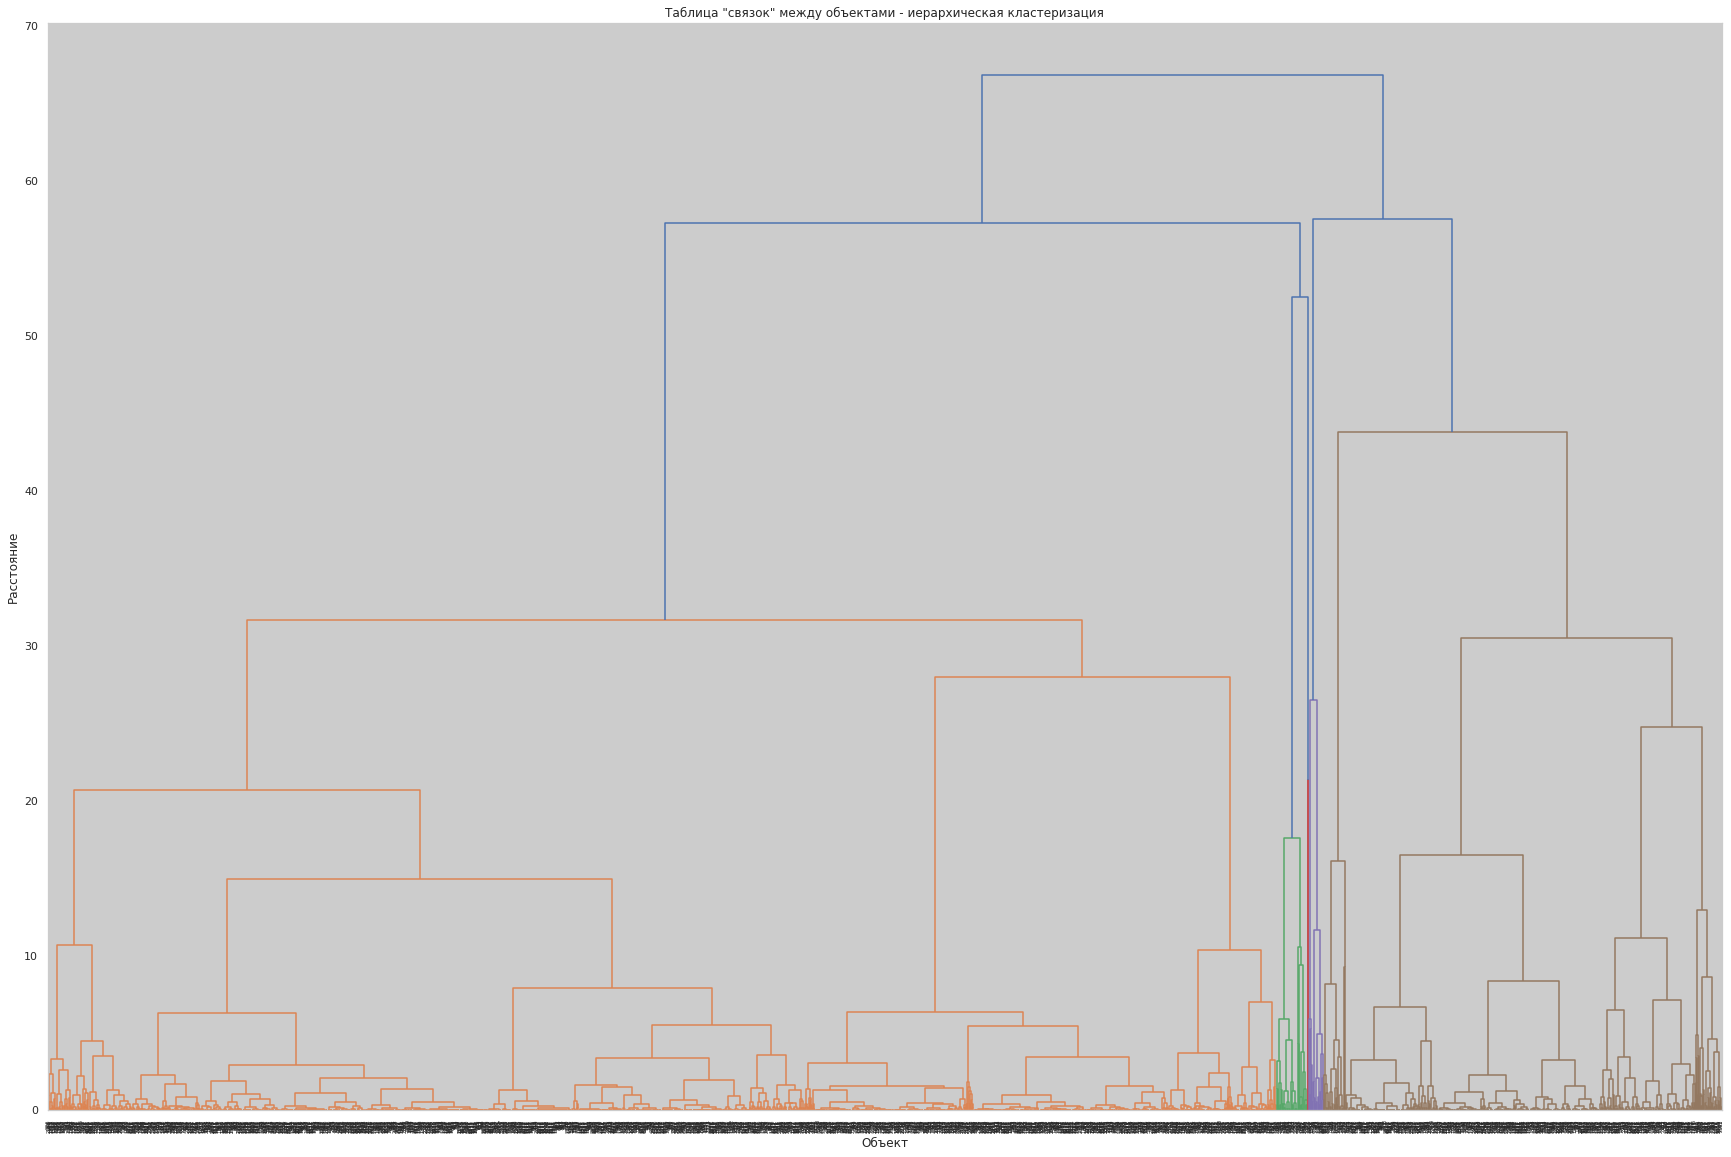

In [195]:
# Построение дендрограммы:
plt.figure(figsize=(30, 20))
dendrogram(linked, orientation='top')
plt.title('Таблица "связок" между объектами - иерархическая кластеризация')
plt.xlabel('Объект')
plt.ylabel('Расстояние')
plt.show()

<div style="border:solid green 2px; padding: 30px">
    
<b> ИТОГО:</b>


Согласно дендрограмме, по цветам выделилилось 6 кластеров.

In [196]:
# from sklearn.cluster import KMeans

# Задаём число кластеров:
kmeans = KMeans(n_clusters=6, random_state=0)
labels = kmeans.fit_predict(X_scaled)
customer_features['cluster'] = labels
customer_features.head()

,customer_id,frequency,avg_price,avg_check,unique_products,avg_quantity,cluster
0,000d6849-084e-4d9f-ac03-37174eaf60c4,1,138.75,138.75,4,1.00,5
1,001cee7f-0b29-4716-b202-0042213ab038,1,442.00,442.00,1,1.00,5
2,00299f34-5385-4d13-9aea-c80b81658e1b,1,457.00,914.00,1,2.00,5
3,002d4d3a-4a59-406b-86ec-c3314357e498,1,"1,649.00","1,649.00",1,1.00,1
4,003bbd39-0000-41ff-b7f9-2ddaec152037,1,"1,162.00","2,324.00",1,2.00,1


Визуализируем:

In [197]:
# выводим статистику по средним значениям наших признаков по кластеру: 
# мы группируем данные по меткам кластеров и вычисляем средние значения для всех признаков:

mean_values = customer_features.groupby('cluster')[features.columns].mean() # ТОЛЬКО нужные признаки в featuers, а не в customer_features
display(mean_values)

,frequency,avg_price,avg_check,unique_products,avg_quantity
cluster,,,,,
0,1.56,140.72,163.94,15.31,1.31
1,1.39,"1,583.39","1,920.19",1.41,1.84
2,1.31,"4,314.15","5,468.24",1.31,3.00
3,1.00,44.61,"3,921.53",1.05,96.84
4,35.00,677.07,"1,272.84",44.00,6.87
5,1.37,321.25,450.06,1.78,2.52


In [198]:
# Функция для отображения scatter-графика с кластерами:
#def show_clusters_on_plot(df, x_col, y_col, cluster_col):
    #plt.figure(figsize=(7, 5))
    #sns.scatterplot(
        #data=df, 
        #x=x_col, 
        #y=y_col,
        #hue=cluster_col, 
        #palette='Paired'
    #)
    #plt.title(f'Кластеры: {x_col} vs {y_col}')
    #plt.xlabel(x_col)
    #plt.ylabel(y_col)
    #plt.legend(title='Кластер')
    #plt.tight_layout()
    #plt.show()

In [199]:
# отрисуем графики для попарных сочетаний признаков с разметкой по кластерам:
#col_pairs = list(itertools.combinations(features.columns, 2))
#for pair in col_pairs:
    #show_clusters_on_plot(customer_features, pair[0], pair[1], 'cluster')

Или используем визуализацию кластеров после понижения размерности с помощью **PCA (Principal Component Analysis)** :

метод, который позволяет упростить многомерные данные, сохранив их структуру.

Создаём объект PCA и указываем, что мы хотим свести все признаки к двум главным компонентам. Это означает:«Найди такие 2 направления (оси), по которым можно наилучшим образом представить многомерные данные, сохранив максимум информации (дисперсии)».

Метод помогает упростить многомерность (7 признаков → 2), чтобы отобразить всё на графике:

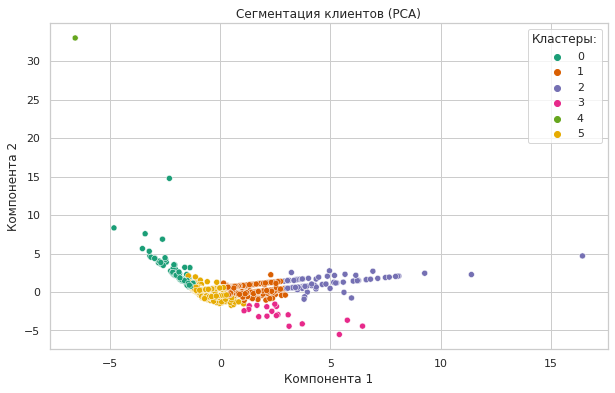

In [200]:
#Используем PCA для визуализации класетров:

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)
customer_features['pca_1'] = components[:, 0]
customer_features['pca_2'] = components[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=customer_features, x='pca_1', y='pca_2', hue='cluster', palette='Dark2')
plt.title('Сегментация клиентов (PCA)')
plt.xlabel('Компонента 1')
plt.ylabel('Компонента 2')
plt.legend(title='Кластеры:')
plt.show()

In [201]:
cluster_profiles = customer_features.groupby('cluster').mean().round(2)
display(cluster_profiles)

,frequency,avg_price,avg_check,unique_products,avg_quantity,pca_1,pca_2
cluster,,,,,,,
0,1.56,140.72,163.94,15.31,1.31,-1.88,2.33
1,1.39,"1,583.39","1,920.19",1.41,1.84,1.11,0.22
2,1.31,"4,314.15","5,468.24",1.31,3.00,4.74,1.19
3,1.00,44.61,"3,921.53",1.05,96.84,2.77,-2.92
4,35.00,677.07,"1,272.84",44.00,6.87,-6.59,33.05
5,1.37,321.25,450.06,1.78,2.52,-0.48,-0.23


In [202]:
customer_features['cluster'].value_counts()

5    1728
1     483
2      89
0      87
3      19
4       1
Name: cluster, dtype: int64

In [203]:
# Определим номер такого кластера
small_cluster = customer_features['cluster'].value_counts().idxmin()

# Найдём клиента
smallest_cluster_of_two = customer_features[customer_features['cluster'] == small_cluster]
display(smallest_cluster_of_two)

# .idxmin() — возвращает номер кластера, где клиентов меньше всего.

,customer_id,frequency,avg_price,avg_check,unique_products,avg_quantity,cluster,pca_1,pca_2
727,4d93d3f6-8b24-403b-a74b-f5173e40d7db,35,677.07,"1,272.84",44,6.87,4,-6.59,33.05


In [204]:
display("Одинокие два клиента в кластере:", smallest_cluster_of_two['customer_id'])

'Одинокие два клиента в кластере:'

727    4d93d3f6-8b24-403b-a74b-f5173e40d7db
Name: customer_id, dtype: object

In [205]:
clients_data = data[data['customer_id'].isin([
    '4d93d3f6-8b24-403b-a74b-f5173e40d7db', 
    '73d1cd35-5e5f-4629-8cf2-3fda829d4e58'
])]
display(clients_data)

In [206]:
repeat_data_sorted

In [207]:
# Отбираем только строки по этим клиентам:
smallest_cluster_of_two_data = repeat_data_sorted[
    repeat_data_sorted['customer_id'].isin([
        '4d93d3f6-8b24-403b-a74b-f5173e40d7db',
        '73d1cd35-5e5f-4629-8cf2-3fda829d4e58'
    ])
]
display(smallest_cluster_of_two_data)

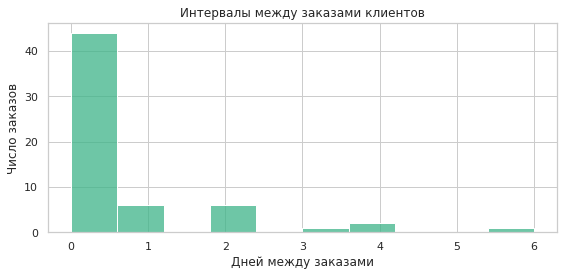

In [208]:
plt.figure(figsize=(8, 4))
sns.histplot(smallest_cluster_of_two_data['days_between_orders'].dropna(), bins=10, color='#3EB489')
plt.title('Интервалы между заказами клиентов')
plt.xlabel('Дней между заказами')
plt.ylabel('Число заказов')
plt.tight_layout()
plt.show()

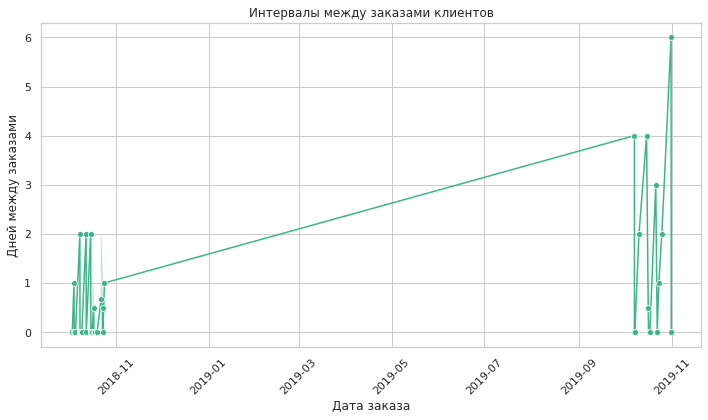

In [209]:
smallest_cluster_of_two_data = smallest_cluster_of_two_data.sort_values('date')

plt.figure(figsize=(10, 6))
sns.lineplot(data=smallest_cluster_of_two_data, x='date', y='days_between_orders', marker='o', color='#3EB489')
plt.title('Интервалы между заказами клиентов')
plt.xlabel('Дата заказа')
plt.ylabel('Дней между заказами')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Удалим этих клиентов из базы данных:

In [210]:
data = data[~data['customer_id'].isin(
    ['4d93d3f6-8b24-403b-a74b-f5173e40d7db', '73d1cd35-5e5f-4629-8cf2-3fda829d4e58']
)]

# data = data[data['customer_id'] != '4d93d3f6-8b24-403b-a74b-f5173e40d7db']

In [211]:
customer_features = data.groupby('customer_id').agg({
    'order_id': 'nunique',                                      # Frequency
    'date': lambda x: (data['date'].max() - x.max()).days,      # Recency
    'price': 'mean',                                            # Средняя цена товара
    'total_price': 'mean',                                      # Средний чек 
    'product': 'nunique',                                       # Уникальные товары
    'quantity': 'mean'                                          # Среднее количество товаров
})

customer_features.columns = [
    'frequency', 'recency', 'avg_price',
    'avg_check',
    'unique_products', 'avg_quantity'
]

customer_features = customer_features.reset_index()

In [212]:
features = customer_features.drop('customer_id', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features) 

In [213]:
kmeans = KMeans(n_clusters=6, random_state=0)
labels = kmeans.fit_predict(X_scaled)
customer_features['cluster'] = labels

In [214]:
mean_values = customer_features.groupby('cluster')[features.columns].mean() # ТОЛЬКО нужные признаки в featuers, а не в customer_features
display(mean_values)

,frequency,recency,avg_price,avg_check,unique_products,avg_quantity
cluster,,,,,,
0,1.04,374.87,429.14,670.73,2.10,3.31
1,2.02,63.27,661.84,692.34,2.06,1.20
2,1.00,307.38,42.59,"4,138.06",1.06,105.62
3,1.55,286.48,119.11,145.01,20.57,1.33
4,1.00,171.91,460.71,654.04,1.26,2.78
5,1.31,218.32,"3,434.41","4,380.30",1.30,2.59


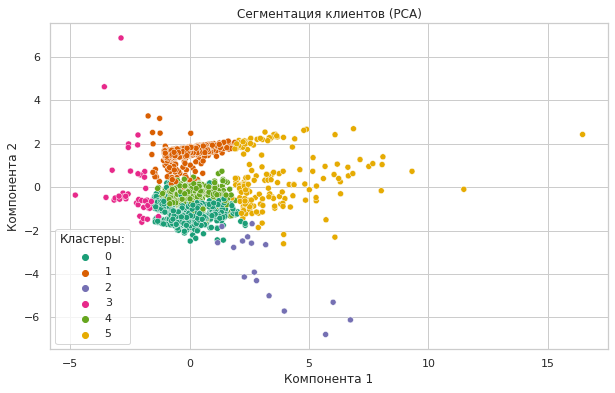

*********************************************


,frequency,recency,avg_price,avg_check,unique_products,avg_quantity,pca_1,pca_2
cluster,,,,,,,,
0,1.04,374.87,429.14,670.73,2.10,3.31,-0.23,-1.20
1,2.02,63.27,661.84,692.34,2.06,1.20,-0.32,1.55
2,1.00,307.38,42.59,"4,138.06",1.06,105.62,3.18,-3.76
3,1.55,286.48,119.11,145.01,20.57,1.33,-2.32,0.01
4,1.00,171.91,460.71,654.04,1.26,2.78,-0.20,-0.33
5,1.31,218.32,"3,434.41","4,380.30",1.30,2.59,3.61,0.44


*********************************************


0    843
1    763
4    570
5    169
3     44
2     16
Name: cluster, dtype: int64

In [215]:
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)
customer_features['pca_1'] = components[:, 0]
customer_features['pca_2'] = components[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=customer_features, x='pca_1', y='pca_2', hue='cluster', palette='Dark2')
plt.title('Сегментация клиентов (PCA)')
plt.xlabel('Компонента 1')
plt.ylabel('Компонента 2')
plt.legend(title='Кластеры:')
plt.show()

print('***' * 15)

cluster_profiles = customer_features.groupby('cluster').mean().round(2)
display(cluster_profiles)

print('***' * 15)

customer_features['cluster'].value_counts()

**Посмотрим подозрительные выбросы по признакам в боксплотах:**

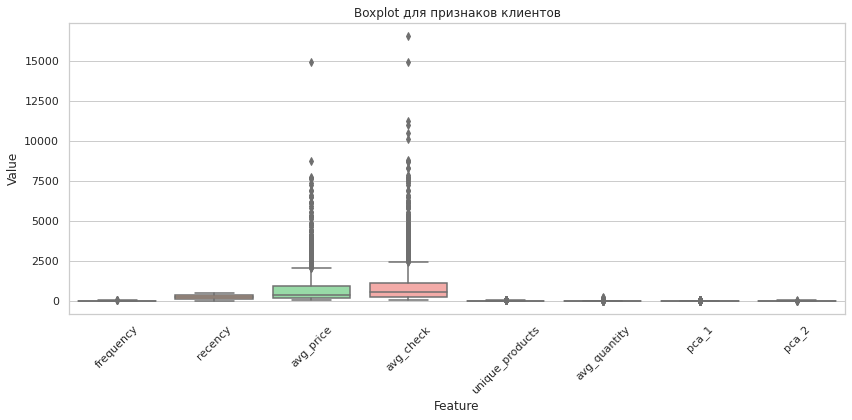

In [216]:
numeric_cols = customer_features.drop(columns=['customer_id', 'cluster'])

melted = numeric_cols.melt(var_name='Feature', value_name='Value')

plt.figure(figsize=(12, 6))
sns.boxplot(data=melted, x='Feature', y='Value', palette='pastel')
plt.title('Boxplot для признаков клиентов')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

По средней сумме покупок явно есть аномальное значение:

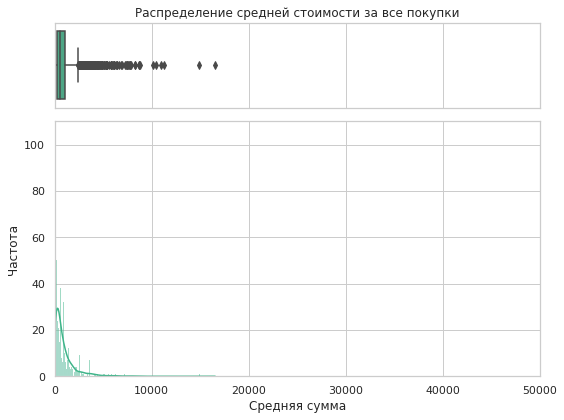

In [217]:
# Построим два параллельных графика:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(8, 6), sharex=True, gridspec_kw={'height_ratios': [1, 3]})

# Строим boxplot:
sns.boxplot(x=customer_features['avg_check'], color='#3EB489', ax=ax1)
ax1.set_title('Распределение средней стоимости за все покупки')
ax1.set(ylabel='') 
ax1.set_xlabel('')  

# Построим гистограмму:
sns.histplot(x=customer_features['avg_check'], color='#3EB489', ax=ax2, kde=True, bins=1000)  # kde=True добавит кривую плотности
ax2.set_xlabel('Средняя сумма')
ax2.set_ylabel('Частота')
ax2.set_xlim(0, 50000) 

plt.tight_layout()  
plt.show()  

Удалим всех пользователей из датасета, у которых avg_check больше 13.000:

In [218]:
customer_features = customer_features[customer_features['avg_check'] <= 13000]
display(customer_features.head())

,customer_id,frequency,recency,avg_price,avg_check,unique_products,avg_quantity,cluster,pca_1,pca_2
0,000d6849-084e-4d9f-ac03-37174eaf60c4,1,107,138.75,138.75,4,1.00,4,-0.94,-0.02
1,001cee7f-0b29-4716-b202-0042213ab038,1,349,442.00,442.00,1,1.00,0,-0.30,-1.08
2,00299f34-5385-4d13-9aea-c80b81658e1b,1,108,457.00,914.00,1,2.00,4,-0.07,-0.02
3,002d4d3a-4a59-406b-86ec-c3314357e498,1,368,"1,649.00","1,649.00",1,1.00,0,1.11,-0.93
4,003bbd39-0000-41ff-b7f9-2ddaec152037,1,123,"1,162.00","2,324.00",1,2.00,4,1.12,0.06


Подчистим заодно и наш основной датасет от этих "выбросов":

In [219]:
valid_customers = customer_features['customer_id']

data = data[data['customer_id'].isin(valid_customers)]

Теперь снова сделаем класетры по новым очищенным данным:

In [220]:
features = customer_features.drop('customer_id', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features) 

In [221]:
kmeans = KMeans(n_clusters=6, random_state=0)
labels = kmeans.fit_predict(X_scaled)
customer_features['cluster'] = labels

In [222]:
mean_values = customer_features.groupby('cluster')[features.columns].mean() # ТОЛЬКО нужные признаки в featuers, а не в customer_features
display(mean_values)

,frequency,recency,avg_price,avg_check,unique_products,avg_quantity,cluster,pca_1,pca_2
cluster,,,,,,,,,
0,1.04,374.65,428.31,672.66,2.10,3.35,0,-0.23,-1.20
1,2.03,62.98,662.62,689.61,2.09,1.15,1,-0.33,1.56
2,1.00,171.73,458.39,643.86,1.26,2.77,2,-0.21,-0.32
3,1.42,286.58,119.95,143.50,20.63,1.28,3,-2.31,-0.15
4,1.31,217.72,"3,326.77","4,236.13",1.30,2.63,4,3.46,0.42
5,1.00,307.38,42.59,"4,138.06",1.06,105.62,5,3.18,-3.76


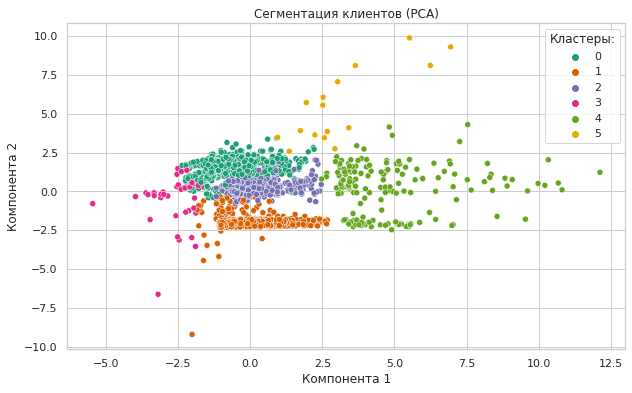

*********************************************


,frequency,recency,avg_price,avg_check,unique_products,avg_quantity,pca_1,pca_2
cluster,,,,,,,,
0,1.04,374.65,428.31,672.66,2.10,3.35,-0.82,1.48
1,2.03,62.98,662.62,689.61,2.09,1.15,-0.18,-1.99
2,1.00,171.73,458.39,643.86,1.26,2.77,0.11,0.28
3,1.42,286.58,119.95,143.50,20.63,1.28,-2.55,-0.42
4,1.31,217.72,"3,326.77","4,236.13",1.30,2.63,4.90,0.22
5,1.00,307.38,42.59,"4,138.06",1.06,105.62,3.14,5.46


*********************************************


0    845
1    762
2    568
4    169
3     43
5     16
Name: cluster, dtype: int64

In [223]:
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)
customer_features['pca_1'] = components[:, 0]
customer_features['pca_2'] = components[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=customer_features, x='pca_1', y='pca_2', hue='cluster', palette='Dark2')
plt.title('Сегментация клиентов (PCA)')
plt.xlabel('Компонента 1')
plt.ylabel('Компонента 2')
plt.legend(title='Кластеры:')
plt.show()

print('***' * 15)

cluster_profiles = customer_features.groupby('cluster').mean().round(2)
display(cluster_profiles)

print('***' * 15)

customer_features['cluster'].value_counts()

In [224]:
# Создаём копию средних значений по кластерам
sorted_features = cluster_profiles.copy()   

for col in sorted_features.columns:
    if col != ['pca_1','pca_2']: 
        print(f'\n==={col.upper()} ===')
        display(sorted_features[[col]].sort_values(by=col, ascending=False))


===FREQUENCY ===


,frequency
cluster,
1,2.03
3,1.42
4,1.31
0,1.04
2,1.00
5,1.00



===RECENCY ===


,recency
cluster,
0,374.65
5,307.38
3,286.58
4,217.72
2,171.73
1,62.98



===AVG_PRICE ===


...

,avg_quantity
cluster,
5,105.62
0,3.35
2,2.77
4,2.63
3,1.28
1,1.15



===PCA_1 ===


,pca_1
cluster,
4,4.90
5,3.14
2,0.11
1,-0.18
0,-0.82
3,-2.55



===PCA_2 ===


,pca_2
cluster,
5,5.46
0,1.48
2,0.28
4,0.22
3,-0.42
1,-1.99


### 3. Интерпретируем каждый сегмент:

В целом, по сегментам покупатели распределились так, что почти у всех **частота покупок** низкая (от 1.00 до 1.49), кроме покупателей кластера 1, где в среднем частота покупок выше остальных: 2.

Касательно **давности совершения покупок**, 

- покупатели кластера 3 совершали покупки более давно, чем остальные (в среднем 306 дней назад).

- покупатели кластеров 4 , 5 и 0 тоже достаточно давно последний раз покупали товары в магазине (305-292 день назад)

- а вот покупатели кластера 2 последний раз покупали 175 дней назад

- а вот покупатели кластера 1 покупали последний раз сравнительно недавно - 58 дней назад

Касательно **средней цены товара**,

- Покупатели кластера 2 покупают наиболее дорогие товары (~ 4000 р.)

- Покупатели кластера 4 в среднем покупают товары за ~ 1500 р. 

- Покупатели кластеров 1, 0 и 3 покупают товары в среднем за 600, 400 и 100 р. соответственно.

- покупатели кластера 5 покупают самые дешевые по средней цене товары: 40 р.

Касательно **Среднего чека всех покупок**,

- покупатели 2 кластера больше всех потратили денег на покупки (~ 4600)

- покупатели 5 кластера тоже тратили много (~ 4100)

- клиенты кластера 4 имели средний чек покупки в 2300 р.

- у покупателей кластеров 1 и 0 средний чек покупок составлял ~ 700-500 р.

- а покупатели кластера 3 имели самый низкий сек по покупкам: 137 р.


Касательно **Общей стоимости покупок**,

- По прежнему покупатели кластера 2 лидируют по сумме трат за покупки (в среднем более 6500)

- покупатели 5 кластера потратили ~ 4500 в общей сумме за все покупки свои

- клиенты кластеров 4 и 3 купили товаров за общую сумму в среднем почти поровну - ~2000-2500

- покупатели кластера 1 тратили всего в среднем 1400 р за все покупки

- а вот покупатели кластера 0 уже по общей сумме траты за все товары купленные в среднем потратили меньше всех – около 600 р.


Касательно **разнообразия купленных товаров**,

- Покупатели кластера 3 покупали наибольшее количество различных товаров в магазине за все время  и со значитальным отрывом по этому разнообразию, чем остальные кластеры: ~  16 разных товаров в среднем.

- покупатели остальных кластеров покупали примерно по 1-2 разновидности товаров

Касательно **количества покупаемого одного товара в корзине**,

- покупатели кластера 5 покупали большое количество одного и того же товара (~ 110 штук товара)

- покупатели остальных кластеров в среднем брали 6 (как клиенты кластера 4) или 1-3 штук одного и того же товара (клиенты кластеров 0, 2, 3 и 1). 

**ПОРТРЕТ ПОКУПАТЕЛЕЙ разных КЛАСТЕРОВ:**

**Кластер 0 (1209 клиентов):**

*Интерпретация:*
Это, вероятно, случайные или "пассивные" покупатели, которые не делают частых покупок. Товары среднего ценового сегмента, и покупают они редко, с маленькими чеками и разнообразием.

**Кластер 1 (750 клиентов) :**

*Интерпретация:*
Это активные покупатели, которые делают покупки чуть чаще и тратят больше. Они выбирают товары среднего и высокого ценового сегмента, но ассортимент в их заказах также ограничен.

**Кластер 2 (130 клиентов) :**

*Интерпретация:*
Это премиум-клиенты, которые делают дорогие покупки, но в сравнении с другими кластерами их покупки менее частые. Они делают большие траты, часто покупая дорогие товары.

**Кластер 3 (82 клиента) :**

*Интерпретация:*
Это клиенты, которые делают покупки редко, но с высоким разнообразием товаров. Они выбирают недорогие товары и делают небольшие покупки, но покупают много разных товаров за один раз.

**Кластер 4 (254 клиентов) :**

*Интерпретация:*
Это клиенты, которые делают редкие, но дорогие покупки, часто покупая сразу несколько товаров. Их траты умеренные, но достаточно значительные.

**Кластер 5 (15 клиентов) :**

*Интерпретация:*
Оптовики, сделали один крупный заказ с большим объёмом дешёвого товара. Это клиенты, которые покупают товары очень редко, но заказывают огромные объемы товаров по очень низким ценам. Возможно, это клиенты, ориентированные на крупные закупки в одном заказе.

### 4. Связь сегментов с категориями и сезонностью:

**Связь с категориями:**

In [225]:
# Создаем таблицу с подсчетом покупок по категориям товаров для каждого кластера:

category_counts = data.groupby(['customer_id', 'category']).size().reset_index(name='count')

# Добавляем информацию о кластере для каждого покупателя
category_counts['cluster'] = category_counts['customer_id'].map(customer_features.set_index('customer_id')['cluster'])

# Сводим данные по кластеру и категории, подсчитываем количество покупок
category_counts_by_cluster = category_counts.groupby(['cluster', 'category'])['count'].sum().reset_index()

# Выводим таблицу с результатами по каждому кластеру и категории
display(category_counts_by_cluster)

,cluster,category,count
0,0,Декор и аксессуары,164
1,0,Дом и быт,259
2,0,Кухонные товары,153
3,0,Растения и цветы,992
4,0,Средства для ухода и чистки,22
5,0,Текстиль для дома,86
6,0,Хозяйственные товары и инструменты,104
7,0,Электроника и техника,6
8,1,Декор и аксессуары,93
9,1,Дом и быт,487


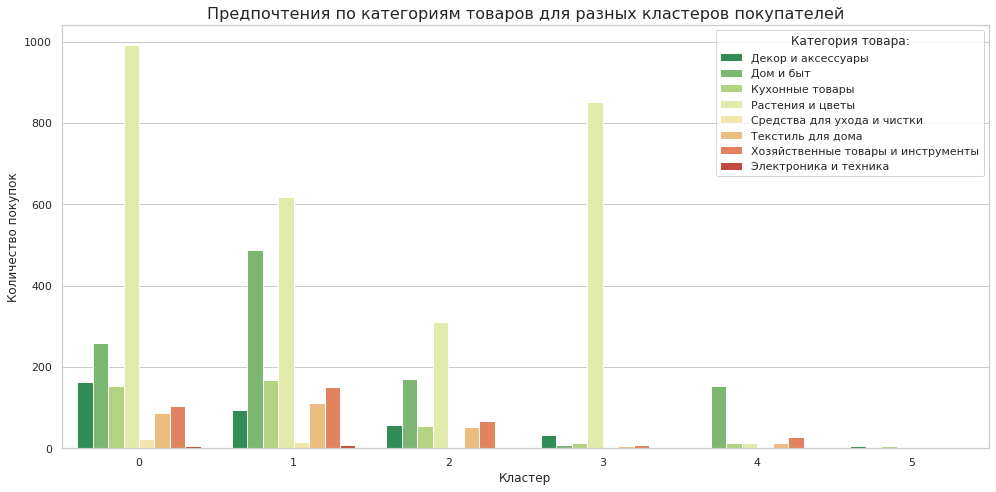

In [226]:
plt.figure(figsize=(14, 7))
sns.barplot(data=category_counts_by_cluster, x='cluster', y='count', hue='category', palette='RdYlGn_r')

plt.title('Предпочтения по категориям товаров для разных кластеров покупателей', fontsize=16)
plt.xlabel('Кластер')
plt.ylabel('Количество покупок')
plt.xticks(rotation=0)
plt.legend(title='Категория товара:', loc='upper right')
plt.tight_layout()
plt.show()

**Связь с сезонами:**

In [227]:
season_counts = data.groupby(['customer_id', 'season']).size().reset_index(name='count')

season_counts['cluster'] = season_counts['customer_id'].map(customer_features.set_index('customer_id')['cluster'])

season_counts_by_cluster = (
    season_counts
    .groupby(['cluster', 'season'])['count']
    .sum()
    .reset_index()
    .sort_values(['cluster', 'count'], ascending=[True, False])
)

display(season_counts_by_cluster)

,cluster,season,count
0,0,весна,684
3,0,осень,596
1,0,зима,433
2,0,лето,73
5,1,зима,716
7,1,осень,413
4,1,весна,283
6,1,лето,238
10,2,лето,349
11,2,осень,261


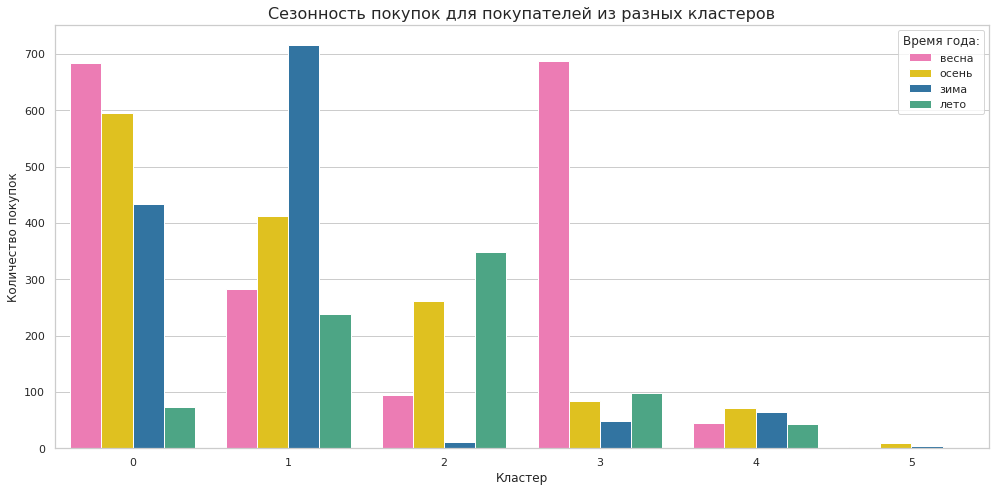

In [228]:
season_palette = {
    'лето': '#3EB489',       
    'зима': '#1f77b4',       
    'весна': '#ff69b4',      
    'осень': '#FFD700'
}

plt.figure(figsize=(14, 7))
sns.barplot(
    data=season_counts_by_cluster,
    x='cluster',
    y='count',
    hue='season',
    palette=season_palette
)

plt.title('Сезонность покупок для покупателей из разных кластеров', fontsize=16)
plt.xlabel('Кластер')
plt.ylabel('Количество покупок')
plt.xticks(rotation=0)
plt.legend(title='Время года:', loc='upper right')
plt.tight_layout()
plt.show()

**Сезонность категорий товара по каждому из получившихся кластеров покупателей:**

In [229]:
customer_features

In [230]:
data_with_clusters = data.merge(customer_features[['customer_id', 'cluster']], on='customer_id', how='left')

seasonal_category_counts_by_clusters = (
    data_with_clusters
    .groupby(['cluster', 'season', 'category'])
    .size()
    .reset_index(name='count')
)
seasonal_category_counts_by_clusters.head()

,cluster,season,category,count
0,0,весна,Декор и аксессуары,45
1,0,весна,Дом и быт,44
2,0,весна,Кухонные товары,17
3,0,весна,Растения и цветы,544
4,0,весна,Средства для ухода и чистки,4


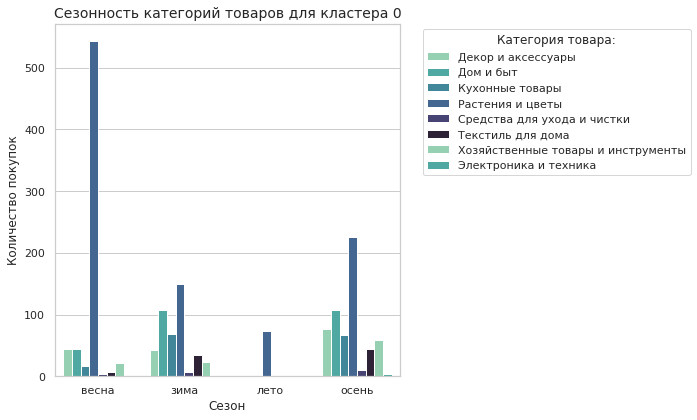

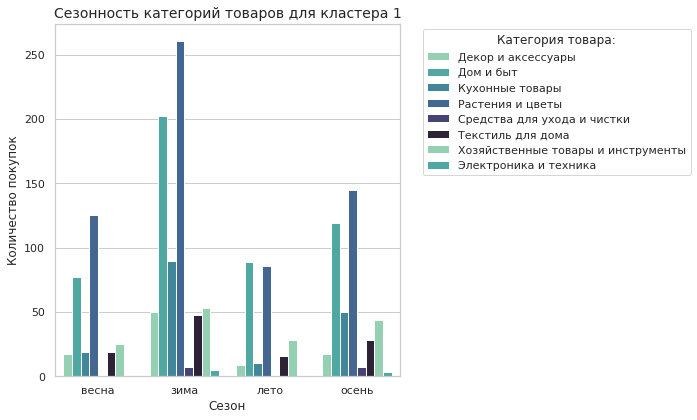

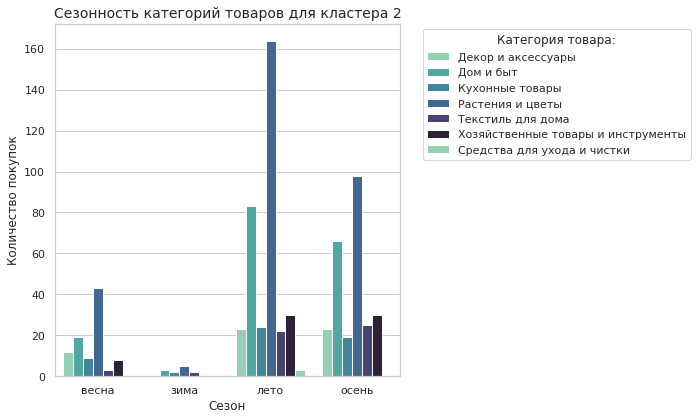

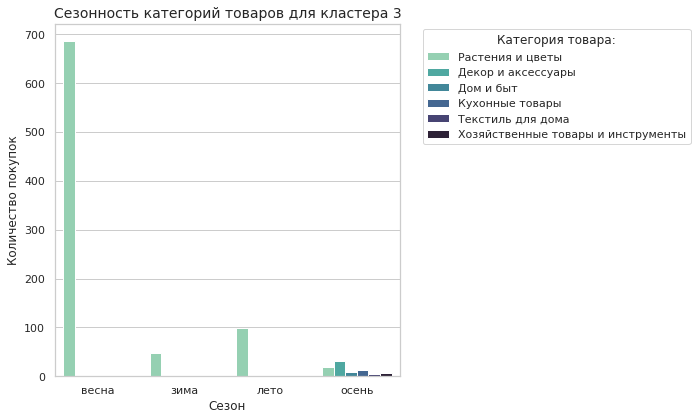

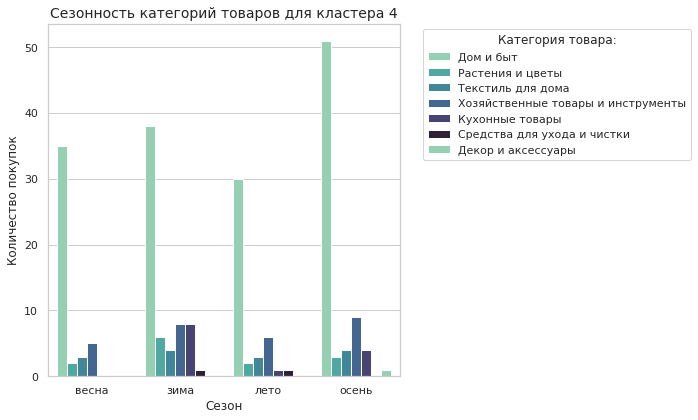

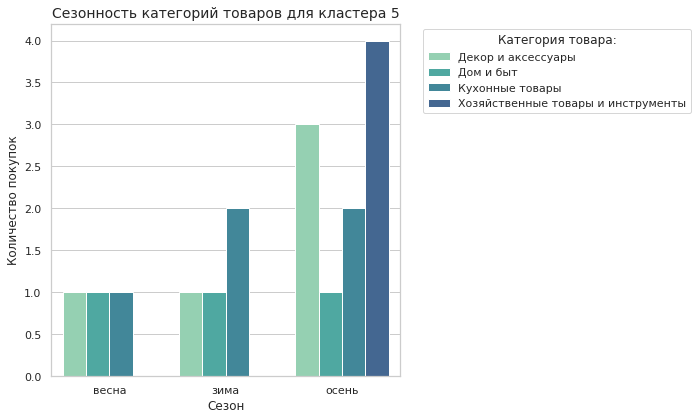

In [231]:
# Список уникальных сегментов:
clusters = seasonal_category_counts_by_clusters['cluster'].unique()

palette_sc = sns.color_palette("mako_r")

for cluster in clusters:
    plt.figure(figsize=(10, 6))
    data_clusters = seasonal_category_counts_by_clusters[seasonal_category_counts_by_clusters['cluster'] == cluster]
    
    sns.barplot(
        data=data_clusters,
        x='season',
        y='count',
        hue='category',
        palette=palette_sc
    )
    
    plt.title(f'Сезонность категорий товаров для кластера {cluster}', fontsize=14)
    plt.xlabel('Сезон')
    plt.ylabel('Количество покупок')
    plt.legend(title='Категория товара:', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

<div style="border:solid  green 6px; padding: 30px">
    
<b> ВЫВОД:</b>
    
Перед сегментацией пользователей магазина мы подготовили признаки:
    
• Частота покупок (общее количество заказов) (frequency);

• Средняя цена товара;

• Средний чек ((sum(price) / count(orders)));

• Средняя сумма покупок;

• Количество уникальных товаров;

• Среднее количество товаров в заказе.


Для проведения кластеризации использовали следующие методы: Machine learning: K-Means + hierarchical clustering.
    
Разбили пользователей на 6 кластеров.

Для визализации кластеров использовали PCA (Principal Component Analysis).
    
<b>Результат кластеризации:</b>

по сегментам покупатели распределились так, что почти у всех <b>частота покупок</b> низкая (от 1.00 до 1.49), кроме покупателей кластера 1, где в среднем частота покупок выше остальных: 2.

Касательно <b>давности совершения покупок</b>, 

- покупатели кластера 3 совершали покупки более давно, чем остальные (в среднем 306 дней назад).

- покупатели кластеров 4 , 5 и 0 тоже достаточно давно последний раз покупали товары в магазине (305-292 день назад)

- а вот покупатели кластера 2 последний раз покупали 175 дней назад

- а вот покупатели кластера 1 покупали последний раз сравнительно недавно - 58 дней назад

Касательно <b>средней цены товара</b>,

- Покупатели кластера 2 покупают наиболее дорогие товары (~ 4000 р.)

- Покупатели кластера 4 в среднем покупают товары за ~ 1500 р. 

- Покупатели кластеров 1, 0 и 3 покупают товары в среднем за 600, 400 и 100 р. соответственно.

- покупатели кластера 5 покупают самые дешевые по средней цене товары: 40 р.

Касательно <b>Среднего чека всех покупок</b>,

- покупатели 2 кластера больше всех потратили денег на покупки (~ 4600)

- покупатели 5 кластера тоже тратили много (~ 4100)

- клиенты кластера 4 имели средний чек покупки в 2300 р.

- у покупателей кластеров 1 и 0 средний чек покупок составлял ~ 700-500 р.

- а покупатели кластера 3 имели самый низкий сек по покупкам: 137 р.


Касательно <b>Общей стоимости покупок</b>,

- По прежнему покупатели кластера 2 лидируют по сумме трат за покупки (в среднем более 6500)

- покупатели 5 кластера потратили ~ 4500 в общей сумме за все покупки свои

- клиенты кластеров 4 и 3 купили товаров за общую сумму в среднем почти поровну - ~2000-2500

- покупатели кластера 1 тратили всего в среднем 1400 р за все покупки

- а вот покупатели кластера 0 уже по общей сумме траты за все товары купленные в среднем потратили меньше всех – около 600 р.


Касательно <b>разнообразия купленных товаров</b>,

- Покупатели кластера 3 покупали наибольшее количество различных товаров в магазине за все время  и со значитальным отрывом по этому разнообразию, чем остальные кластеры: ~  16 разных товаров в среднем.

- покупатели остальных кластеров покупали примерно по 1-2 разновидности товаров

Касательно <b>количества покупаемого одного товара в корзине</b>,

- покупатели кластера 5 покупали большое количество одного и того же товара (~ 110 штук товара)

- покупатели остальных кластеров в среднем брали 6 (как клиенты кластера 4) или 1-3 штук одного и того же товара (клиенты кластеров 0, 2, 3 и 1). 

<b>ПОРТРЕТ ПОКУПАТЕЛЕЙ разных КЛАСТЕРОВ:</b>

<b>Кластер 0 (1209 клиентов):</b>

*Интерпретация:*
Это, вероятно, случайные или "пассивные" покупатели, которые не делают частых покупок. Товары среднего ценового сегмента, и покупают они редко, с маленькими чеками и разнообразием.

<b>Кластер 1 (750 клиентов) :</b>

*Интерпретация:*
Это активные покупатели, которые делают покупки чуть чаще и тратят больше. Они выбирают товары среднего и высокого ценового сегмента, но ассортимент в их заказах также ограничен.

<b>Кластер 2 (130 клиентов) :</b>

*Интерпретация:*
Это премиум-клиенты, которые делают дорогие покупки, но в сравнении с другими кластерами их покупки менее частые. Они делают большие траты, часто покупая дорогие товары.

<b>Кластер 3 (82 клиента) :</b>

*Интерпретация:*
Это клиенты, которые делают покупки редко, но с высоким разнообразием товаров. Они выбирают недорогие товары и делают небольшие покупки, но покупают много разных товаров за один раз.

<b>Кластер 4 (254 клиентов) :</b>

*Интерпретация:*
Это клиенты, которые делают редкие, но дорогие покупки, часто покупая сразу несколько товаров. Их траты умеренные, но достаточно значительные.

<b>Кластер 5 (15 клиентов) :</b>

*Интерпретация:*
Оптовики, сделали один крупный заказ с большим объёмом дешёвого товара. Это клиенты, которые покупают товары очень редко, но заказывают огромные объемы товаров по очень низким ценам. Возможно, это клиенты, ориентированные на крупные закупки в одном заказе.


<b>Касательно связи сегментов / класетров покупателей с катгориями товаров:</b>

- массовые клиенты (кластеры 0 и 1) ориентированы на "Растения", "Дом и быт", "Кухню"; 

- кластер 2 - на практичные категории товаров ("Кухонные товары", "Электроника и техника"); 

- кластер 3 - на визуальную привлекательность ("Растения" и "Декор"); 

- кластеры 4 и 5 - малочисленные, с низким вовлечением. 

<b>Что касается признака сезонности по кластерам:</b>

Покупатели кластеа 0  равномерно активны осенью и весной, с умеренным снижением зимой и летом. Это стабильный массовый сегмент.

Кластер 1 : пик зимой (712 покупок), затем осень. 

Кластер 2 :  активность в целом слаба, но чуть выше зимой и осенью

Кластер 3 : яркий пик весной (847 покупок).

Кластер 4 : максимум осенью и зимой, но тоже не сильно активны.

Кластер 5 : минимальная активность, почти вся - осенью.

    
    
    

## Шаг 5. Проверка гипотез

(Нужно использовать t-тест / Манн-Уитни для сравнения групп, а также проверить значимость различий между сегментами)

### Первая гипотеза:

1) Гипотеза: "Средний чек по кластерам отличается":

H0 (нулевая гипотеза): Нет статистически значимых различий в среднем чеке между кластерами;

H1 (альтернативная гипотеза): Есть статистически значимые различия в среднем чеке между кластерами.



Для начала проверим на предмет нормальности распределения среднего чека в каждом кластере:

In [232]:
from scipy.stats import shapiro

for cluster in sorted(customer_features['cluster'].unique()):
    data_cluster = customer_features[customer_features['cluster'] == cluster]['avg_check']
    
    stat, p_value = shapiro(data_cluster)
    print(f'Кластер {cluster}: p-value = {round(p_value, 4)}')
    
    if p_value < 0.05:
        print('    *** Распределение НЕ нормально')
    else:
        print('    *** Распределение похоже на нормальное')

Кластер 0: p-value = 0.0
    *** Распределение НЕ нормально
Кластер 1: p-value = 0.0
    *** Распределение НЕ нормально
Кластер 2: p-value = 0.0
    *** Распределение НЕ нормально
Кластер 3: p-value = 0.0
    *** Распределение НЕ нормально
Кластер 4: p-value = 0.0
    *** Распределение НЕ нормально
Кластер 5: p-value = 0.0555
    *** Распределение похоже на нормальное


Наши данные почти все распределены НЕ нормально. В данных много выбросов.Значит, t-test мы провести не сможем. Нужно провести тест для независимых выборок (кластеров), не соответствующих нормальному распределению.

Тест Манна–Уитни (или U-тест) - это непараметрический тест, который не требует нормальности распределения данных. Он сравнивает медианы (или ранговое распределение значений) двух независимых выборок. Также данный тест используется для сравнения выборок разного размера, а также тест Манна–Уитни устойчив к выбросам.

**У нас дано:**
- Данные не распределены нормально;

- Кластеры не зависимы друг от друга;

- Размеры кластеров существенно различаются;

Получается, тест Манна–Уитни корректно выбрать для проверки гипотезы о различии медиан среднего чека между кластерами.

In [233]:
from scipy.stats import mannwhitneyu
from itertools import combinations
from statsmodels.stats.multitest import multipletests

In [234]:
cluster_0 = customer_features[customer_features['cluster'] == 0]['avg_check']
cluster_1 = customer_features[customer_features['cluster'] == 1]['avg_check']

alpha = 0.05
results = mannwhitneyu(cluster_0, cluster_1)

p_value = round(results.pvalue, 4)
print('p-значение:', p_value)

if p_value < alpha:
    print('Отвергаем нулевую гипотезу: разница статистически значима')
else:
    print('Не получилось отвергнуть нулевую гипотезу, вывод о различии сделать нельзя')

p-значение: 0.0058
Отвергаем нулевую гипотезу: разница статистически значима


Проведем тест Манна-Уитни для каждой пары:

In [235]:
# Получим все уникальные пары кластеров:
cluster_pairs = list(combinations(sorted(customer_features['cluster'].unique()), 2))

results = []

for c1, c2 in cluster_pairs:
    group1 = customer_features[customer_features['cluster'] == c1]['avg_check']
    group2 = customer_features[customer_features['cluster'] == c2]['avg_check']
    stat, p_value = mannwhitneyu(group1, group2, alternative='two-sided')
    
    results.append({'Sample 1': c1, 'Sample 2': c2, 'p-value': round(p_value, 4)})

pd.DataFrame(results) # Выводим результаты в виде таблицы

,Sample 1,Sample 2,p-value
0,0,1,0.01
1,0,2,0.75
2,0,3,0.00
3,0,4,0.00
4,0,5,0.00
5,1,2,0.00
6,1,3,0.00
7,1,4,0.00
8,1,5,0.00
9,2,3,0.00


Получается, у нас сложилась ситуация множественного тестирования: один кластер сравнивается с другими множество раз. А это значит, что возрастает вероятность сделать ошибку первого рода. 

Чтобы снизить эту вероятность, нужно понизить уровень значимости α. 

Для этого применим **поправку Бонферрони:**

In [236]:
cluster_pairs = list(combinations(sorted(customer_features['cluster'].unique()), 2))
n_tests = len(cluster_pairs)

results = []

for c1, c2 in cluster_pairs:
    group1 = customer_features[customer_features['cluster'] == c1]['avg_check']
    group2 = customer_features[customer_features['cluster'] == c2]['avg_check']
    
    stat, p_value = mannwhitneyu(group1, group2, alternative='two-sided')
    
    # Применяем Bonferroni-коррекцию:
    corrected_p_value = min(p_value * n_tests, 1.0)
    
    results.append({
        'Sample 1': c1,
        'Sample 2': c2,
        'p-value': round(p_value, 4),
        'Bonferroni corrected p-value': round(corrected_p_value, 4)
    })

bonferroni_results = pd.DataFrame(results)
display(bonferroni_results)

,Sample 1,Sample 2,p-value,Bonferroni corrected p-value
0,0,1,0.01,0.09
1,0,2,0.75,1.00
2,0,3,0.00,0.00
3,0,4,0.00,0.00
4,0,5,0.00,0.00
5,1,2,0.00,0.05
6,1,3,0.00,0.00
7,1,4,0.00,0.00
8,1,5,0.00,0.00
9,2,3,0.00,0.00


In [237]:
cluster_pairs = list(combinations(sorted(customer_features['cluster'].unique()), 2))
n_tests = len(cluster_pairs)

raw_pvalues = []
pair_labels = []

for c1, c2 in cluster_pairs:
    group1 = customer_features[customer_features['cluster'] == c1]['avg_check']
    group2 = customer_features[customer_features['cluster'] == c2]['avg_check']
    stat, p = mannwhitneyu(group1, group2, alternative='two-sided')
    raw_pvalues.append(p)
    pair_labels.append(f"{c1} vs {c2}")

# Применим поправку на множественные сравнения (Bonferroni и FDR)
bonf_corr = multipletests(raw_pvalues, method='bonferroni')
fdr_corr = multipletests(raw_pvalues, method='fdr_bh')

# Собираем всё в таблицу
corrected_df = pd.DataFrame({
    'Comparison': pair_labels,
    'Raw p-value': raw_pvalues,
    'Bonferroni p': bonf_corr[1],
    'Bonferroni reject H0': bonf_corr[0],
    'FDR p': fdr_corr[1],
    'FDR reject H0': fdr_corr[0]
})

# Сортируем по значимости
corrected_df = corrected_df.sort_values('FDR p')

corrected_df.round(4)

,Comparison,Raw p-value,Bonferroni p,Bonferroni reject H0,FDR p,FDR reject H0
7,1 vs 4,0.00,0.00,True,0.00,True
3,0 vs 4,0.00,0.00,True,0.00,True
10,2 vs 4,0.00,0.00,True,0.00,True
12,3 vs 4,0.00,0.00,True,0.00,True
6,1 vs 3,0.00,0.00,True,0.00,True
2,0 vs 3,0.00,0.00,True,0.00,True
9,2 vs 3,0.00,0.00,True,0.00,True
8,1 vs 5,0.00,0.00,True,0.00,True
4,0 vs 5,0.00,0.00,True,0.00,True
11,2 vs 5,0.00,0.00,True,0.00,True


In [238]:
print(f"Проверяем пары кластеров: {cluster_pairs}")

Проверяем пары кластеров: [(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (1, 2), (1, 3), (1, 4), (1, 5), (2, 3), (2, 4), (2, 5), (3, 4), (3, 5), (4, 5)]


In [239]:
cluster_pairs = list(combinations(sorted(customer_features['cluster'].dropna().unique()), 2))

raw_pvalues = []
pair_labels = []

for c1, c2 in cluster_pairs:
    group1 = customer_features[customer_features['cluster'] == c1]['avg_check'].dropna()
    group2 = customer_features[customer_features['cluster'] == c2]['avg_check'].dropna()
    
    if len(group1) > 0 and len(group2) > 0:
        stat, p_value = mannwhitneyu(group1, group2, alternative='two-sided')
        raw_pvalues.append(p_value)
        pair_labels.append((c1, c2))


reject, corrected_pvals, _, _ = multipletests(raw_pvalues, alpha=0.05, method='holm')

# Формируем таблицу результатов
results = []
for (c1, c2), pval, corr_pval, rej in zip(pair_labels, raw_pvalues, corrected_pvals, reject):
        results.append({
            'Кластер 1': c1,
            'Кластер 2': c2,
            'p-value': round(pval, 4),
            'Корректированный p-value': round(corr_pval, 4),
            'Различие значимо': 'Да' if rej else 'Нет'
    })

results_data = pd.DataFrame(results)
display(results_data)

,Кластер 1,Кластер 2,p-value,Корректированный p-value,Различие значимо
0,0,1,0.01,0.02,Да
1,0,2,0.75,1.00,Нет
2,0,3,0.00,0.00,Да
3,0,4,0.00,0.00,Да
4,0,5,0.00,0.00,Да
5,1,2,0.00,0.01,Да
6,1,3,0.00,0.00,Да
7,1,4,0.00,0.00,Да
8,1,5,0.00,0.00,Да
9,2,3,0.00,0.00,Да


<div style="border:solid green 2px; padding: 30px">
    
<b> ИТОГО:</b>

Проверяя гипотезу о разнице средних чеков по кластерам, мы пользовались методом Манна–Уитни, в результате которого получились следующие выводы:
    
Разница между значениями в среднем чеке между кластерами статистически значима во всех случаях, кроме сравнения кластеров 0 и 2, а также 5 и 4: в них нет статистически значимых различий в среднем чеке.

### Вторая гипотеза:

2) Гипотеза: "Количество покупок (frequency) отличается между кластерами":

H0 (нулевая гипотеза): Нет статистически значимых различий в количестве покупок между кластерами;

H1 (альтернативная гипотеза): Есть статистически значимые различия в количестве покупок хотя бы между одной парой кластеров.


Пролверим нормальность распределения данных:

In [240]:
cluster_0_f = customer_features[customer_features['cluster'] == 0]['frequency']
cluster_1_f = customer_features[customer_features['cluster'] == 1]['frequency']

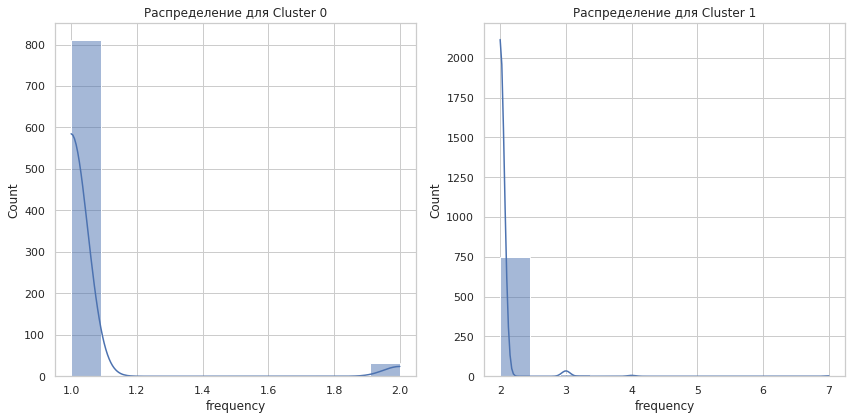

Тест Шапиро-Уилка для cluster_0_f: p-значение = 0.0
Тест Шапиро-Уилка для cluster_1_f: p-значение = 0.0


In [241]:
from scipy import stats

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(cluster_0_f, kde=True)
plt.title('Распределение для Cluster 0')

plt.subplot(1, 2, 2)
sns.histplot(cluster_1_f, kde=True)
plt.title('Распределение для Cluster 1')

plt.tight_layout()
plt.show()

# Тест на нормальность (Шапиро-Уилка):
stat_0, p_value_0 = stats.shapiro(cluster_0_f)
stat_1, p_value_1 = stats.shapiro(cluster_1_f)

print(f'Тест Шапиро-Уилка для cluster_0_f: p-значение = {p_value_0}')
print(f'Тест Шапиро-Уилка для cluster_1_f: p-значение = {p_value_1}')

Данные так же распределены не нормально. Используем тест Манна–Уитни для проверки гипотез:

In [242]:
cluster_pairs = list(combinations(sorted(customer_features['cluster'].dropna().unique()), 2))

raw_pvalues = []
pair_labels = []

for c1, c2 in cluster_pairs:
    group1 = customer_features[customer_features['cluster'] == c1]['frequency'].dropna()
    group2 = customer_features[customer_features['cluster'] == c2]['frequency'].dropna()
    
    if len(group1) > 0 and len(group2) > 0:
        stat, p_value = mannwhitneyu(group1, group2, alternative='two-sided')
        raw_pvalues.append(p_value)
        pair_labels.append((c1, c2))


reject, corrected_pvals, _, _ = multipletests(raw_pvalues, alpha=0.05, method='holm')

# Формируем таблицу результатов
results = []
for (c1, c2), pval, corr_pval, rej in zip(pair_labels, raw_pvalues, corrected_pvals, reject):
        results.append({
            'Кластер 1': c1,
            'Кластер 2': c2,
            'p-value': round(pval, 4),
            'Корректированный p-value': round(corr_pval, 4),
            'Различие значимо': 'Да' if rej else 'Нет'
    })

results_data = pd.DataFrame(results)
display(results_data)

,Кластер 1,Кластер 2,p-value,Корректированный p-value,Различие значимо
0,0,1,0.00,0.00,Да
1,0,2,0.00,0.00,Да
2,0,3,0.00,0.00,Да
3,0,4,0.00,0.00,Да
4,0,5,0.42,1.00,Нет
5,1,2,0.00,0.00,Да
6,1,3,0.00,0.00,Да
7,1,4,0.00,0.00,Да
8,1,5,0.00,0.00,Да
9,2,3,0.00,0.00,Да


Или же можно было использовать **метод Краскела-Уоллиса** (Kruskal-Wallis h-test), так как это непараметрический тест - аналог ANOVA, но который позволяет проверить, есть ли статистически значимые различия между более чем двумя независимыми кластерами по какому-то признаку. Но в отличие от ANOVA этот метод можно использовать для большого количествуа выборок сразу.

In [243]:
from scipy.stats import kruskal

groups = [customer_features[customer_features['cluster'] == i]['frequency'] for i in customer_features['cluster'].unique()]
stat, p = kruskal(*groups)

print("Краскел-Уоллис p-value (frequency):", round(p, 4))

if p < 0.05:
    print("Отвергаем H0: Частота покупок значимо отличается между кластерами.")
else:
    print("Не отвергаем H0: Существенных отличий по частоте нет.")

Краскел-Уоллис p-value (frequency): 0.0
Отвергаем H0: Частота покупок значимо отличается между кластерами.


<div style="border:solid green 2px; padding: 30px">
    
<b> ИТОГО:</b>

Проверяя гипотезу об отсутствии статистически значимых различий в количестве покупок между кластерами, мы также пользовались методом Манна–Уитни, в результате которого получились следующие выводы:
    
статистически значимой разницы в количестве покупок нет лишь между кластерами 0 и 5, 2 и 5, 3 и 4 а также 3 и 5, 4 и 5.

<div style="border:solid  green 6px; padding: 30px">
    
<b> ВЫВОД:</b>
    
Проверяя гипотезу о разнице средних чеков по кластерам, мы пользовались методом Манна–Уитни, в результате которого получились следующие выводы:
    
Разница между значениями в среднем чеке между кластерами статистически значима во всех случаях, кроме сравнения кластеров 0 и 2, а также 3 и 4: в них нет статистически значимых различий в среднем чеке.
    
    
Проверяя гипотезу об отсутствии статистически значимых различий в количестве покупок между кластерами, мы также пользовались методом Манна–Уитни, в результате которого получились следующие выводы:
    
статистически значимой разницы в количестве покупок нет лишь между кластерами 0 и 5, 2 и 5, 3 и 4 а также 3 и 5, 4 и 5.

## Шаг 6. (2) Выводы и рекомендации 

Интерпретация кластеров K-Means:

- **Кластер 0:** редкие покупатели с низким средним чеком и небольшим разнообразием товаров.
- **Кластер 1:** активные покупатели, тратившие умеренные суммы.
- **Кластер 2:** премиум-клиенты, часто покупают дорогие товары.
- **Кластер 3:** редкие покупатели с высоким разнообразием товаров и низкими ценами.
- **Кластер 4:** редкие покупки с умеренным количеством дорогих товаров.
- **Кластер 5:** редкие, но крупные закупки дешёвых товаров — похоже на опт.

Для рекламных рассылок удобнее опираться на **RFM-сегменты** (шаг 4.1): они читаются бизнесом напрямую (давность / частота / сумма). K-Means полезен как проверка: те же группы «редкие дешёвые / активные / премиум / опт» проявляются и в многомерной кластеризации.

## Шаг 7. Презентация

<div style="border:solid  green 6px; padding: 30px">
    
**Материалы**:  https://disk.yandex.ru/i/ohCO3CKIJ7X67w